In [1]:
"""
Date: 08-10-2025
Desc: To get the specificity and sensitivity based on the prediction results of NN and cal-NN models.
      The prediction results are already generated by 
      - fanet_mdp_nn_mcs_adaptation_Sept25.py
      - fanet_mdp_calnn_mcs_adaptation_Sept25.py
      - fanet_mdp_nn_usi_adaptation_Sept25.py
      - fanet_mdp_calnn_usi_adaptation_Sept25.py
      From the files produced by these scripts, we will calculate the specificity and sensitivity.
"""

import numpy as np
import glob, math, os
import pandas as pd # for data manipulation 
from sklearn.metrics import recall_score
import matplotlib.pyplot as plt

def get_dmax_percentage(results_path, include_files=None):
    # Takes a root path where all test case results are stored
    # Each test case result is a CSV file 
    # Get the percentage of D_max achieved for each test case
    # Include_files: List of filenames to include. If None, include all files.
    percent_dmax_list = []
    for file in glob.glob(results_path + "/*"):
        if include_files is not None:
            if os.path.basename(file) not in include_files:
                continue
        df = pd.read_csv(file)
        dmax = df["Dmax"].values[0]
        # If there is an "Abort" status, get the horizontal distance just before the abort
        if "Abort" in df["Status"].values:
            abort_distance = df[df["Status"]=="Abort"]["Horizontal_Distance"].values[0]
            max_hdist = df[df["Horizontal_Distance"]<abort_distance]["Horizontal_Distance"].max()
        else:
            max_hdist = df["Horizontal_Distance"].max()
        if not pd.isna(max_hdist):
            percent_dmax = max_hdist / dmax * 100
        else:
            percent_dmax = 0
        percent_dmax_list.append(percent_dmax)
    return percent_dmax_list

## Load Ground Truth

In [2]:
# Read the ground truth data
dl_df_gt = pd.read_csv("/media/research-student/DataDrive/FANET_Dataset/complete_testing_dmax_dataset/data_processed_complete/Downlink_Reliability.csv")
ul_df_gt = pd.read_csv("/media/research-student/DataDrive/FANET_Dataset/complete_testing_dmax_dataset/data_processed_complete/Uplink_Reliability.csv")
vid_df_gt = pd.read_csv("/media/research-student/DataDrive/FANET_Dataset/complete_testing_dmax_dataset/data_processed_complete/Video_Reliability.csv")
dl_df_gt["Reliability"] = dl_df_gt["Num_Reliable"] / (dl_df_gt["Num_Delay_Excd"] + dl_df_gt["Num_Fail_Other"] + dl_df_gt["Num_Reliable"])
ul_df_gt["Reliability"] = ul_df_gt["Num_Reliable"] / (ul_df_gt["Num_Delay_Excd"] + ul_df_gt["Num_Fail_Other"] + ul_df_gt["Num_Reliable"])
vid_df_gt["Reliability"] = vid_df_gt["Num_Reliable"] / (vid_df_gt["Num_Delay_Excd"] + vid_df_gt["Num_Fail_Other"] + vid_df_gt["Num_Reliable"])

## Mode Set

In [3]:
# To set the stopping condition for the test.
# stop_on_fail = True means the test stops when the first false negative occurs.
stop_on_fail = True

## MCS Adaptation

### Required Reliability Level - 90%

#### For NN

In [ ]:
# For Required Reliability Level of 90%, NN Predictions
# NOTE: Remember to set mode for stopping condition!!!
# NOTE: The CSV results file where predictions are stored must have ascendingly sorted index.
REL_TH = 0.9
MCS_BITRATE_MAP = {0: 6.5, 1: 13, 2: 19.5, 3: 26, 4: 39, 5: 52, 6: 58.5, 7: 65} # in Mbps
PATH = "/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_mcs_adaptation/predictions_5m_nn_90"
predictions_df_list = []
# include_files = [] # To store the files to include for calculating percentage dmax for this model and rel_th
success_results = [] # To store success results for each (height, usi, mcs) combination
percent_dmax_results = [] # To store percentage dmax results for each (height, usi, mcs) combination
for file in glob.glob(PATH + "/*"):
    predictions_df = pd.read_csv(file)
    predictions_df.drop_duplicates(subset=["Horizontal_Distance", "Height", "UAV_Send_Interval", "MCS", "DL_Reliability", "UL_Reliability", "Vid_Reliability"], keep="last", inplace=True)
    fail = 0 # 0 means no failure, 1 means failure
    for index, row in predictions_df.iterrows():
        # Skip row if status is "Abort" or "Prediction" (only include "Continue", "Adapt", and "Chosen")
        if row["Status"] == "Abort" or row["Status"] == "Prediction":
            continue
        h_dist = row["Horizontal_Distance"]
        height = row["Height"]
        mcs = row["MCS"]
        usi = row["UAV_Send_Interval"]
        predicted_state = "Positive" if (row["DL_Reliability"] < REL_TH or row["UL_Reliability"] < REL_TH or row["Vid_Reliability"] < REL_TH) else "Negative"
        dl_reliability = dl_df_gt[(dl_df_gt["Horizontal_Distance"]==h_dist) & (dl_df_gt["Height"]==height) & (dl_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (dl_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        ul_reliability = ul_df_gt[(ul_df_gt["Horizontal_Distance"]==h_dist) & (ul_df_gt["Height"]==height) & (ul_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (ul_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]   
        vid_reliability = vid_df_gt[(vid_df_gt["Horizontal_Distance"]==h_dist) & (vid_df_gt["Height"]==height) & (vid_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (vid_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        actual_state = "Positive" if (dl_reliability < REL_TH or ul_reliability < REL_TH or vid_reliability < REL_TH) else "Negative"
        predictions_df.at[index, "Actual_State"] = actual_state
        predictions_df.at[index, "Predicted_State"] = predicted_state
        if actual_state == "Positive" and predicted_state == "Negative":
            fail = 1
            if stop_on_fail:
                # drop the rest of the rows in predictions_df since we are not considering their results in this mode. Need index to in ascending order
                predictions_df = predictions_df[predictions_df.index <= index]
                fail_distance = row["Horizontal_Distance"]
                break

    dmax = predictions_df["Dmax"].values[0]

    if fail == 1:
        # This is an unsuccessful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], False))
        percent_dmax = fail_distance / dmax * 100
    else:
        # This is a successful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], True))
        # include_files.append(os.path.basename(file)) # This is for using get_dmax_percentage function, but we will calculate percentage dmax here directly
        # Calculate percentage dmax for this file and store it
        # If there is an "Abort" status, get the horizontal distance just before the abort
        if "Abort" in predictions_df["Status"].values:
            abort_distance = predictions_df[predictions_df["Status"]=="Abort"]["Horizontal_Distance"].values[0]
            max_hdist = predictions_df[predictions_df["Horizontal_Distance"]<abort_distance]["Horizontal_Distance"].max()
        else:
            max_hdist = predictions_df["Horizontal_Distance"].max()
        if not pd.isna(max_hdist):
            percent_dmax = max_hdist / dmax * 100
        else:
            percent_dmax = 0
        
    percent_dmax_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], percent_dmax))    
    predictions_df_list.append(predictions_df)

predictions_df = pd.concat(predictions_df_list)

# Drop rows in predictions_df where Actual_State or Predicted_State is NaN
predictions_df.dropna(subset=["Actual_State", "Predicted_State"], inplace=True)

# Calculate specificity and sensitivity
nn_90_mcs_sensitivity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Positive")
nn_90_mcs_specificity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Negative")
# Calculate success rate
nn_90_mcs_success_rate = sum([1 for _, _, _, success in success_results if success]) / len(success_results)
# Calculate the overall percentage dmax
nn_mcs_90_dmax_percentages = [percent_dmax for _, _, _, percent_dmax in percent_dmax_results]
# # Store include_files
# nn_90_mcs_include_files = include_files
# Calculate specificity and sensitivity for each height
nn_90_mcs_sensitivity_by_height = {}
nn_90_mcs_specificity_by_height = {}
nn_90_mcs_success_rate_by_height = {}
nn_90_mcs_percent_dmax_by_height = {}
for height in predictions_df["Height"].unique():
    df_by_height = predictions_df[predictions_df["Height"] == height]
    if len(df_by_height[df_by_height["Actual_State"] == "Positive"]) > 0:
        nn_90_mcs_sensitivity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Positive")
    else:
        nn_90_mcs_sensitivity_by_height[height] = np.nan  # or some other value indicating no positive cases
    if len(df_by_height[df_by_height["Actual_State"] == "Negative"]) > 0:
        nn_90_mcs_specificity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Negative")
    else:
        nn_90_mcs_specificity_by_height[height] = np.nan  # or some other value indicating no negative cases
    nn_90_mcs_success_rate_by_height[height] = sum([1 for h, _, _, success in success_results if h == height and success]) / sum([1 for h, _, _, _ in success_results if h == height])
    nn_90_mcs_percent_dmax_by_height[height] = [percent_dmax for h, _, _, percent_dmax in percent_dmax_results if h == height]

print("NN Model - Required Reliability Level: {}, Sensitivity: {:.4f}, Specificity: {:.4f}, Success Rate: {:.4f}".format(REL_TH, nn_90_mcs_sensitivity, nn_90_mcs_specificity, nn_90_mcs_success_rate))

#### For Cal NN

In [ ]:
# For Required Reliability Level of 90%, Cal NN Predictions
# NOTE: Remember to set mode for stopping condition!!!
# NOTE: The CSV results file where predictions are stored must have ascendingly sorted index.
REL_TH = 0.9
MCS_BITRATE_MAP = {0: 6.5, 1: 13, 2: 19.5, 3: 26, 4: 39, 5: 52, 6: 58.5, 7: 65} # in Mbps
PATH = "/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_mcs_adaptation/predictions_5m_calnn_90"
predictions_df_list = []
success_results = [] # To store success results for each (height, usi, mcs) combination
# include_files = [] # To store the files to include for calculating percentage dmax for this model and rel_th
percent_dmax_results = [] # To store percentage dmax results for each (height, usi, mcs) combination
for file in glob.glob(PATH + "/*"):
    predictions_df = pd.read_csv(file)
    predictions_df.drop_duplicates(subset=["Horizontal_Distance", "Height", "UAV_Send_Interval", "MCS", "DL_Reliability", "UL_Reliability", "Vid_Reliability"], keep="last", inplace=True)
    fail = 0 # 0 means no failure, 1 means failure
    for index, row in predictions_df.iterrows():
        # Skip row if status is "Abort" or "Prediction" (only include "Continue", "Adapt", and "Chosen")
        if row["Status"] == "Abort" or row["Status"] == "Prediction":
            continue
        h_dist = row["Horizontal_Distance"]
        height = row["Height"]
        mcs = row["MCS"]
        usi = row["UAV_Send_Interval"]
        predicted_state = "Positive" if (row["DL_Reliability"] < REL_TH or row["UL_Reliability"] < REL_TH or row["Vid_Reliability"] < REL_TH) else "Negative"
        dl_reliability = dl_df_gt[(dl_df_gt["Horizontal_Distance"]==h_dist) & (dl_df_gt["Height"]==height) & (dl_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (dl_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        ul_reliability = ul_df_gt[(ul_df_gt["Horizontal_Distance"]==h_dist) & (ul_df_gt["Height"]==height) & (ul_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (ul_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]   
        vid_reliability = vid_df_gt[(vid_df_gt["Horizontal_Distance"]==h_dist) & (vid_df_gt["Height"]==height) & (vid_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (vid_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        actual_state = "Positive" if (dl_reliability < REL_TH or ul_reliability < REL_TH or vid_reliability < REL_TH) else "Negative"
        predictions_df.at[index, "Actual_State"] = actual_state
        predictions_df.at[index, "Predicted_State"] = predicted_state
        if actual_state == "Positive" and predicted_state == "Negative":
            fail = 1
            if stop_on_fail:
                # drop the rest of the rows in predictions_df since we are not considering their results in this mode. Need index to in ascending order
                predictions_df = predictions_df[predictions_df.index <= index]
                fail_distance = row["Horizontal_Distance"]
                break

    dmax = predictions_df["Dmax"].values[0]

    if fail == 1:
        # This is an unsuccessful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], False))
        percent_dmax = fail_distance / dmax * 100
    else:
        # This is a successful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], True))
        # include_files.append(os.path.basename(file)) # This is for using get_dmax_percentage function, but we will calculate percentage dmax here directly
        # Calculate percentage dmax for this file and store it
        # If there is an "Abort" status, get the horizontal distance just before the abort
        if "Abort" in predictions_df["Status"].values:
            abort_distance = predictions_df[predictions_df["Status"]=="Abort"]["Horizontal_Distance"].values[0]
            max_hdist = predictions_df[predictions_df["Horizontal_Distance"]<abort_distance]["Horizontal_Distance"].max()
        else:
            max_hdist = predictions_df["Horizontal_Distance"].max()
        if not pd.isna(max_hdist):
            percent_dmax = max_hdist / dmax * 100
        else:
            percent_dmax = 0
            
    percent_dmax_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], percent_dmax))
    predictions_df_list.append(predictions_df)
    
predictions_df = pd.concat(predictions_df_list)

# Drop rows in predictions_df where Actual_State or Predicted_State is NaN
predictions_df.dropna(subset=["Actual_State", "Predicted_State"], inplace=True)

# Calculate specificity and sensitivity
cal_nn_90_mcs_sensitivity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Positive")
cal_nn_90_mcs_specificity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Negative")
#Calculate success rate
cal_nn_90_mcs_success_rate = sum([1 for _, _, _, success in success_results if success]) / len(success_results)
# # Store include_files
# cal_nn_90_mcs_include_files = include_files
# Calculate the overall percentage dmax
cal_nn_mcs_90_dmax_percentages = [percent_dmax for _, _, _, percent_dmax in percent_dmax_results]
# Calculate specificity and sensitivity for each height
cal_nn_90_mcs_sensitivity_by_height = {}
cal_nn_90_mcs_specificity_by_height = {}
cal_nn_90_mcs_success_rate_by_height = {}
cal_nn_90_mcs_percent_dmax_by_height = {}
for height in predictions_df["Height"].unique():
    df_by_height = predictions_df[predictions_df["Height"] == height]
    if len(df_by_height[df_by_height["Actual_State"] == "Positive"]) > 0:
        cal_nn_90_mcs_sensitivity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Positive")
    else:
        cal_nn_90_mcs_sensitivity_by_height[height] = np.nan  # or some other value indicating no positive cases
    if len(df_by_height[df_by_height["Actual_State"] == "Negative"]) > 0:
        cal_nn_90_mcs_specificity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Negative")
    else:
        cal_nn_90_mcs_specificity_by_height[height] = np.nan  # or some other value indicating no negative cases
    cal_nn_90_mcs_success_rate_by_height[height] = sum([1 for h, _, _, success in success_results if h == height and success]) / sum([1 for h, _, _, _ in success_results if h == height])
    cal_nn_90_mcs_percent_dmax_by_height[height] = [percent_dmax for h, _, _, percent_dmax in percent_dmax_results if h == height]

print("Cal NN Model - Required Reliability Level: {}, Sensitivity: {:.4f}, Specificity: {:.4f}, Success Rate: {:.4f}".format(REL_TH, cal_nn_90_mcs_sensitivity, cal_nn_90_mcs_specificity, cal_nn_90_mcs_success_rate))

### Required Reliability Level - 99%

#### For NN

In [ ]:
# For Required Reliability Level of 99%, NN Predictions
# NOTE: Remember to set mode for stopping condition!!!
# NOTE: The CSV results file where predictions are stored must have ascendingly sorted index.
REL_TH = 0.99
MCS_BITRATE_MAP = {0: 6.5, 1: 13, 2: 19.5, 3: 26, 4: 39, 5: 52, 6: 58.5, 7: 65} # in Mbps
PATH = "/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_mcs_adaptation/predictions_5m_nn_99"
predictions_df_list = []
success_results = [] # To store success results for each (height, usi, mcs) combination
# include_files = [] # To store the files to include for calculating percentage dmax for this model and rel_th
percent_dmax_results = [] # To store percentage dmax results for each (height, usi, mcs) combination
for file in glob.glob(PATH + "/*"):
    predictions_df = pd.read_csv(file)
    predictions_df.drop_duplicates(subset=["Horizontal_Distance", "Height", "UAV_Send_Interval", "MCS", "DL_Reliability", "UL_Reliability", "Vid_Reliability"], keep="last", inplace=True)
    fail = 0 # 0 means no failure, 1 means failure
    for index, row in predictions_df.iterrows():
        # Skip row if status is "Abort" or "Prediction" (only include "Continue", "Adapt", and "Chosen")
        if row["Status"] == "Abort" or row["Status"] == "Prediction":
            continue
        h_dist = row["Horizontal_Distance"]
        height = row["Height"]
        mcs = row["MCS"]
        usi = row["UAV_Send_Interval"]
        predicted_state = "Positive" if (row["DL_Reliability"] < REL_TH or row["UL_Reliability"] < REL_TH or row["Vid_Reliability"] < REL_TH) else "Negative"
        dl_reliability = dl_df_gt[(dl_df_gt["Horizontal_Distance"]==h_dist) & (dl_df_gt["Height"]==height) & (dl_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (dl_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        ul_reliability = ul_df_gt[(ul_df_gt["Horizontal_Distance"]==h_dist) & (ul_df_gt["Height"]==height) & (ul_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (ul_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]   
        vid_reliability = vid_df_gt[(vid_df_gt["Horizontal_Distance"]==h_dist) & (vid_df_gt["Height"]==height) & (vid_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (vid_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        actual_state = "Positive" if (dl_reliability < REL_TH or ul_reliability < REL_TH or vid_reliability < REL_TH) else "Negative"
        predictions_df.at[index, "Actual_State"] = actual_state
        predictions_df.at[index, "Predicted_State"] = predicted_state
        if actual_state == "Positive" and predicted_state == "Negative":
            fail = 1
            if stop_on_fail:
                # drop the rest of the rows in predictions_df since we are not considering their results in this mode. Need index to in ascending order
                predictions_df = predictions_df[predictions_df.index <= index]
                fail_distance = row["Horizontal_Distance"]
                break

    dmax = predictions_df["Dmax"].values[0]

    if fail == 1:
        # This is an unsuccessful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], False))
        percent_dmax = fail_distance / dmax * 100
    else:
        # This is a successful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], True))
        # include_files.append(os.path.basename(file)) # This is for using get_dmax_percentage function, but we will calculate percentage dmax here directly
        # Calculate percentage dmax for this file and store it
        # If there is an "Abort" status, get the horizontal distance just before the abort
        if "Abort" in predictions_df["Status"].values:
            abort_distance = predictions_df[predictions_df["Status"]=="Abort"]["Horizontal_Distance"].values[0]
            max_hdist = predictions_df[predictions_df["Horizontal_Distance"]<abort_distance]["Horizontal_Distance"].max()
        else:
            max_hdist = predictions_df["Horizontal_Distance"].max()
        if not pd.isna(max_hdist):
            percent_dmax = max_hdist / dmax * 100
        else:
            percent_dmax = 0
            
    percent_dmax_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], percent_dmax))
    predictions_df_list.append(predictions_df)
    
predictions_df = pd.concat(predictions_df_list)

# Drop rows in predictions_df where Actual_State or Predicted_State is NaN
predictions_df.dropna(subset=["Actual_State", "Predicted_State"], inplace=True)

# Calculate specificity and sensitivity
nn_99_mcs_sensitivity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Positive")
nn_99_mcs_specificity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Negative")
#Calculate success rate
nn_99_mcs_success_rate = sum([1 for _, _, _, success in success_results if success]) / len(success_results)
# # Store include_files
# nn_99_mcs_include_files = include_files
# Calculate the overall percentage dmax
nn_mcs_99_dmax_percentages = [percent_dmax for _, _, _, percent_dmax in percent_dmax_results]
# Calculate specificity and sensitivity for each height
nn_99_mcs_sensitivity_by_height = {}
nn_99_mcs_specificity_by_height = {}
nn_99_mcs_success_rate_by_height = {}
nn_99_mcs_percent_dmax_by_height = {}
for height in predictions_df["Height"].unique():
    df_by_height = predictions_df[predictions_df["Height"] == height]
    if len(df_by_height[df_by_height["Actual_State"] == "Positive"]) > 0:
        nn_99_mcs_sensitivity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Positive")
    else:
        nn_99_mcs_sensitivity_by_height[height] = np.nan  # or some other value indicating no positive cases
    if len(df_by_height[df_by_height["Actual_State"] == "Negative"]) > 0:
        nn_99_mcs_specificity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Negative")
    else:
        nn_99_mcs_specificity_by_height[height] = np.nan  # or some other value indicating no negative cases
    nn_99_mcs_success_rate_by_height[height] = sum([1 for h, _, _, success in success_results if h == height and success]) / sum([1 for h, _, _, _ in success_results if h == height])
    nn_99_mcs_percent_dmax_by_height[height] = [percent_dmax for h, _, _, percent_dmax in percent_dmax_results if h == height]

print("NN Model - Required Reliability Level: {}, Sensitivity: {:.4f}, Specificity: {:.4f}, Success Rate: {:.4f}".format(REL_TH, nn_99_mcs_sensitivity, nn_99_mcs_specificity, nn_99_mcs_success_rate))

#### For Cal NN

In [18]:
# For Required Reliability Level of 90%, Cal NN Predictions
# NOTE: Remember to set mode for stopping condition!!!
# NOTE: The CSV results file where predictions are stored must have ascendingly sorted index.
REL_TH = 0.99
MCS_BITRATE_MAP = {0: 6.5, 1: 13, 2: 19.5, 3: 26, 4: 39, 5: 52, 6: 58.5, 7: 65} # in Mbps
PATH = "/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_mcs_adaptation/predictions_5m_calnn_99"
predictions_df_list = []
success_results = [] # To store success results for each (height, usi, mcs) combination
# include_files = [] # To store the files to include for calculating percentage dmax for this model and rel_th
percent_dmax_results = [] # To store percentage dmax results for each (height, usi, mcs) combination
for file in glob.glob(PATH + "/*"):
    predictions_df = pd.read_csv(file)
    predictions_df.drop_duplicates(subset=["Horizontal_Distance", "Height", "UAV_Send_Interval", "MCS", "DL_Reliability", "UL_Reliability", "Vid_Reliability"], keep="last", inplace=True)
    fail = 0 # 0 means no failure, 1 means failure
    for index, row in predictions_df.iterrows():
        # Skip row if status is "Abort" or "Prediction" (only include "Continue", "Adapt", and "Chosen")
        if row["Status"] == "Abort" or row["Status"] == "Prediction":
            continue
        h_dist = row["Horizontal_Distance"]
        height = row["Height"]
        mcs = row["MCS"]
        usi = row["UAV_Send_Interval"]
        predicted_state = "Positive" if (row["DL_Reliability"] < REL_TH or row["UL_Reliability"] < REL_TH or row["Vid_Reliability"] < REL_TH) else "Negative"
        dl_reliability = dl_df_gt[(dl_df_gt["Horizontal_Distance"]==h_dist) & (dl_df_gt["Height"]==height) & (dl_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (dl_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        ul_reliability = ul_df_gt[(ul_df_gt["Horizontal_Distance"]==h_dist) & (ul_df_gt["Height"]==height) & (ul_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (ul_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]   
        vid_reliability = vid_df_gt[(vid_df_gt["Horizontal_Distance"]==h_dist) & (vid_df_gt["Height"]==height) & (vid_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (vid_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        actual_state = "Positive" if (dl_reliability < REL_TH or ul_reliability < REL_TH or vid_reliability < REL_TH) else "Negative"
        predictions_df.at[index, "Actual_State"] = actual_state
        predictions_df.at[index, "Predicted_State"] = predicted_state
        if actual_state == "Positive" and predicted_state == "Negative":
            fail = 1
            if stop_on_fail:
                # drop the rest of the rows in predictions_df since we are not considering their results in this mode. Need index to in ascending order
                predictions_df = predictions_df[predictions_df.index <= index]
                fail_distance = row["Horizontal_Distance"]
                break

    dmax = predictions_df["Dmax"].values[0]

    if fail == 1:
        # This is an unsuccessful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], False))
        percent_dmax = fail_distance / dmax * 100
    else:
        # This is a successful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], True))
        # include_files.append(os.path.basename(file)) # This is for using get_dmax_percentage function, but we will calculate percentage dmax here directly
        # Calculate percentage dmax for this file and store it
        # If there is an "Abort" status, get the horizontal distance just before the abort
        if "Abort" in predictions_df["Status"].values:
            abort_distance = predictions_df[predictions_df["Status"]=="Abort"]["Horizontal_Distance"].values[0]
            max_hdist = predictions_df[predictions_df["Horizontal_Distance"]<abort_distance]["Horizontal_Distance"].max()
        else:
            max_hdist = predictions_df["Horizontal_Distance"].max()
        if not pd.isna(max_hdist):
            percent_dmax = max_hdist / dmax * 100
        else:
            percent_dmax = 0
            
    percent_dmax_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], percent_dmax))
    predictions_df_list.append(predictions_df)
    
predictions_df = pd.concat(predictions_df_list)

# Drop rows in predictions_df where Actual_State or Predicted_State is NaN
predictions_df.dropna(subset=["Actual_State", "Predicted_State"], inplace=True)

# Calculate specificity and sensitivity
cal_nn_99_mcs_sensitivity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Positive")
cal_nn_99_mcs_specificity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Negative")
#Calculate success rate
cal_nn_99_mcs_success_rate = sum([1 for _, _, _, success in success_results if success]) / len(success_results)
# # Store include_files
# cal_nn_99_mcs_include_files = include_files
# Calculate the overall percentage dmax
cal_nn_99_mcs_dmax_percentages = [percent_dmax for _, _, _, percent_dmax in percent_dmax_results]
# Calculate specificity and sensitivity for each height
cal_nn_99_mcs_sensitivity_by_height = {}
cal_nn_99_mcs_specificity_by_height = {}
cal_nn_99_mcs_success_rate_by_height = {}
cal_nn_99_mcs_percent_dmax_by_height = {}
for height in predictions_df["Height"].unique():
    df_by_height = predictions_df[predictions_df["Height"] == height]
    if len(df_by_height[df_by_height["Actual_State"] == "Positive"]) > 0:
        cal_nn_99_mcs_sensitivity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Positive")
    else:
        cal_nn_99_mcs_sensitivity_by_height[height] = np.nan  # or some other value indicating no positive cases
    if len(df_by_height[df_by_height["Actual_State"] == "Negative"]) > 0:
        cal_nn_99_mcs_specificity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Negative")
    else:
        cal_nn_99_mcs_specificity_by_height[height] = np.nan  # or some other value indicating no negative cases
    cal_nn_99_mcs_success_rate_by_height[height] = sum([1 for h, _, _, success in success_results if h == height and success]) / sum([1 for h, _, _, _ in success_results if h == height])
    cal_nn_99_mcs_percent_dmax_by_height[height] = [percent_dmax for h, _, _, percent_dmax in percent_dmax_results if h == height]

print("Cal NN Model - Required Reliability Level: {}, Sensitivity: {:.4f}, Specificity: {:.4f}, Success Rate: {:.4f}".format(REL_TH, cal_nn_99_mcs_sensitivity, cal_nn_99_mcs_specificity, cal_nn_99_mcs_success_rate))

Cal NN Model - Required Reliability Level: 0.99, Sensitivity: 1.0000, Specificity: 0.9623, Success Rate: 1.0000


### Required Reliability Level - 99.9%

#### For NN

In [ ]:
# For Required Reliability Level of 90%, NN Predictions
# NOTE: Remember to set mode for stopping condition!!!
# NOTE: The CSV results file where predictions are stored must have ascendingly sorted index.
REL_TH = 0.999
MCS_BITRATE_MAP = {0: 6.5, 1: 13, 2: 19.5, 3: 26, 4: 39, 5: 52, 6: 58.5, 7: 65} # in Mbps
PATH = "/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_mcs_adaptation/predictions_5m_nn_999"
predictions_df_list = []
success_results = [] # To store success results for each (height, usi, mcs) combination
# include_files = [] # To store the files to include for calculating percentage dmax for this model and rel_th
percent_dmax_results = [] # To store percentage dmax results for each (height, usi, mcs) combination
for file in glob.glob(PATH + "/*"):
    predictions_df = pd.read_csv(file)
    predictions_df.drop_duplicates(subset=["Horizontal_Distance", "Height", "UAV_Send_Interval", "MCS", "DL_Reliability", "UL_Reliability", "Vid_Reliability"], keep="last", inplace=True)
    fail = 0 # 0 means no failure, 1 means failure
    for index, row in predictions_df.iterrows():
        # Skip row if status is "Abort" or "Prediction" (only include "Continue", "Adapt", and "Chosen")
        if row["Status"] == "Abort" or row["Status"] == "Prediction":
            continue
        h_dist = row["Horizontal_Distance"]
        height = row["Height"]
        mcs = row["MCS"]
        usi = row["UAV_Send_Interval"]
        predicted_state = "Positive" if (row["DL_Reliability"] < REL_TH or row["UL_Reliability"] < REL_TH or row["Vid_Reliability"] < REL_TH) else "Negative"
        dl_reliability = dl_df_gt[(dl_df_gt["Horizontal_Distance"]==h_dist) & (dl_df_gt["Height"]==height) & (dl_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (dl_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        ul_reliability = ul_df_gt[(ul_df_gt["Horizontal_Distance"]==h_dist) & (ul_df_gt["Height"]==height) & (ul_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (ul_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]   
        vid_reliability = vid_df_gt[(vid_df_gt["Horizontal_Distance"]==h_dist) & (vid_df_gt["Height"]==height) & (vid_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (vid_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        actual_state = "Positive" if (dl_reliability < REL_TH or ul_reliability < REL_TH or vid_reliability < REL_TH) else "Negative"
        predictions_df.at[index, "Actual_State"] = actual_state
        predictions_df.at[index, "Predicted_State"] = predicted_state
        if actual_state == "Positive" and predicted_state == "Negative":
            fail = 1
            if stop_on_fail:
                # drop the rest of the rows in predictions_df since we are not considering their results in this mode. Need index to in ascending order
                predictions_df = predictions_df[predictions_df.index <= index]
                fail_distance = row["Horizontal_Distance"]
                break

    dmax = predictions_df["Dmax"].values[0]

    if fail == 1:
        # This is an unsuccessful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], False))
        percent_dmax = fail_distance / dmax * 100
    else:
        # This is a successful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], True))
        # include_files.append(os.path.basename(file)) # This is for using get_dmax_percentage function, but we will calculate percentage dmax here directly
        # Calculate percentage dmax for this file and store it
        # If there is an "Abort" status, get the horizontal distance just before the abort
        if "Abort" in predictions_df["Status"].values:
            abort_distance = predictions_df[predictions_df["Status"]=="Abort"]["Horizontal_Distance"].values[0]
            max_hdist = predictions_df[predictions_df["Horizontal_Distance"]<abort_distance]["Horizontal_Distance"].max()
        else:
            max_hdist = predictions_df["Horizontal_Distance"].max()
        if not pd.isna(max_hdist):
            percent_dmax = max_hdist / dmax * 100
        else:
            percent_dmax = 0
            
    percent_dmax_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], percent_dmax))
    predictions_df_list.append(predictions_df)

predictions_df = pd.concat(predictions_df_list)

# Drop rows in predictions_df where Actual_State or Predicted_State is NaN
predictions_df.dropna(subset=["Actual_State", "Predicted_State"], inplace=True)

# Calculate specificity and sensitivity
nn_999_mcs_sensitivity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Positive")
nn_999_mcs_specificity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Negative")
#Calculate success rate
nn_999_mcs_success_rate = sum([1 for _, _, _, success in success_results if success]) / len(success_results)
# # Store include_files
# nn_999_mcs_include_files = include_files
# Calculate the overall percentage dmax
nn_999_mcs_dmax_percentages = [percent_dmax for _, _, _, percent_dmax in percent_dmax_results]
# Calculate specificity and sensitivity for each height
nn_999_mcs_sensitivity_by_height = {}
nn_999_mcs_specificity_by_height = {}
nn_999_mcs_success_rate_by_height = {}
nn_999_mcs_percent_dmax_by_height = {}
for height in predictions_df["Height"].unique():
    df_by_height = predictions_df[predictions_df["Height"] == height]
    if len(df_by_height[df_by_height["Actual_State"] == "Positive"]) > 0:
        nn_999_mcs_sensitivity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Positive")
    else:
        nn_999_mcs_sensitivity_by_height[height] = np.nan  # or some other value indicating no positive cases
    if len(df_by_height[df_by_height["Actual_State"] == "Negative"]) > 0:
        nn_999_mcs_specificity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Negative")
    else:
        nn_999_mcs_specificity_by_height[height] = np.nan  # or some other value indicating no negative cases
    nn_999_mcs_success_rate_by_height[height] = sum([1 for h, _, _, success in success_results if h == height and success]) / sum([1 for h, _, _, _ in success_results if h == height])
    nn_999_mcs_percent_dmax_by_height[height] = [percent_dmax for h, _, _, percent_dmax in percent_dmax_results if h == height]
print("NN Model - Required Reliability Level: {}, Sensitivity: {:.4f}, Specificity: {:.4f}, Success Rate: {:.4f}".format(REL_TH, nn_999_mcs_sensitivity, nn_999_mcs_specificity, nn_999_mcs_success_rate))

#### For Cal NN

In [19]:
# For Required Reliability Level of 90%, Cal NN Predictions
# NOTE: Remember to set mode for stopping condition!!!
# NOTE: The CSV results file where predictions are stored must have ascendingly sorted index.
REL_TH = 0.999
MCS_BITRATE_MAP = {0: 6.5, 1: 13, 2: 19.5, 3: 26, 4: 39, 5: 52, 6: 58.5, 7: 65} # in Mbps
PATH = "/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_mcs_adaptation/predictions_5m_calnn_999"
predictions_df_list = []
success_results = [] # To store success results for each (height, usi, mcs) combination
# include_files = [] # To store the files to include for calculating percentage dmax for this model and rel_th
percent_dmax_results = [] # To store percentage dmax results for each (height, usi, mcs) combination
for file in glob.glob(PATH + "/*"):
    predictions_df = pd.read_csv(file)
    predictions_df.drop_duplicates(subset=["Horizontal_Distance", "Height", "UAV_Send_Interval", "MCS", "DL_Reliability", "UL_Reliability", "Vid_Reliability"], keep="last", inplace=True)
    fail = 0 # 0 means no failure, 1 means failure
    for index, row in predictions_df.iterrows():
        # Skip row if status is "Abort" or "Prediction" (only include "Continue", "Adapt", and "Chosen")
        if row["Status"] == "Abort" or row["Status"] == "Prediction":
            continue
        h_dist = row["Horizontal_Distance"]
        height = row["Height"]
        mcs = row["MCS"]
        usi = row["UAV_Send_Interval"]
        predicted_state = "Positive" if (row["DL_Reliability"] < REL_TH or row["UL_Reliability"] < REL_TH or row["Vid_Reliability"] < REL_TH) else "Negative"
        dl_reliability = dl_df_gt[(dl_df_gt["Horizontal_Distance"]==h_dist) & (dl_df_gt["Height"]==height) & (dl_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (dl_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        ul_reliability = ul_df_gt[(ul_df_gt["Horizontal_Distance"]==h_dist) & (ul_df_gt["Height"]==height) & (ul_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (ul_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]   
        vid_reliability = vid_df_gt[(vid_df_gt["Horizontal_Distance"]==h_dist) & (vid_df_gt["Height"]==height) & (vid_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (vid_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        actual_state = "Positive" if (dl_reliability < REL_TH or ul_reliability < REL_TH or vid_reliability < REL_TH) else "Negative"
        predictions_df.at[index, "Actual_State"] = actual_state
        predictions_df.at[index, "Predicted_State"] = predicted_state
        if actual_state == "Positive" and predicted_state == "Negative":
            fail = 1
            if stop_on_fail:
                # drop the rest of the rows in predictions_df since we are not considering their results in this mode. Need index to in ascending order
                predictions_df = predictions_df[predictions_df.index <= index]
                fail_distance = row["Horizontal_Distance"]
                break

    dmax = predictions_df["Dmax"].values[0]

    if fail == 1:
        # This is an unsuccessful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], False))
        percent_dmax = fail_distance / dmax * 100
    else:
        # This is a successful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], True))
        # include_files.append(os.path.basename(file)) # This is for using get_dmax_percentage function, but we will calculate percentage dmax here directly
        # Calculate percentage dmax for this file and store it
        # If there is an "Abort" status, get the horizontal distance just before the abort
        if "Abort" in predictions_df["Status"].values:
            abort_distance = predictions_df[predictions_df["Status"]=="Abort"]["Horizontal_Distance"].values[0]
            max_hdist = predictions_df[predictions_df["Horizontal_Distance"]<abort_distance]["Horizontal_Distance"].max()
        else:
            max_hdist = predictions_df["Horizontal_Distance"].max()
        if not pd.isna(max_hdist):
            percent_dmax = max_hdist / dmax * 100
        else:
            percent_dmax = 0
            
    percent_dmax_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], percent_dmax))
    predictions_df_list.append(predictions_df)
    
predictions_df = pd.concat(predictions_df_list)

# Drop rows in predictions_df where Actual_State or Predicted_State is NaN
predictions_df.dropna(subset=["Actual_State", "Predicted_State"], inplace=True)

# Calculate specificity and sensitivity
cal_nn_999_mcs_sensitivity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Positive")
cal_nn_999_mcs_specificity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Negative")
#Calculate success rate
cal_nn_999_mcs_success_rate = sum([1 for _, _, _, success in success_results if success]) / len(success_results)
# # Store include_files
# cal_nn_999_mcs_include_files = include_files
# Calculate the overall percentage dmax
cal_nn_999_mcs_dmax_percentages = [percent_dmax for _, _, _, percent_dmax in percent_dmax_results]
# Calculate specificity and sensitivity for each height
cal_nn_999_mcs_sensitivity_by_height = {}
cal_nn_999_mcs_specificity_by_height = {}
cal_nn_999_mcs_success_rate_by_height = {}
cal_nn_999_mcs_percent_dmax_by_height = {}
for height in predictions_df["Height"].unique():
    df_by_height = predictions_df[predictions_df["Height"] == height]
    if len(df_by_height[df_by_height["Actual_State"] == "Positive"]) > 0:
        cal_nn_999_mcs_sensitivity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Positive")
    else:
        cal_nn_999_mcs_sensitivity_by_height[height] = np.nan  # or some other value indicating no positive cases
    if len(df_by_height[df_by_height["Actual_State"] == "Negative"]) > 0:
        cal_nn_999_mcs_specificity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Negative")
    else:
        cal_nn_999_mcs_specificity_by_height[height] = np.nan  # or some other value indicating no negative cases
    cal_nn_999_mcs_success_rate_by_height[height] = sum([1 for h, _, _, success in success_results if h == height and success]) / sum([1 for h, _, _, _ in success_results if h == height])
    cal_nn_999_mcs_percent_dmax_by_height[height] = [percent_dmax for h, _, _, percent_dmax in percent_dmax_results if h == height]

print("Cal NN Model - Required Reliability Level: {}, Sensitivity: {:.4f}, Specificity: {:.4f}, Success Rate: {:.4f}".format(REL_TH, cal_nn_999_mcs_sensitivity, cal_nn_999_mcs_specificity, cal_nn_999_mcs_success_rate))

Cal NN Model - Required Reliability Level: 0.999, Sensitivity: 1.0000, Specificity: 0.9599, Success Rate: 1.0000


### Percentage D_max

In [ ]:
# Get the percentage of D_max achieved for each test case

# nn_mcs_90_dmax_percentages = get_dmax_percentage("/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_mcs_adaptation/predictions_5m_nn_90", include_files=nn_90_mcs_include_files)
# nn_mcs_99_dmax_percentages = get_dmax_percentage("/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_mcs_adaptation/predictions_5m_nn_99", include_files=nn_99_mcs_include_files)
# nn_mcs_999_dmax_percentages = get_dmax_percentage("/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_mcs_adaptation/predictions_5m_nn_999", include_files=nn_999_mcs_include_files)

# cal_nn_mcs_90_dmax_percentages = get_dmax_percentage("/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_mcs_adaptation/predictions_5m_calnn_90", include_files=cal_nn_90_mcs_include_files)
# cal_nn_mcs_99_dmax_percentages = get_dmax_percentage("/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_mcs_adaptation/predictions_5m_calnn_99", include_files=cal_nn_99_mcs_include_files)
# cal_nn_mcs_999_dmax_percentages = get_dmax_percentage("/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_mcs_adaptation/predictions_5m_calnn_999", include_files=cal_nn_999_mcs_include_files)

## For USI Adaptation

### Required Reliability Level - 90%

#### For NN

In [ ]:
# For Required Reliability Level of 99.9%, NN Predictions
# NOTE: Remember to set mode for stopping condition!!!
# NOTE: The CSV results file where predictions are stored must have ascendingly sorted index.
REL_TH = 0.90
MCS_BITRATE_MAP = {0: 6.5, 1: 13, 2: 19.5, 3: 26, 4: 39, 5: 52, 6: 58.5, 7: 65} # in Mbps
PATH = "/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_usi_adaptation/predictions_5m_nn_90"
predictions_df_list = []
success_results = [] # To store success results for each (height, usi, mcs) combination
# include_files = [] # To store the files to include for calculating percentage dmax for this model and rel_th
percent_dmax_results = [] # To store percentage dmax results for each (height, usi, mcs) combination
for file in glob.glob(PATH + "/*"):
    predictions_df = pd.read_csv(file)
    predictions_df.drop_duplicates(subset=["Horizontal_Distance", "Height", "UAV_Send_Interval", "MCS", "DL_Reliability", "UL_Reliability", "Vid_Reliability"], keep="last", inplace=True)
    fail = 0 # 0 means no failure, 1 means failure
    for index, row in predictions_df.iterrows():
        # Skip row if status is "Abort" or "Prediction" (only include "Continue", "Adapt", and "Chosen")
        if row["Status"] == "Abort" or row["Status"] == "Prediction":
            continue
        h_dist = row["Horizontal_Distance"]
        height = row["Height"]
        mcs = row["MCS"]
        usi = row["UAV_Send_Interval"]
        predicted_state = "Positive" if (row["DL_Reliability"] < REL_TH or row["UL_Reliability"] < REL_TH or row["Vid_Reliability"] < REL_TH) else "Negative"
        dl_reliability = dl_df_gt[(dl_df_gt["Horizontal_Distance"]==h_dist) & (dl_df_gt["Height"]==height) & (dl_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (dl_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        ul_reliability = ul_df_gt[(ul_df_gt["Horizontal_Distance"]==h_dist) & (ul_df_gt["Height"]==height) & (ul_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (ul_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]   
        vid_reliability = vid_df_gt[(vid_df_gt["Horizontal_Distance"]==h_dist) & (vid_df_gt["Height"]==height) & (vid_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (vid_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        actual_state = "Positive" if (dl_reliability < REL_TH or ul_reliability < REL_TH or vid_reliability < REL_TH) else "Negative"
        predictions_df.at[index, "Actual_State"] = actual_state
        predictions_df.at[index, "Predicted_State"] = predicted_state
        if actual_state == "Positive" and predicted_state == "Negative":
            fail = 1
            if stop_on_fail:
                # drop the rest of the rows in predictions_df since we are not considering their results in this mode. Need index to in ascending order
                predictions_df = predictions_df[predictions_df.index <= index]
                fail_distance = row["Horizontal_Distance"]
                break

    dmax = predictions_df["Dmax"].values[0]

    if fail == 1:
        # This is an unsuccessful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], False))
        percent_dmax = fail_distance / dmax * 100
    else:
        # This is a successful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], True))
        # include_files.append(os.path.basename(file)) # This is for using get_dmax_percentage function, but we will calculate percentage dmax here directly
        # Calculate percentage dmax for this file and store it
        # If there is an "Abort" status, get the horizontal distance just before the abort
        if "Abort" in predictions_df["Status"].values:
            abort_distance = predictions_df[predictions_df["Status"]=="Abort"]["Horizontal_Distance"].values[0]
            max_hdist = predictions_df[predictions_df["Horizontal_Distance"]<abort_distance]["Horizontal_Distance"].max()
        else:
            max_hdist = predictions_df["Horizontal_Distance"].max()
        if not pd.isna(max_hdist):
            percent_dmax = max_hdist / dmax * 100
        else:
            percent_dmax = 0
            
    percent_dmax_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], percent_dmax))
    predictions_df_list.append(predictions_df)
    
predictions_df = pd.concat(predictions_df_list)

# Drop rows in predictions_df where Actual_State or Predicted_State is NaN
predictions_df.dropna(subset=["Actual_State", "Predicted_State"], inplace=True)

# Calculate specificity and sensitivity
nn_90_usi_sensitivity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Positive")
nn_90_usi_specificity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Negative")
#Calculate success rate
nn_90_usi_success_rate = sum([1 for _, _, _, success in success_results if success]) / len(success_results)
# # Store include_files
# nn_90_usi_include_files = include_files
# Calculate the overall percentage dmax
nn_usi_90_dmax_percentages = [percent_dmax for _, _, _, percent_dmax in percent_dmax_results]
# Calculate specificity and sensitivity for each height
nn_90_usi_sensitivity_by_height = {}
nn_90_usi_specificity_by_height = {}
nn_90_usi_success_rate_by_height = {}
nn_90_usi_percent_dmax_by_height = {}
for height in predictions_df["Height"].unique():
    df_by_height = predictions_df[predictions_df["Height"] == height]
    if len(df_by_height[df_by_height["Actual_State"] == "Positive"]) > 0:
        nn_90_usi_sensitivity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Positive")
    else:
        nn_90_usi_sensitivity_by_height[height] = np.nan  # or some other value indicating no positive cases
    if len(df_by_height[df_by_height["Actual_State"] == "Negative"]) > 0:
        nn_90_usi_specificity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Negative")
    else:
        nn_90_usi_specificity_by_height[height] = np.nan  # or some other value indicating no negative cases
    nn_90_usi_success_rate_by_height[height] = sum([1 for h, _, _, success in success_results if h == height and success]) / sum([1 for h, _, _, _ in success_results if h == height])
    nn_90_usi_percent_dmax_by_height[height] = [percent_dmax for h, _, _, percent_dmax in percent_dmax_results if h == height]
print("NN Model - Required Reliability Level: {}, Sensitivity: {:.4f}, Specificity: {:.4f}, Success Rate: {:.4f}".format(REL_TH, nn_90_usi_sensitivity, nn_90_usi_specificity, nn_90_usi_success_rate))


#### For Cal NN

In [ ]:
# For Required Reliability Level of 90%, Cal NN Predictions
# NOTE: Remember to set mode for stopping condition!!!
# NOTE: The CSV results file where predictions are stored must have ascendingly sorted index.
REL_TH = 0.90
MCS_BITRATE_MAP = {0: 6.5, 1: 13, 2: 19.5, 3: 26, 4: 39, 5: 52, 6: 58.5, 7: 65} # in Mbps
PATH = "/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_usi_adaptation/predictions_5m_calnn_90"
predictions_df_list = []
success_results = [] # To store success results for each (height, usi, mcs) combination
# include_files = [] # To store the files to include for calculating percentage dmax for this model and rel_th
percent_dmax_results = [] # To store percentage dmax results for each (height, usi, mcs) combination
for file in glob.glob(PATH + "/*"):
    predictions_df = pd.read_csv(file)
    predictions_df.drop_duplicates(subset=["Horizontal_Distance", "Height", "UAV_Send_Interval", "MCS", "DL_Reliability", "UL_Reliability", "Vid_Reliability"], keep="last", inplace=True)
    fail = 0 # 0 means no failure, 1 means failure
    for index, row in predictions_df.iterrows():
        # Skip row if status is "Abort" or "Prediction" (only include "Continue", "Adapt", and "Chosen")
        if row["Status"] == "Abort" or row["Status"] == "Prediction":
            continue
        h_dist = row["Horizontal_Distance"]
        height = row["Height"]
        mcs = row["MCS"]
        usi = row["UAV_Send_Interval"]
        predicted_state = "Positive" if (row["DL_Reliability"] < REL_TH or row["UL_Reliability"] < REL_TH or row["Vid_Reliability"] < REL_TH) else "Negative"
        dl_reliability = dl_df_gt[(dl_df_gt["Horizontal_Distance"]==h_dist) & (dl_df_gt["Height"]==height) & (dl_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (dl_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        ul_reliability = ul_df_gt[(ul_df_gt["Horizontal_Distance"]==h_dist) & (ul_df_gt["Height"]==height) & (ul_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (ul_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]   
        vid_reliability = vid_df_gt[(vid_df_gt["Horizontal_Distance"]==h_dist) & (vid_df_gt["Height"]==height) & (vid_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (vid_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        actual_state = "Positive" if (dl_reliability < REL_TH or ul_reliability < REL_TH or vid_reliability < REL_TH) else "Negative"
        predictions_df.at[index, "Actual_State"] = actual_state
        predictions_df.at[index, "Predicted_State"] = predicted_state
        if actual_state == "Positive" and predicted_state == "Negative":
            fail = 1
            if stop_on_fail:
                # drop the rest of the rows in predictions_df since we are not considering their results in this mode. Need index to in ascending order
                predictions_df = predictions_df[predictions_df.index <= index]
                fail_distance = row["Horizontal_Distance"]
                break

    dmax = predictions_df["Dmax"].values[0]

    if fail == 1:
        # This is an unsuccessful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], False))
        percent_dmax = fail_distance / dmax * 100
    else:
        # This is a successful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], True))
        # include_files.append(os.path.basename(file)) # This is for using get_dmax_percentage function, but we will calculate percentage dmax here directly
        # Calculate percentage dmax for this file and store it
        # If there is an "Abort" status, get the horizontal distance just before the abort
        if "Abort" in predictions_df["Status"].values:
            abort_distance = predictions_df[predictions_df["Status"]=="Abort"]["Horizontal_Distance"].values[0]
            max_hdist = predictions_df[predictions_df["Horizontal_Distance"]<abort_distance]["Horizontal_Distance"].max()
        else:
            max_hdist = predictions_df["Horizontal_Distance"].max()
        if not pd.isna(max_hdist):
            percent_dmax = max_hdist / dmax * 100
        else:
            percent_dmax = 0
            
    percent_dmax_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], percent_dmax))
    predictions_df_list.append(predictions_df)
    
predictions_df = pd.concat(predictions_df_list)

# Drop rows in predictions_df where Actual_State or Predicted_State is NaN
predictions_df.dropna(subset=["Actual_State", "Predicted_State"], inplace=True)

# Calculate specificity and sensitivity
cal_nn_90_usi_sensitivity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Positive")
cal_nn_90_usi_specificity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Negative")
#Calculate success rate
cal_nn_90_usi_success_rate = sum([1 for _, _, _, success in success_results if success]) / len(success_results)
# # Store include_files
# cal_nn_90_usi_include_files = include_files
# Calculate the overall percentage dmax
cal_nn_usi_90_dmax_percentages = [percent_dmax for _, _, _, percent_dmax in percent_dmax_results]
# Calculate specificity and sensitivity for each height
cal_nn_90_usi_sensitivity_by_height = {}
cal_nn_90_usi_specificity_by_height = {}
cal_nn_90_usi_success_rate_by_height = {}
cal_nn_90_usi_percent_dmax_by_height = {}
for height in predictions_df["Height"].unique():
    df_by_height = predictions_df[predictions_df["Height"] == height]
    if len(df_by_height[df_by_height["Actual_State"] == "Positive"]) > 0:
        cal_nn_90_usi_sensitivity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Positive")
    else:
        cal_nn_90_usi_sensitivity_by_height[height] = np.nan  # or some other value indicating no positive cases
    if len(df_by_height[df_by_height["Actual_State"] == "Negative"]) > 0:
        cal_nn_90_usi_specificity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Negative")
    else:
        cal_nn_90_usi_specificity_by_height[height] = np.nan  # or some other value indicating no negative cases
    cal_nn_90_usi_success_rate_by_height[height] = sum([1 for h, _, _, success in success_results if h == height and success]) / sum([1 for h, _, _, _ in success_results if h == height])
    cal_nn_90_usi_percent_dmax_by_height[height] = [percent_dmax for h, _, _, percent_dmax in percent_dmax_results if h == height]
print("Cal NN Model - Required Reliability Level: {}, Sensitivity: {:.4f}, Specificity: {:.4f}, Success Rate: {:.4f}".format(REL_TH, cal_nn_90_usi_sensitivity, cal_nn_90_usi_specificity, cal_nn_90_usi_success_rate))

### Required Reliability Level - 99%

#### For NN

In [ ]:
# For Required Reliability Level of 99%, NN Predictions
# NOTE: Remember to set mode for stopping condition!!!
# NOTE: The CSV results file where predictions are stored must have ascendingly sorted index.
REL_TH = 0.99
MCS_BITRATE_MAP = {0: 6.5, 1: 13, 2: 19.5, 3: 26, 4: 39, 5: 52, 6: 58.5, 7: 65} # in Mbps
PATH = "/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_usi_adaptation/predictions_5m_nn_99"
predictions_df_list = []
success_results = [] # To store success results for each (height, usi, mcs) combination
# include_files = [] # To store the files to include for calculating percentage dmax for this model and rel_th
percent_dmax_results = [] # To store percentage dmax results for each (height, usi, mcs) combination
for file in glob.glob(PATH + "/*"):
    predictions_df = pd.read_csv(file)
    predictions_df.drop_duplicates(subset=["Horizontal_Distance", "Height", "UAV_Send_Interval", "MCS", "DL_Reliability", "UL_Reliability", "Vid_Reliability"], keep="last", inplace=True)
    fail = 0 # 0 means no failure, 1 means failure
    for index, row in predictions_df.iterrows():
        # Skip row if status is "Abort" or "Prediction" (only include "Continue", "Adapt", and "Chosen")
        if row["Status"] == "Abort" or row["Status"] == "Prediction":
            continue
        h_dist = row["Horizontal_Distance"]
        height = row["Height"]
        mcs = row["MCS"]
        usi = row["UAV_Send_Interval"]
        predicted_state = "Positive" if (row["DL_Reliability"] < REL_TH or row["UL_Reliability"] < REL_TH or row["Vid_Reliability"] < REL_TH) else "Negative"
        dl_reliability = dl_df_gt[(dl_df_gt["Horizontal_Distance"]==h_dist) & (dl_df_gt["Height"]==height) & (dl_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (dl_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        ul_reliability = ul_df_gt[(ul_df_gt["Horizontal_Distance"]==h_dist) & (ul_df_gt["Height"]==height) & (ul_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (ul_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]   
        vid_reliability = vid_df_gt[(vid_df_gt["Horizontal_Distance"]==h_dist) & (vid_df_gt["Height"]==height) & (vid_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (vid_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        actual_state = "Positive" if (dl_reliability < REL_TH or ul_reliability < REL_TH or vid_reliability < REL_TH) else "Negative"
        predictions_df.at[index, "Actual_State"] = actual_state
        predictions_df.at[index, "Predicted_State"] = predicted_state
        if actual_state == "Positive" and predicted_state == "Negative":
            fail = 1
            if stop_on_fail:
                # drop the rest of the rows in predictions_df since we are not considering their results in this mode. Need index to in ascending order
                predictions_df = predictions_df[predictions_df.index <= index]
                fail_distance = row["Horizontal_Distance"]
                break

    dmax = predictions_df["Dmax"].values[0]

    if fail == 1:
        # This is an unsuccessful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], False))
        percent_dmax = fail_distance / dmax * 100
    else:
        # This is a successful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], True))
        # include_files.append(os.path.basename(file)) # This is for using get_dmax_percentage function, but we will calculate percentage dmax here directly
        # Calculate percentage dmax for this file and store it
        # If there is an "Abort" status, get the horizontal distance just before the abort
        if "Abort" in predictions_df["Status"].values:
            abort_distance = predictions_df[predictions_df["Status"]=="Abort"]["Horizontal_Distance"].values[0]
            max_hdist = predictions_df[predictions_df["Horizontal_Distance"]<abort_distance]["Horizontal_Distance"].max()
        else:
            max_hdist = predictions_df["Horizontal_Distance"].max()
        if not pd.isna(max_hdist):
            percent_dmax = max_hdist / dmax * 100
        else:
            percent_dmax = 0
            
    percent_dmax_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], percent_dmax))
    predictions_df_list.append(predictions_df)
    
predictions_df = pd.concat(predictions_df_list)

# Drop rows in predictions_df where Actual_State or Predicted_State is NaN
predictions_df.dropna(subset=["Actual_State", "Predicted_State"], inplace=True)

# Calculate specificity and sensitivity
nn_99_usi_sensitivity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Positive")
nn_99_usi_specificity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Negative")
#Calculate success rate
nn_99_usi_success_rate = sum([1 for _, _, _, success in success_results if success]) / len(success_results)
# # Store include_files
# nn_99_usi_include_files = include_files
# Calculate the overall percentage dmax
nn_usi_99_dmax_percentages = [percent_dmax for _, _, _, percent_dmax in percent_dmax_results]
# Calculate specificity and sensitivity for each height
nn_99_usi_sensitivity_by_height = {}
nn_99_usi_specificity_by_height = {}
nn_99_usi_success_rate_by_height = {}
nn_99_usi_percent_dmax_by_height = {}
for height in predictions_df["Height"].unique():
    df_by_height = predictions_df[predictions_df["Height"] == height]
    if len(df_by_height[df_by_height["Actual_State"] == "Positive"]) > 0:
        nn_99_usi_sensitivity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Positive")
    else:
        nn_99_usi_sensitivity_by_height[height] = np.nan  # or some other value indicating no positive cases
    if len(df_by_height[df_by_height["Actual_State"] == "Negative"]) > 0:
        nn_99_usi_specificity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Negative")
    else:
        nn_99_usi_specificity_by_height[height] = np.nan  # or some other value indicating no negative cases
    nn_99_usi_success_rate_by_height[height] = sum([1 for h, _, _, success in success_results if h == height and success]) / sum([1 for h, _, _, _ in success_results if h == height])
    nn_99_usi_percent_dmax_by_height[height] = [percent_dmax for h, _, _, percent_dmax in percent_dmax_results if h == height]
print("NN Model - Required Reliability Level: {}, Sensitivity: {:.4f}, Specificity: {:.4f}, Success Rate: {:.4f}".format(REL_TH, nn_99_usi_sensitivity, nn_99_usi_specificity, nn_99_usi_success_rate))

#### For Cal NN

In [20]:
# For Required Reliability Level of 99%, Cal NN Predictions
# NOTE: Remember to set mode for stopping condition!!!
# NOTE: The CSV results file where predictions are stored must have ascendingly sorted index.
REL_TH = 0.99
MCS_BITRATE_MAP = {0: 6.5, 1: 13, 2: 19.5, 3: 26, 4: 39, 5: 52, 6: 58.5, 7: 65} # in Mbps
PATH = "/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_usi_adaptation/predictions_5m_calnn_99"
predictions_df_list = []
success_results = [] # To store success results for each (height, usi, mcs) combination
# include_files = [] # To store the files to include for calculating percentage dmax for this model and rel_th
percent_dmax_results = [] # To store percentage dmax results for each (height, usi, mcs) combination
for file in glob.glob(PATH + "/*"):
    predictions_df = pd.read_csv(file)
    predictions_df.drop_duplicates(subset=["Horizontal_Distance", "Height", "UAV_Send_Interval", "MCS", "DL_Reliability", "UL_Reliability", "Vid_Reliability"], keep="last", inplace=True)
    fail = 0 # 0 means no failure, 1 means failure
    for index, row in predictions_df.iterrows():
        # Skip row if status is "Abort" or "Prediction" (only include "Continue", "Adapt", and "Chosen")
        if row["Status"] == "Abort" or row["Status"] == "Prediction":
            continue
        h_dist = row["Horizontal_Distance"]
        height = row["Height"]
        mcs = row["MCS"]
        usi = row["UAV_Send_Interval"]
        predicted_state = "Positive" if (row["DL_Reliability"] < REL_TH or row["UL_Reliability"] < REL_TH or row["Vid_Reliability"] < REL_TH) else "Negative"
        dl_reliability = dl_df_gt[(dl_df_gt["Horizontal_Distance"]==h_dist) & (dl_df_gt["Height"]==height) & (dl_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (dl_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        ul_reliability = ul_df_gt[(ul_df_gt["Horizontal_Distance"]==h_dist) & (ul_df_gt["Height"]==height) & (ul_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (ul_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]   
        vid_reliability = vid_df_gt[(vid_df_gt["Horizontal_Distance"]==h_dist) & (vid_df_gt["Height"]==height) & (vid_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (vid_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        actual_state = "Positive" if (dl_reliability < REL_TH or ul_reliability < REL_TH or vid_reliability < REL_TH) else "Negative"
        predictions_df.at[index, "Actual_State"] = actual_state
        predictions_df.at[index, "Predicted_State"] = predicted_state
        if actual_state == "Positive" and predicted_state == "Negative":
            fail = 1
            if stop_on_fail:
                # drop the rest of the rows in predictions_df since we are not considering their results in this mode. Need index to in ascending order
                predictions_df = predictions_df[predictions_df.index <= index]
                fail_distance = row["Horizontal_Distance"]
                break

    dmax = predictions_df["Dmax"].values[0]

    if fail == 1:
        # This is an unsuccessful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], False))
        percent_dmax = fail_distance / dmax * 100
    else:
        # This is a successful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], True))
        # include_files.append(os.path.basename(file)) # This is for using get_dmax_percentage function, but we will calculate percentage dmax here directly
        # Calculate percentage dmax for this file and store it
        # If there is an "Abort" status, get the horizontal distance just before the abort
        if "Abort" in predictions_df["Status"].values:
            abort_distance = predictions_df[predictions_df["Status"]=="Abort"]["Horizontal_Distance"].values[0]
            max_hdist = predictions_df[predictions_df["Horizontal_Distance"]<abort_distance]["Horizontal_Distance"].max()
        else:
            max_hdist = predictions_df["Horizontal_Distance"].max()
        if not pd.isna(max_hdist):
            percent_dmax = max_hdist / dmax * 100
        else:
            percent_dmax = 0
            
    percent_dmax_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], percent_dmax))
    predictions_df_list.append(predictions_df)
    
predictions_df = pd.concat(predictions_df_list)

# Drop rows in predictions_df where Actual_State or Predicted_State is NaN
predictions_df.dropna(subset=["Actual_State", "Predicted_State"], inplace=True)

# Calculate specificity and sensitivity
cal_nn_99_usi_sensitivity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Positive")
cal_nn_99_usi_specificity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Negative")
#Calculate success rate
cal_nn_99_usi_success_rate = sum([1 for _, _, _, success in success_results if success]) / len(success_results)
# # Store include_files
# cal_nn_99_usi_include_files = include_files
# Calculate the overall percentage dmax
cal_nn_usi_99_dmax_percentages = [percent_dmax for _, _, _, percent_dmax in percent_dmax_results]
# Calculate specificity and sensitivity for each height
cal_nn_99_usi_sensitivity_by_height = {}
cal_nn_99_usi_specificity_by_height = {}
cal_nn_99_usi_success_rate_by_height = {}
cal_nn_99_usi_percent_dmax_by_height = {}
for height in predictions_df["Height"].unique():
    df_by_height = predictions_df[predictions_df["Height"] == height]
    if len(df_by_height[df_by_height["Actual_State"] == "Positive"]) > 0:
        cal_nn_99_usi_sensitivity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Positive")
    else:
        cal_nn_99_usi_sensitivity_by_height[height] = np.nan  # or some other value indicating no positive cases
    if len(df_by_height[df_by_height["Actual_State"] == "Negative"]) > 0:
        cal_nn_99_usi_specificity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Negative")
    else:
        cal_nn_99_usi_specificity_by_height[height] = np.nan  # or some other value indicating no negative cases
    cal_nn_99_usi_success_rate_by_height[height] = sum([1 for h, _, _, success in success_results if h == height and success]) / sum([1 for h, _, _, _ in success_results if h == height])
    cal_nn_99_usi_percent_dmax_by_height[height] = [percent_dmax for h, _, _, percent_dmax in percent_dmax_results if h == height]
print("Cal NN Model - Required Reliability Level: {}, Sensitivity: {:.4f}, Specificity: {:.4f}, Success Rate: {:.4f}".format(REL_TH, cal_nn_99_usi_sensitivity, cal_nn_99_usi_specificity, cal_nn_99_usi_success_rate))

Cal NN Model - Required Reliability Level: 0.99, Sensitivity: 1.0000, Specificity: 0.9616, Success Rate: 1.0000


### Required Reliability Level - 99.9%

#### For NN

In [ ]:
# For Required Reliability Level of 99.9%, NN Predictions
# NOTE: Remember to set mode for stopping condition!!!
# NOTE: The CSV results file where predictions are stored must have ascendingly sorted index.
REL_TH = 0.999
MCS_BITRATE_MAP = {0: 6.5, 1: 13, 2: 19.5, 3: 26, 4: 39, 5: 52, 6: 58.5, 7: 65} # in Mbps
PATH = "/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_usi_adaptation/predictions_5m_nn_999"
predictions_df_list = []
success_results = [] # To store success results for each (height, usi, mcs) combination
# include_files = [] # To store the files to include for calculating percentage dmax for this model and rel_th
percent_dmax_results = [] # To store percentage dmax results for each (height, usi, mcs) combination
for file in glob.glob(PATH + "/*"):
    predictions_df = pd.read_csv(file)
    predictions_df.drop_duplicates(subset=["Horizontal_Distance", "Height", "UAV_Send_Interval", "MCS", "DL_Reliability", "UL_Reliability", "Vid_Reliability"], keep="last", inplace=True)
    fail = 0 # 0 means no failure, 1 means failure
    for index, row in predictions_df.iterrows():
        # Skip row if status is "Abort" or "Prediction" (only include "Continue", "Adapt", and "Chosen")
        if row["Status"] == "Abort" or row["Status"] == "Prediction":
            continue
        h_dist = row["Horizontal_Distance"]
        height = row["Height"]
        mcs = row["MCS"]
        usi = row["UAV_Send_Interval"]
        predicted_state = "Positive" if (row["DL_Reliability"] < REL_TH or row["UL_Reliability"] < REL_TH or row["Vid_Reliability"] < REL_TH) else "Negative"
        dl_reliability = dl_df_gt[(dl_df_gt["Horizontal_Distance"]==h_dist) & (dl_df_gt["Height"]==height) & (dl_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (dl_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        ul_reliability = ul_df_gt[(ul_df_gt["Horizontal_Distance"]==h_dist) & (ul_df_gt["Height"]==height) & (ul_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (ul_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]   
        vid_reliability = vid_df_gt[(vid_df_gt["Horizontal_Distance"]==h_dist) & (vid_df_gt["Height"]==height) & (vid_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (vid_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        actual_state = "Positive" if (dl_reliability < REL_TH or ul_reliability < REL_TH or vid_reliability < REL_TH) else "Negative"
        predictions_df.at[index, "Actual_State"] = actual_state
        predictions_df.at[index, "Predicted_State"] = predicted_state
        if actual_state == "Positive" and predicted_state == "Negative":
            fail = 1
            if stop_on_fail:
                # drop the rest of the rows in predictions_df since we are not considering their results in this mode. Need index to in ascending order
                predictions_df = predictions_df[predictions_df.index <= index]
                fail_distance = row["Horizontal_Distance"]
                break

    dmax = predictions_df["Dmax"].values[0]

    if fail == 1:
        # This is an unsuccessful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], False))
        percent_dmax = fail_distance / dmax * 100
    else:
        # This is a successful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], True))
        # include_files.append(os.path.basename(file)) # This is for using get_dmax_percentage function, but we will calculate percentage dmax here directly
        # Calculate percentage dmax for this file and store it
        # If there is an "Abort" status, get the horizontal distance just before the abort
        if "Abort" in predictions_df["Status"].values:
            abort_distance = predictions_df[predictions_df["Status"]=="Abort"]["Horizontal_Distance"].values[0]
            max_hdist = predictions_df[predictions_df["Horizontal_Distance"]<abort_distance]["Horizontal_Distance"].max()
        else:
            max_hdist = predictions_df["Horizontal_Distance"].max()
        if not pd.isna(max_hdist):
            percent_dmax = max_hdist / dmax * 100
        else:
            percent_dmax = 0
            
    percent_dmax_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], percent_dmax))
    predictions_df_list.append(predictions_df)
    
predictions_df = pd.concat(predictions_df_list)

# Drop rows in predictions_df where Actual_State or Predicted_State is NaN
predictions_df.dropna(subset=["Actual_State", "Predicted_State"], inplace=True)

# Calculate specificity and sensitivity
nn_999_usi_sensitivity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Positive")
nn_999_usi_specificity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Negative")
#Calculate success rate
nn_999_usi_success_rate = sum([1 for _, _, _, success in success_results if success]) / len(success_results)
# # Store include_files
# nn_999_usi_include_files = include_files
# Calculate the overall percentage dmax
nn_usi_999_dmax_percentages = [percent_dmax for _, _, _, percent_dmax in percent_dmax_results]
# Calculate specificity and sensitivity for each height
nn_999_usi_sensitivity_by_height = {}
nn_999_usi_specificity_by_height = {}
nn_999_usi_success_rate_by_height = {}
nn_999_usi_percent_dmax_by_height = {}
for height in predictions_df["Height"].unique():
    df_by_height = predictions_df[predictions_df["Height"] == height]
    if len(df_by_height[df_by_height["Actual_State"] == "Positive"]) > 0:
        nn_999_usi_sensitivity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Positive")
    else:
        nn_999_usi_sensitivity_by_height[height] = np.nan  # or some other value indicating no positive cases
    if len(df_by_height[df_by_height["Actual_State"] == "Negative"]) > 0:
        nn_999_usi_specificity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Negative")
    else:
        nn_999_usi_specificity_by_height[height] = np.nan  # or some other value indicating no negative cases
    nn_999_usi_success_rate_by_height[height] = sum([1 for h, _, _, success in success_results if h == height and success]) / sum([1 for h, _, _, _ in success_results if h == height])
    nn_999_usi_percent_dmax_by_height[height] = [percent_dmax for h, _, _, percent_dmax in percent_dmax_results if h == height]
print("NN Model - Required Reliability Level: {}, Sensitivity: {:.4f}, Specificity: {:.4f}, Success Rate: {:.4f}".format(REL_TH, nn_999_usi_sensitivity, nn_999_usi_specificity, nn_999_usi_success_rate))



#### For Cal NN

In [21]:
# For Required Reliability Level of 90%, Cal NN Predictions
# NOTE: Remember to set mode for stopping condition!!!
# NOTE: The CSV results file where predictions are stored must have ascendingly sorted index.
REL_TH = 0.999
MCS_BITRATE_MAP = {0: 6.5, 1: 13, 2: 19.5, 3: 26, 4: 39, 5: 52, 6: 58.5, 7: 65} # in Mbps
PATH = "/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_usi_adaptation/predictions_5m_calnn_999"
predictions_df_list = []
success_results = [] # To store success results for each (height, usi, mcs) combination
# include_files = [] # To store the files to include for calculating percentage dmax for this model and rel_th
percent_dmax_results = [] # To store percentage dmax results for each (height, usi, mcs) combination
for file in glob.glob(PATH + "/*"):
    predictions_df = pd.read_csv(file)
    predictions_df.drop_duplicates(subset=["Horizontal_Distance", "Height", "UAV_Send_Interval", "MCS", "DL_Reliability", "UL_Reliability", "Vid_Reliability"], keep="last", inplace=True)
    fail = 0 # 0 means no failure, 1 means failure
    for index, row in predictions_df.iterrows():
        # Skip row if status is "Abort" or "Prediction" (only include "Continue", "Adapt", and "Chosen")
        if row["Status"] == "Abort" or row["Status"] == "Prediction":
            continue
        h_dist = row["Horizontal_Distance"]
        height = row["Height"]
        mcs = row["MCS"]
        usi = row["UAV_Send_Interval"]
        predicted_state = "Positive" if (row["DL_Reliability"] < REL_TH or row["UL_Reliability"] < REL_TH or row["Vid_Reliability"] < REL_TH) else "Negative"
        dl_reliability = dl_df_gt[(dl_df_gt["Horizontal_Distance"]==h_dist) & (dl_df_gt["Height"]==height) & (dl_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (dl_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        ul_reliability = ul_df_gt[(ul_df_gt["Horizontal_Distance"]==h_dist) & (ul_df_gt["Height"]==height) & (ul_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (ul_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]   
        vid_reliability = vid_df_gt[(vid_df_gt["Horizontal_Distance"]==h_dist) & (vid_df_gt["Height"]==height) & (vid_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (vid_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        actual_state = "Positive" if (dl_reliability < REL_TH or ul_reliability < REL_TH or vid_reliability < REL_TH) else "Negative"
        predictions_df.at[index, "Actual_State"] = actual_state
        predictions_df.at[index, "Predicted_State"] = predicted_state
        if actual_state == "Positive" and predicted_state == "Negative":
            fail = 1
            if stop_on_fail:
                # drop the rest of the rows in predictions_df since we are not considering their results in this mode. Need index to in ascending order
                predictions_df = predictions_df[predictions_df.index <= index]
                fail_distance = row["Horizontal_Distance"]
                break

    dmax = predictions_df["Dmax"].values[0]

    if fail == 1:
        # This is an unsuccessful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], False))
        percent_dmax = fail_distance / dmax * 100
    else:
        # This is a successful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], True))
        # include_files.append(os.path.basename(file)) # This is for using get_dmax_percentage function, but we will calculate percentage dmax here directly
        # Calculate percentage dmax for this file and store it
        # If there is an "Abort" status, get the horizontal distance just before the abort
        if "Abort" in predictions_df["Status"].values:
            abort_distance = predictions_df[predictions_df["Status"]=="Abort"]["Horizontal_Distance"].values[0]
            max_hdist = predictions_df[predictions_df["Horizontal_Distance"]<abort_distance]["Horizontal_Distance"].max()
        else:
            max_hdist = predictions_df["Horizontal_Distance"].max()
        if not pd.isna(max_hdist):
            percent_dmax = max_hdist / dmax * 100
        else:
            percent_dmax = 0
            
    percent_dmax_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], percent_dmax))
    predictions_df_list.append(predictions_df)
    
predictions_df = pd.concat(predictions_df_list)

# Drop rows in predictions_df where Actual_State or Predicted_State is NaN
predictions_df.dropna(subset=["Actual_State", "Predicted_State"], inplace=True)

# Calculate specificity and sensitivity
cal_nn_999_usi_sensitivity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Positive")
cal_nn_999_usi_specificity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Negative")
#Calculate success rate
cal_nn_999_usi_success_rate = sum([1 for _, _, _, success in success_results if success]) / len(success_results)
# # Store include_files
# cal_nn_999_usi_include_files = include_files
# Calculate the overall percentage dmax
cal_nn_999_usi_dmax_percentages = [percent_dmax for _, _, _, percent_dmax in percent_dmax_results]
# Calculate specificity and sensitivity for each height
cal_nn_999_usi_sensitivity_by_height = {}
cal_nn_999_usi_specificity_by_height = {}
cal_nn_999_usi_success_rate_by_height = {}
cal_nn_999_usi_percent_dmax_by_height = {}
for height in predictions_df["Height"].unique():
    df_by_height = predictions_df[predictions_df["Height"] == height]
    if len(df_by_height[df_by_height["Actual_State"] == "Positive"]) > 0:
        cal_nn_999_usi_sensitivity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Positive")
    else:
        cal_nn_999_usi_sensitivity_by_height[height] = np.nan  # or some other value indicating no positive cases
    if len(df_by_height[df_by_height["Actual_State"] == "Negative"]) > 0:
        cal_nn_999_usi_specificity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Negative")
    else:
        cal_nn_999_usi_specificity_by_height[height] = np.nan  # or some other value indicating no negative cases
    cal_nn_999_usi_success_rate_by_height[height] = sum([1 for h, _, _, success in success_results if h == height and success]) / sum([1 for h, _, _, _ in success_results if h == height])
    cal_nn_999_usi_percent_dmax_by_height[height] = [percent_dmax for h, _, _, percent_dmax in percent_dmax_results if h == height]
print("Cal NN Model - Required Reliability Level: {}, Sensitivity: {:.4f}, Specificity: {:.4f}, Success Rate: {:.4f}".format(REL_TH, cal_nn_999_usi_sensitivity, cal_nn_999_usi_specificity, cal_nn_999_usi_success_rate))

Cal NN Model - Required Reliability Level: 0.999, Sensitivity: 1.0000, Specificity: 0.9528, Success Rate: 1.0000


### Percentage D_max

In [ ]:
# Get the percentage of D_max achieved for each test case

# nn_usi_90_dmax_percentages = get_dmax_percentage("/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_usi_adaptation/predictions_5m_nn_90", include_files=nn_90_usi_include_files)
# nn_usi_99_dmax_percentages = get_dmax_percentage("/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_usi_adaptation/predictions_5m_nn_99", include_files=nn_99_usi_include_files)
# nn_usi_999_dmax_percentages = get_dmax_percentage("/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_usi_adaptation/predictions_5m_nn_999", include_files=nn_999_usi_include_files)

# cal_nn_usi_90_dmax_percentages = get_dmax_percentage("/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_usi_adaptation/predictions_5m_calnn_90", include_files=cal_nn_90_usi_include_files)
# cal_nn_usi_99_dmax_percentages = get_dmax_percentage("/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_usi_adaptation/predictions_5m_calnn_99", include_files=cal_nn_99_usi_include_files)
# cal_nn_usi_999_dmax_percentages = get_dmax_percentage("/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_usi_adaptation/predictions_5m_calnn_999", include_files=cal_nn_999_usi_include_files)


## Both MCS & USI Adaptation

### Required Reliability Level - 90%

#### For NN

In [ ]:
# For Required Reliability Level of 90%, NN Predictions
# NOTE: Remember to set mode for stopping condition!!!
# NOTE: The CSV results file where predictions are stored must have ascendingly sorted index.
REL_TH = 0.9
MCS_BITRATE_MAP = {0: 6.5, 1: 13, 2: 19.5, 3: 26, 4: 39, 5: 52, 6: 58.5, 7: 65} # in Mbps
PATH = "/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_mcs_n_usi_adaptation/predictions_5m_nn_90"
predictions_df_list = []
success_results = [] # To store success results for each (height, usi, mcs) combination
# include_files = [] # To store the files to include for calculating percentage dmax for this model and rel_th
percent_dmax_results = [] # To store percentage dmax results for each (height, usi, mcs) combination
for file in glob.glob(PATH + "/*"):
    predictions_df = pd.read_csv(file)
    predictions_df.drop_duplicates(subset=["Horizontal_Distance", "Height", "UAV_Send_Interval", "MCS", "DL_Reliability", "UL_Reliability", "Vid_Reliability"], keep="last", inplace=True)
    fail = 0 # 0 means no failure, 1 means failure
    for index, row in predictions_df.iterrows():
        # Skip row if status is "Abort" or "Prediction" (only include "Continue", "Adapt", and "Chosen")
        if row["Status"] == "Abort" or row["Status"] == "Prediction":
            continue
        h_dist = row["Horizontal_Distance"]
        height = row["Height"]
        mcs = row["MCS"]
        usi = row["UAV_Send_Interval"]
        predicted_state = "Positive" if (row["DL_Reliability"] < REL_TH or row["UL_Reliability"] < REL_TH or row["Vid_Reliability"] < REL_TH) else "Negative"
        dl_reliability = dl_df_gt[(dl_df_gt["Horizontal_Distance"]==h_dist) & (dl_df_gt["Height"]==height) & (dl_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (dl_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        ul_reliability = ul_df_gt[(ul_df_gt["Horizontal_Distance"]==h_dist) & (ul_df_gt["Height"]==height) & (ul_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (ul_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]   
        vid_reliability = vid_df_gt[(vid_df_gt["Horizontal_Distance"]==h_dist) & (vid_df_gt["Height"]==height) & (vid_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (vid_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        actual_state = "Positive" if (dl_reliability < REL_TH or ul_reliability < REL_TH or vid_reliability < REL_TH) else "Negative"
        predictions_df.at[index, "Actual_State"] = actual_state
        predictions_df.at[index, "Predicted_State"] = predicted_state
        if actual_state == "Positive" and predicted_state == "Negative":
            fail = 1
            if stop_on_fail:
                # drop the rest of the rows in predictions_df since we are not considering their results in this mode. Need index to in ascending order
                predictions_df = predictions_df[predictions_df.index <= index]
                fail_distance = row["Horizontal_Distance"]
                break

    dmax = predictions_df["Dmax"].values[0]

    if fail == 1:
        # This is an unsuccessful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], False))
        percent_dmax = fail_distance / dmax * 100
    else:
        # This is a successful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], True))
        # include_files.append(os.path.basename(file)) # This is for using get_dmax_percentage function, but we will calculate percentage dmax here directly
        # Calculate percentage dmax for this file and store it
        # If there is an "Abort" status, get the horizontal distance just before the abort
        if "Abort" in predictions_df["Status"].values:
            abort_distance = predictions_df[predictions_df["Status"]=="Abort"]["Horizontal_Distance"].values[0]
            max_hdist = predictions_df[predictions_df["Horizontal_Distance"]<abort_distance]["Horizontal_Distance"].max()
        else:
            max_hdist = predictions_df["Horizontal_Distance"].max()
        if not pd.isna(max_hdist):
            percent_dmax = max_hdist / dmax * 100
        else:
            percent_dmax = 0
            
    percent_dmax_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], percent_dmax))
    predictions_df_list.append(predictions_df)

predictions_df = pd.concat(predictions_df_list)

# Drop rows in predictions_df where Actual_State or Predicted_State is NaN
predictions_df.dropna(subset=["Actual_State", "Predicted_State"], inplace=True)

# Calculate specificity and sensitivity
nn_90_mcs_n_usi_sensitivity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Positive")
nn_90_mcs_n_usi_specificity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Negative")
# Calculate success rate
nn_90_mcs_n_usi_success_rate = sum([1 for _, _, _, success in success_results if success]) / len(success_results)
# # Store include_files
# nn_90_mcs_n_usi_include_files = include_files
# Calculate the overall percentage dmax
nn_mcs_n_usi_90_dmax_percentages = [percent_dmax for _, _, _, percent_dmax in percent_dmax_results]
# Calculate specificity and sensitivity for each height
nn_90_mcs_n_usi_sensitivity_by_height = {}
nn_90_mcs_n_usi_specificity_by_height = {}
nn_90_mcs_n_usi_success_rate_by_height = {}
nn_90_mcs_n_usi_percent_dmax_by_height = {}
for height in predictions_df["Height"].unique():
    df_by_height = predictions_df[predictions_df["Height"] == height]
    if len(df_by_height[df_by_height["Actual_State"] == "Positive"]) > 0:
        nn_90_mcs_n_usi_sensitivity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Positive")
    else:
        nn_90_mcs_n_usi_sensitivity_by_height[height] = np.nan  # or some other value indicating no positive cases
    if len(df_by_height[df_by_height["Actual_State"] == "Negative"]) > 0:
        nn_90_mcs_n_usi_specificity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Negative")
    else:
        nn_90_mcs_n_usi_specificity_by_height[height] = np.nan  # or some other value indicating no negative cases
    nn_90_mcs_n_usi_success_rate_by_height[height] = sum([1 for h, _, _, success in success_results if h == height and success]) / sum([1 for h, _, _, _ in success_results if h == height])
    nn_90_mcs_n_usi_percent_dmax_by_height[height] = [percent_dmax for h, _, _, percent_dmax in percent_dmax_results if h == height]
print("NN Model - Required Reliability Level: {}, Sensitivity: {:.4f}, Specificity: {:.4f}, Success Rate: {:.4f}".format(REL_TH, nn_90_mcs_n_usi_sensitivity, nn_90_mcs_n_usi_specificity, nn_90_mcs_n_usi_success_rate))

#### For Cal NN

In [ ]:
# For Required Reliability Level of 90%, NN Predictions
# NOTE: Remember to set mode for stopping condition!!!
# NOTE: The CSV results file where predictions are stored must have ascendingly sorted index.
REL_TH = 0.9
MCS_BITRATE_MAP = {0: 6.5, 1: 13, 2: 19.5, 3: 26, 4: 39, 5: 52, 6: 58.5, 7: 65} # in Mbps
PATH = "/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_mcs_n_usi_adaptation/predictions_5m_calnn_90"
predictions_df_list = []
success_results = [] # To store success results for each (height, usi, mcs) combination
# include_files = [] # To store the files to include for calculating percentage dmax for this model and rel_th
percent_dmax_results = [] # To store percentage dmax results for each (height, usi, mcs) combination
for file in glob.glob(PATH + "/*"):
    predictions_df = pd.read_csv(file)
    predictions_df.drop_duplicates(subset=["Horizontal_Distance", "Height", "UAV_Send_Interval", "MCS", "DL_Reliability", "UL_Reliability", "Vid_Reliability"], keep="last", inplace=True)
    fail = 0 # 0 means no failure, 1 means failure
    for index, row in predictions_df.iterrows():
        # Skip row if status is "Abort" or "Prediction" (only include "Continue", "Adapt", and "Chosen")
        if row["Status"] == "Abort" or row["Status"] == "Prediction":
            continue
        h_dist = row["Horizontal_Distance"]
        height = row["Height"]
        mcs = row["MCS"]
        usi = row["UAV_Send_Interval"]
        predicted_state = "Positive" if (row["DL_Reliability"] < REL_TH or row["UL_Reliability"] < REL_TH or row["Vid_Reliability"] < REL_TH) else "Negative"
        dl_reliability = dl_df_gt[(dl_df_gt["Horizontal_Distance"]==h_dist) & (dl_df_gt["Height"]==height) & (dl_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (dl_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        ul_reliability = ul_df_gt[(ul_df_gt["Horizontal_Distance"]==h_dist) & (ul_df_gt["Height"]==height) & (ul_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (ul_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]   
        vid_reliability = vid_df_gt[(vid_df_gt["Horizontal_Distance"]==h_dist) & (vid_df_gt["Height"]==height) & (vid_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (vid_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        actual_state = "Positive" if (dl_reliability < REL_TH or ul_reliability < REL_TH or vid_reliability < REL_TH) else "Negative"
        predictions_df.at[index, "Actual_State"] = actual_state
        predictions_df.at[index, "Predicted_State"] = predicted_state
        if actual_state == "Positive" and predicted_state == "Negative":
            fail = 1
            if stop_on_fail:
                # drop the rest of the rows in predictions_df since we are not considering their results in this mode. Need index to in ascending order
                predictions_df = predictions_df[predictions_df.index <= index]
                fail_distance = row["Horizontal_Distance"]
                break

    dmax = predictions_df["Dmax"].values[0]

    if fail == 1:
        # This is an unsuccessful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], False))
        percent_dmax = fail_distance / dmax * 100
    else:
        # This is a successful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], True))
        # include_files.append(os.path.basename(file)) # This is for using get_dmax_percentage function, but we will calculate percentage dmax here directly
        # Calculate percentage dmax for this file and store it
        # If there is an "Abort" status, get the horizontal distance just before the abort
        if "Abort" in predictions_df["Status"].values:
            abort_distance = predictions_df[predictions_df["Status"]=="Abort"]["Horizontal_Distance"].values[0]
            max_hdist = predictions_df[predictions_df["Horizontal_Distance"]<abort_distance]["Horizontal_Distance"].max()
        else:
            max_hdist = predictions_df["Horizontal_Distance"].max()
        if not pd.isna(max_hdist):
            percent_dmax = max_hdist / dmax * 100
        else:
            percent_dmax = 0
            
    percent_dmax_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], percent_dmax))
    predictions_df_list.append(predictions_df)

predictions_df = pd.concat(predictions_df_list)

# Drop rows in predictions_df where Actual_State or Predicted_State is NaN
predictions_df.dropna(subset=["Actual_State", "Predicted_State"], inplace=True)

# Calculate specificity and sensitivity
cal_nn_90_mcs_n_usi_sensitivity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Positive")
cal_nn_90_mcs_n_usi_specificity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Negative")
# Calculate success rate
cal_nn_90_mcs_n_usi_success_rate = sum([1 for _, _, _, success in success_results if success]) / len(success_results)
# # Store include_files
# cal_nn_90_mcs_n_usi_include_files = include_files
# Calculate the overall percentage dmax
cal_nn_mcs_n_usi_90_dmax_percentages = [percent_dmax for _, _, _, percent_dmax in percent_dmax_results]
# Calculate specificity and sensitivity for each height
cal_nn_90_mcs_n_usi_sensitivity_by_height = {}
cal_nn_90_mcs_n_usi_specificity_by_height = {}
cal_nn_90_mcs_n_usi_success_rate_by_height = {}
cal_nn_90_mcs_n_usi_percent_dmax_by_height = {}
for height in predictions_df["Height"].unique():
    df_by_height = predictions_df[predictions_df["Height"] == height]
    if len(df_by_height[df_by_height["Actual_State"] == "Positive"]) > 0:
        cal_nn_90_mcs_n_usi_sensitivity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Positive")
    else:
        cal_nn_90_mcs_n_usi_sensitivity_by_height[height] = np.nan  # or some other value indicating no positive cases
    if len(df_by_height[df_by_height["Actual_State"] == "Negative"]) > 0:
        cal_nn_90_mcs_n_usi_specificity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Negative")
    else:
        cal_nn_90_mcs_n_usi_specificity_by_height[height] = np.nan  # or some other value indicating no negative cases
    cal_nn_90_mcs_n_usi_success_rate_by_height[height] = sum([1 for h, _, _, success in success_results if h == height and success]) / sum([1 for h, _, _, _ in success_results if h == height])
    cal_nn_90_mcs_n_usi_percent_dmax_by_height[height] = [percent_dmax for h, _, _, percent_dmax in percent_dmax_results if h == height]
print("NN Model - Required Reliability Level: {}, Sensitivity: {:.4f}, Specificity: {:.4f}, Success Rate: {:.4f}".format(REL_TH, cal_nn_90_mcs_n_usi_sensitivity, cal_nn_90_mcs_n_usi_specificity, cal_nn_90_mcs_n_usi_success_rate))

### Required Reliability Level - 99%

#### For NN

In [4]:
# For Required Reliability Level of 90%, NN Predictions
# NOTE: Remember to set mode for stopping condition!!!
# NOTE: The CSV results file where predictions are stored must have ascendingly sorted index.
REL_TH = 0.99
MCS_BITRATE_MAP = {0: 6.5, 1: 13, 2: 19.5, 3: 26, 4: 39, 5: 52, 6: 58.5, 7: 65} # in Mbps
PATH = "/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_mcs_n_usi_adaptation/predictions_5m_nn_99"
predictions_df_list = []
success_results = [] # To store success results for each (height, usi, mcs) combination
# include_files = [] # To store the files to include for calculating percentage dmax for this model and rel_th
percent_dmax_results = [] # To store percentage dmax results for each (height, usi, mcs) combination
for file in glob.glob(PATH + "/*"):
    predictions_df = pd.read_csv(file)
    predictions_df.drop_duplicates(subset=["Horizontal_Distance", "Height", "UAV_Send_Interval", "MCS", "DL_Reliability", "UL_Reliability", "Vid_Reliability"], keep="last", inplace=True)
    fail = 0 # 0 means no failure, 1 means failure
    for index, row in predictions_df.iterrows():
        # Skip row if status is "Abort" or "Prediction" (only include "Continue", "Adapt", and "Chosen")
        if row["Status"] == "Abort" or row["Status"] == "Prediction":
            continue
        h_dist = row["Horizontal_Distance"]
        height = row["Height"]
        mcs = row["MCS"]
        usi = row["UAV_Send_Interval"]
        predicted_state = "Positive" if (row["DL_Reliability"] < REL_TH or row["UL_Reliability"] < REL_TH or row["Vid_Reliability"] < REL_TH) else "Negative"
        dl_reliability = dl_df_gt[(dl_df_gt["Horizontal_Distance"]==h_dist) & (dl_df_gt["Height"]==height) & (dl_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (dl_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        ul_reliability = ul_df_gt[(ul_df_gt["Horizontal_Distance"]==h_dist) & (ul_df_gt["Height"]==height) & (ul_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (ul_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]   
        vid_reliability = vid_df_gt[(vid_df_gt["Horizontal_Distance"]==h_dist) & (vid_df_gt["Height"]==height) & (vid_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (vid_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        actual_state = "Positive" if (dl_reliability < REL_TH or ul_reliability < REL_TH or vid_reliability < REL_TH) else "Negative"
        predictions_df.at[index, "Actual_State"] = actual_state
        predictions_df.at[index, "Predicted_State"] = predicted_state
        if actual_state == "Positive" and predicted_state == "Negative":
            fail = 1
            if stop_on_fail:
                # drop the rest of the rows in predictions_df since we are not considering their results in this mode. Need index to in ascending order
                predictions_df = predictions_df[predictions_df.index <= index]
                fail_distance = row["Horizontal_Distance"]
                break

    dmax = predictions_df["Dmax"].values[0]

    if fail == 1:
        # This is an unsuccessful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], False))
        percent_dmax = fail_distance / dmax * 100
    else:
        # This is a successful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], True))
        # include_files.append(os.path.basename(file)) # This is for using get_dmax_percentage function, but we will calculate percentage dmax here directly
        # Calculate percentage dmax for this file and store it
        # If there is an "Abort" status, get the horizontal distance just before the abort
        if "Abort" in predictions_df["Status"].values:
            abort_distance = predictions_df[predictions_df["Status"]=="Abort"]["Horizontal_Distance"].values[0]
            max_hdist = predictions_df[predictions_df["Horizontal_Distance"]<abort_distance]["Horizontal_Distance"].max()
        else:
            max_hdist = predictions_df["Horizontal_Distance"].max()
        if not pd.isna(max_hdist):
            percent_dmax = max_hdist / dmax * 100
        else:
            percent_dmax = 0
            
    percent_dmax_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], percent_dmax))
    predictions_df_list.append(predictions_df)

predictions_df = pd.concat(predictions_df_list)

# Drop rows in predictions_df where Actual_State or Predicted_State is NaN
predictions_df.dropna(subset=["Actual_State", "Predicted_State"], inplace=True)

# Calculate specificity and sensitivity
nn_99_mcs_n_usi_sensitivity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Positive")
nn_99_mcs_n_usi_specificity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Negative")
# Calculate success rate
nn_99_mcs_n_usi_success_rate = sum([1 for _, _, _, success in success_results if success]) / len(success_results)
# # Store include_files
# nn_99_mcs_n_usi_include_files = include_files
# Calculate the overall percentage dmax
nn_mcs_n_usi_99_dmax_percentages = [percent_dmax for _, _, _, percent_dmax in percent_dmax_results]
# Calculate specificity and sensitivity for each height
nn_99_mcs_n_usi_sensitivity_by_height = {}
nn_99_mcs_n_usi_specificity_by_height = {}
nn_99_mcs_n_usi_success_rate_by_height = {}
nn_99_mcs_n_usi_percent_dmax_by_height = {}
for height in predictions_df["Height"].unique():
    df_by_height = predictions_df[predictions_df["Height"] == height]
    if len(df_by_height[df_by_height["Actual_State"] == "Positive"]) > 0:
        nn_99_mcs_n_usi_sensitivity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Positive")
    else:
        nn_99_mcs_n_usi_sensitivity_by_height[height] = np.nan  # or some other value indicating no positive cases
    if len(df_by_height[df_by_height["Actual_State"] == "Negative"]) > 0:
        nn_99_mcs_n_usi_specificity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Negative")
    else:
        nn_99_mcs_n_usi_specificity_by_height[height] = np.nan  # or some other value indicating no negative cases
    nn_99_mcs_n_usi_success_rate_by_height[height] = sum([1 for h, _, _, success in success_results if h == height and success]) / sum([1 for h, _, _, _ in success_results if h == height])
    nn_99_mcs_n_usi_percent_dmax_by_height[height] = [percent_dmax for h, _, _, percent_dmax in percent_dmax_results if h == height]
print("NN Model - Required Reliability Level: {}, Sensitivity: {:.4f}, Specificity: {:.4f}, Success Rate: {:.4f}".format(REL_TH, nn_99_mcs_n_usi_sensitivity, nn_99_mcs_n_usi_specificity, nn_99_mcs_n_usi_success_rate))

NN Model - Required Reliability Level: 0.99, Sensitivity: 0.8140, Specificity: 0.9866, Success Rate: 0.6536


#### For Cal NN

In [43]:
# For Required Reliability Level of 90%, NN Predictions
# NOTE: Remember to set mode for stopping condition!!!
# NOTE: The CSV results file where predictions are stored must have ascendingly sorted index.
REL_TH = 0.99
MCS_BITRATE_MAP = {0: 6.5, 1: 13, 2: 19.5, 3: 26, 4: 39, 5: 52, 6: 58.5, 7: 65} # in Mbps
PATH = "/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_mcs_n_usi_adaptation/predictions_5m_calnn_99"
predictions_df_list = []
success_results = [] # To store success results for each (height, usi, mcs) combination
# include_files = [] # To store the files to include for calculating percentage dmax for this model and rel_th
percent_dmax_results = [] # To store percentage dmax results for each (height, usi, mcs) combination
for file in glob.glob(PATH + "/*"):
    predictions_df = pd.read_csv(file)
    predictions_df.drop_duplicates(subset=["Horizontal_Distance", "Height", "UAV_Send_Interval", "MCS", "DL_Reliability", "UL_Reliability", "Vid_Reliability"], keep="last", inplace=True)
    fail = 0 # 0 means no failure, 1 means failure
    for index, row in predictions_df.iterrows():
        # Skip row if status is "Abort" or "Prediction" (only include "Continue", "Adapt", and "Chosen")
        if row["Status"] == "Abort" or row["Status"] == "Prediction":
            continue
        h_dist = row["Horizontal_Distance"]
        height = row["Height"]
        mcs = row["MCS"]
        usi = row["UAV_Send_Interval"]
        predicted_state = "Positive" if (row["DL_Reliability"] < REL_TH or row["UL_Reliability"] < REL_TH or row["Vid_Reliability"] < REL_TH) else "Negative"
        dl_reliability = dl_df_gt[(dl_df_gt["Horizontal_Distance"]==h_dist) & (dl_df_gt["Height"]==height) & (dl_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (dl_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        ul_reliability = ul_df_gt[(ul_df_gt["Horizontal_Distance"]==h_dist) & (ul_df_gt["Height"]==height) & (ul_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (ul_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]   
        vid_reliability = vid_df_gt[(vid_df_gt["Horizontal_Distance"]==h_dist) & (vid_df_gt["Height"]==height) & (vid_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (vid_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        actual_state = "Positive" if (dl_reliability < REL_TH or ul_reliability < REL_TH or vid_reliability < REL_TH) else "Negative"
        predictions_df.at[index, "Actual_State"] = actual_state
        predictions_df.at[index, "Predicted_State"] = predicted_state
        if actual_state == "Positive" and predicted_state == "Negative":
            fail = 1
            if stop_on_fail:
                # drop the rest of the rows in predictions_df since we are not considering their results in this mode. Need index to in ascending order
                predictions_df = predictions_df[predictions_df.index <= index]
                fail_distance = row["Horizontal_Distance"]
                break

    dmax = predictions_df["Dmax"].values[0]

    if fail == 1:
        # This is an unsuccessful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], False))
        percent_dmax = fail_distance / dmax * 100
    else:
        # This is a successful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], True))
        # include_files.append(os.path.basename(file)) # This is for using get_dmax_percentage function, but we will calculate percentage dmax here directly
        # Calculate percentage dmax for this file and store it
        # If there is an "Abort" status, get the horizontal distance just before the abort
        if "Abort" in predictions_df["Status"].values:
            abort_distance = predictions_df[predictions_df["Status"]=="Abort"]["Horizontal_Distance"].values[0]
            max_hdist = predictions_df[predictions_df["Horizontal_Distance"]<abort_distance]["Horizontal_Distance"].max()
        else:
            max_hdist = predictions_df["Horizontal_Distance"].max()
        if not pd.isna(max_hdist):
            percent_dmax = max_hdist / dmax * 100
        else:
            percent_dmax = 0
            
    percent_dmax_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], percent_dmax))
    predictions_df_list.append(predictions_df)

predictions_df = pd.concat(predictions_df_list)

# Drop rows in predictions_df where Actual_State or Predicted_State is NaN
predictions_df.dropna(subset=["Actual_State", "Predicted_State"], inplace=True)

# Calculate specificity and sensitivity
cal_nn_99_mcs_n_usi_sensitivity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Positive")
cal_nn_99_mcs_n_usi_specificity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Negative")
# Calculate success rate
cal_nn_99_mcs_n_usi_success_rate = sum([1 for _, _, _, success in success_results if success]) / len(success_results)
# # Store include_files
# cal_nn_99_mcs_n_usi_include_files = include_files
# Calculate the overall percentage dmax
cal_nn_mcs_n_usi_99_dmax_percentages = [percent_dmax for _, _, _, percent_dmax in percent_dmax_results]
# Calculate specificity and sensitivity for each height
cal_nn_99_mcs_n_usi_sensitivity_by_height = {}
cal_nn_99_mcs_n_usi_specificity_by_height = {}
cal_nn_99_mcs_n_usi_success_rate_by_height = {}
cal_nn_99_mcs_n_usi_percent_dmax_by_height = {}
for height in predictions_df["Height"].unique():
    df_by_height = predictions_df[predictions_df["Height"] == height]
    if len(df_by_height[df_by_height["Actual_State"] == "Positive"]) > 0:
        cal_nn_99_mcs_n_usi_sensitivity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Positive")
    else:
        cal_nn_99_mcs_n_usi_sensitivity_by_height[height] = np.nan  # or some other value indicating no positive cases
    if len(df_by_height[df_by_height["Actual_State"] == "Negative"]) > 0:
        cal_nn_99_mcs_n_usi_specificity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Negative")
    else:
        cal_nn_99_mcs_n_usi_specificity_by_height[height] = np.nan  # or some other value indicating no negative cases
    cal_nn_99_mcs_n_usi_success_rate_by_height[height] = sum([1 for h, _, _, success in success_results if h == height and success]) / sum([1 for h, _, _, _ in success_results if h == height])
    cal_nn_99_mcs_n_usi_percent_dmax_by_height[height] = [percent_dmax for h, _, _, percent_dmax in percent_dmax_results if h == height]
print("NN Model - Required Reliability Level: {}, Sensitivity: {:.4f}, Specificity: {:.4f}, Success Rate: {:.4f}".format(REL_TH, cal_nn_99_mcs_n_usi_sensitivity, cal_nn_99_mcs_n_usi_specificity, cal_nn_99_mcs_n_usi_success_rate))

NN Model - Required Reliability Level: 0.99, Sensitivity: 1.0000, Specificity: 0.9613, Success Rate: 1.0000


### Required Reliability Level - 99.9%

#### For NN

In [6]:
# For Required Reliability Level of 90%, NN Predictions
# NOTE: Remember to set mode for stopping condition!!!
# NOTE: The CSV results file where predictions are stored must have ascendingly sorted index.
REL_TH = 0.999
MCS_BITRATE_MAP = {0: 6.5, 1: 13, 2: 19.5, 3: 26, 4: 39, 5: 52, 6: 58.5, 7: 65} # in Mbps
PATH = "/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_mcs_n_usi_adaptation/predictions_5m_nn_999"
predictions_df_list = []
success_results = [] # To store success results for each (height, usi, mcs) combination
# include_files = [] # To store the files to include for calculating percentage dmax for this model and rel_th
percent_dmax_results = [] # To store percentage dmax results for each (height, usi, mcs) combination
for file in glob.glob(PATH + "/*"):
    predictions_df = pd.read_csv(file)
    predictions_df.drop_duplicates(subset=["Horizontal_Distance", "Height", "UAV_Send_Interval", "MCS", "DL_Reliability", "UL_Reliability", "Vid_Reliability"], keep="last", inplace=True)
    fail = 0 # 0 means no failure, 1 means failure
    for index, row in predictions_df.iterrows():
        # Skip row if status is "Abort" or "Prediction" (only include "Continue", "Adapt", and "Chosen")
        if row["Status"] == "Abort" or row["Status"] == "Prediction":
            continue
        h_dist = row["Horizontal_Distance"]
        height = row["Height"]
        mcs = row["MCS"]
        usi = row["UAV_Send_Interval"]
        predicted_state = "Positive" if (row["DL_Reliability"] < REL_TH or row["UL_Reliability"] < REL_TH or row["Vid_Reliability"] < REL_TH) else "Negative"
        dl_reliability = dl_df_gt[(dl_df_gt["Horizontal_Distance"]==h_dist) & (dl_df_gt["Height"]==height) & (dl_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (dl_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        ul_reliability = ul_df_gt[(ul_df_gt["Horizontal_Distance"]==h_dist) & (ul_df_gt["Height"]==height) & (ul_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (ul_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]   
        vid_reliability = vid_df_gt[(vid_df_gt["Horizontal_Distance"]==h_dist) & (vid_df_gt["Height"]==height) & (vid_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (vid_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        actual_state = "Positive" if (dl_reliability < REL_TH or ul_reliability < REL_TH or vid_reliability < REL_TH) else "Negative"
        predictions_df.at[index, "Actual_State"] = actual_state
        predictions_df.at[index, "Predicted_State"] = predicted_state
        if actual_state == "Positive" and predicted_state == "Negative":
            fail = 1
            if stop_on_fail:
                # drop the rest of the rows in predictions_df since we are not considering their results in this mode. Need index to in ascending order
                predictions_df = predictions_df[predictions_df.index <= index]
                fail_distance = row["Horizontal_Distance"]
                break

    dmax = predictions_df["Dmax"].values[0]

    if fail == 1:
        # This is an unsuccessful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], False))
        percent_dmax = fail_distance / dmax * 100
    else:
        # This is a successful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], True))
        # include_files.append(os.path.basename(file)) # This is for using get_dmax_percentage function, but we will calculate percentage dmax here directly
        # Calculate percentage dmax for this file and store it
        # If there is an "Abort" status, get the horizontal distance just before the abort
        if "Abort" in predictions_df["Status"].values:
            abort_distance = predictions_df[predictions_df["Status"]=="Abort"]["Horizontal_Distance"].values[0]
            max_hdist = predictions_df[predictions_df["Horizontal_Distance"]<abort_distance]["Horizontal_Distance"].max()
        else:
            max_hdist = predictions_df["Horizontal_Distance"].max()
        if not pd.isna(max_hdist):
            percent_dmax = max_hdist / dmax * 100
        else:
            percent_dmax = 0
            
    percent_dmax_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], percent_dmax))
    predictions_df_list.append(predictions_df)

predictions_df = pd.concat(predictions_df_list)

# Drop rows in predictions_df where Actual_State or Predicted_State is NaN
predictions_df.dropna(subset=["Actual_State", "Predicted_State"], inplace=True)

# Calculate specificity and sensitivity
nn_999_mcs_n_usi_sensitivity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Positive")
nn_999_mcs_n_usi_specificity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Negative")
# Calculate success rate
nn_999_mcs_n_usi_success_rate = sum([1 for _, _, _, success in success_results if success]) / len(success_results)
# # Store include_files
# nn_999_mcs_n_usi_include_files = include_files
# Calculate the overall percentage dmax
nn_mcs_n_usi_999_dmax_percentages = [percent_dmax for _, _, _, percent_dmax in percent_dmax_results]
# Calculate specificity and sensitivity for each height
nn_999_mcs_n_usi_sensitivity_by_height = {}
nn_999_mcs_n_usi_specificity_by_height = {}
nn_999_mcs_n_usi_success_rate_by_height = {}
nn_999_mcs_n_usi_percent_dmax_by_height = {}
for height in predictions_df["Height"].unique():
    df_by_height = predictions_df[predictions_df["Height"] == height]
    if len(df_by_height[df_by_height["Actual_State"] == "Positive"]) > 0:
        nn_999_mcs_n_usi_sensitivity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Positive")
    else:
        nn_999_mcs_n_usi_sensitivity_by_height[height] = np.nan  # or some other value indicating no positive cases
    if len(df_by_height[df_by_height["Actual_State"] == "Negative"]) > 0:
        nn_999_mcs_n_usi_specificity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Negative")
    else:
        nn_999_mcs_n_usi_specificity_by_height[height] = np.nan  # or some other value indicating no negative cases
    nn_999_mcs_n_usi_success_rate_by_height[height] = sum([1 for h, _, _, success in success_results if h == height and success]) / sum([1 for h, _, _, _ in success_results if h == height])
    nn_999_mcs_n_usi_percent_dmax_by_height[height] = [percent_dmax for h, _, _, percent_dmax in percent_dmax_results if h == height]
print("NN Model - Required Reliability Level: {}, Sensitivity: {:.4f}, Specificity: {:.4f}, Success Rate: {:.4f}".format(REL_TH, nn_999_mcs_n_usi_sensitivity, nn_999_mcs_n_usi_specificity, nn_999_mcs_n_usi_success_rate))

NN Model - Required Reliability Level: 0.999, Sensitivity: 0.5638, Specificity: 0.9821, Success Rate: 0.3971


#### For Cal NN

In [40]:
# For Required Reliability Level of 90%, NN Predictions
# NOTE: Remember to set mode for stopping condition!!!
# NOTE: The CSV results file where predictions are stored must have ascendingly sorted index.
REL_TH = 0.999
MCS_BITRATE_MAP = {0: 6.5, 1: 13, 2: 19.5, 3: 26, 4: 39, 5: 52, 6: 58.5, 7: 65} # in Mbps
PATH = "/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_mcs_n_usi_adaptation/predictions_5m_calnn_999"
predictions_df_list = []
success_results = [] # To store success results for each (height, usi, mcs) combination
# include_files = [] # To store the files to include for calculating percentage dmax for this model and rel_th
percent_dmax_results = [] # To store percentage dmax results for each (height, usi, mcs) combination
for file in glob.glob(PATH + "/*"):
    predictions_df = pd.read_csv(file)
    predictions_df.drop_duplicates(subset=["Horizontal_Distance", "Height", "UAV_Send_Interval", "MCS", "DL_Reliability", "UL_Reliability", "Vid_Reliability"], keep="last", inplace=True)
    fail = 0 # 0 means no failure, 1 means failure
    for index, row in predictions_df.iterrows():
        # Skip row if status is "Abort" or "Prediction" (only include "Continue", "Adapt", and "Chosen")
        if row["Status"] == "Abort" or row["Status"] == "Prediction":
            continue
        h_dist = row["Horizontal_Distance"]
        height = row["Height"]
        mcs = row["MCS"]
        usi = row["UAV_Send_Interval"]
        predicted_state = "Positive" if (row["DL_Reliability"] < REL_TH or row["UL_Reliability"] < REL_TH or row["Vid_Reliability"] < REL_TH) else "Negative"
        dl_reliability = dl_df_gt[(dl_df_gt["Horizontal_Distance"]==h_dist) & (dl_df_gt["Height"]==height) & (dl_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (dl_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        ul_reliability = ul_df_gt[(ul_df_gt["Horizontal_Distance"]==h_dist) & (ul_df_gt["Height"]==height) & (ul_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (ul_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]   
        vid_reliability = vid_df_gt[(vid_df_gt["Horizontal_Distance"]==h_dist) & (vid_df_gt["Height"]==height) & (vid_df_gt["Bitrate"]==MCS_BITRATE_MAP[mcs]) & (vid_df_gt["UAV_Sending_Interval"]==usi)]["Reliability"].values[0]
        actual_state = "Positive" if (dl_reliability < REL_TH or ul_reliability < REL_TH or vid_reliability < REL_TH) else "Negative"
        predictions_df.at[index, "Actual_State"] = actual_state
        predictions_df.at[index, "Predicted_State"] = predicted_state
        if actual_state == "Positive" and predicted_state == "Negative":
            fail = 1
            if stop_on_fail:
                # drop the rest of the rows in predictions_df since we are not considering their results in this mode. Need index to in ascending order
                predictions_df = predictions_df[predictions_df.index <= index]
                fail_distance = row["Horizontal_Distance"]
                break

    dmax = predictions_df["Dmax"].values[0]

    if fail == 1:
        # This is an unsuccessful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], False))
        percent_dmax = fail_distance / dmax * 100
    else:
        # This is a successful case
        success_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], True))
        # include_files.append(os.path.basename(file)) # This is for using get_dmax_percentage function, but we will calculate percentage dmax here directly
        # Calculate percentage dmax for this file and store it
        # If there is an "Abort" status, get the horizontal distance just before the abort
        if "Abort" in predictions_df["Status"].values:
            abort_distance = predictions_df[predictions_df["Status"]=="Abort"]["Horizontal_Distance"].values[0]
            max_hdist = predictions_df[predictions_df["Horizontal_Distance"]<abort_distance]["Horizontal_Distance"].max()
        else:
            max_hdist = predictions_df["Horizontal_Distance"].max()
        if not pd.isna(max_hdist):
            percent_dmax = max_hdist / dmax * 100
        else:
            percent_dmax = 0
            
    percent_dmax_results.append((predictions_df["Height"].values[0], predictions_df["UAV_Send_Interval"].values[0], predictions_df["MCS"].values[0], percent_dmax))
    predictions_df_list.append(predictions_df)

predictions_df = pd.concat(predictions_df_list)

# Drop rows in predictions_df where Actual_State or Predicted_State is NaN
predictions_df.dropna(subset=["Actual_State", "Predicted_State"], inplace=True)

# Calculate specificity and sensitivity
cal_nn_999_mcs_n_usi_sensitivity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Positive")
cal_nn_999_mcs_n_usi_specificity = recall_score(predictions_df["Actual_State"], predictions_df["Predicted_State"], pos_label="Negative")
# Calculate success rate
cal_nn_999_mcs_n_usi_success_rate = sum([1 for _, _, _, success in success_results if success]) / len(success_results)
# # Store include_files
# cal_nn_999_mcs_n_usi_include_files = include_files
# Calculate the overall percentage dmax
cal_nn_mcs_n_usi_999_dmax_percentages = [percent_dmax for _, _, _, percent_dmax in percent_dmax_results]
# Calculate specificity and sensitivity for each height
cal_nn_999_mcs_n_usi_sensitivity_by_height = {}
cal_nn_999_mcs_n_usi_specificity_by_height = {}
cal_nn_999_mcs_n_usi_success_rate_by_height = {}
cal_nn_999_mcs_n_usi_percent_dmax_by_height = {}
for height in predictions_df["Height"].unique():
    df_by_height = predictions_df[predictions_df["Height"] == height]
    if len(df_by_height[df_by_height["Actual_State"] == "Positive"]) > 0:
        cal_nn_999_mcs_n_usi_sensitivity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Positive")
    else:
        cal_nn_999_mcs_n_usi_sensitivity_by_height[height] = np.nan  # or some other value indicating no positive cases
    if len(df_by_height[df_by_height["Actual_State"] == "Negative"]) > 0:
        cal_nn_999_mcs_n_usi_specificity_by_height[height] = recall_score(df_by_height["Actual_State"], df_by_height["Predicted_State"], pos_label="Negative")
    else:
        cal_nn_999_mcs_n_usi_specificity_by_height[height] = np.nan  # or some other value indicating no negative cases
    cal_nn_999_mcs_n_usi_success_rate_by_height[height] = sum([1 for h, _, _, success in success_results if h == height and success]) / sum([1 for h, _, _, _ in success_results if h == height])
    cal_nn_999_mcs_n_usi_percent_dmax_by_height[height] = [percent_dmax for h, _, _, percent_dmax in percent_dmax_results if h == height]
print("NN Model - Required Reliability Level: {}, Sensitivity: {:.4f}, Specificity: {:.4f}, Success Rate: {:.4f}".format(REL_TH, cal_nn_999_mcs_n_usi_sensitivity, cal_nn_999_mcs_n_usi_specificity, cal_nn_999_mcs_n_usi_success_rate))

NN Model - Required Reliability Level: 0.999, Sensitivity: 1.0000, Specificity: 0.9541, Success Rate: 1.0000


### Percentage D_max

In [ ]:
# Get the percentage of D_max achieved for each test case

# nn_mcs_n_usi_90_dmax_percentages = get_dmax_percentage("/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_mcs_n_usi_adaptation/predictions_5m_nn_90", include_files=nn_90_mcs_n_usi_include_files)
# nn_mcs_n_usi_99_dmax_percentages = get_dmax_percentage("/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_mcs_n_usi_adaptation/predictions_5m_nn_99", include_files=nn_99_mcs_n_usi_include_files)
# nn_mcs_n_usi_999_dmax_percentages = get_dmax_percentage("/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_mcs_n_usi_adaptation/predictions_5m_nn_999", include_files=nn_999_mcs_n_usi_include_files)

# cal_nn_mcs_n_usi_90_dmax_percentages = get_dmax_percentage("/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_mcs_n_usi_adaptation/predictions_5m_calnn_90", include_files=cal_nn_90_mcs_n_usi_include_files)
# cal_nn_mcs_n_usi_99_dmax_percentages = get_dmax_percentage("/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_mcs_n_usi_adaptation/predictions_5m_calnn_99", include_files=cal_nn_99_mcs_n_usi_include_files)
# cal_nn_mcs_n_usi_999_dmax_percentages = get_dmax_percentage("/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_mcs_n_usi_adaptation/predictions_5m_calnn_999", include_files=cal_nn_999_mcs_n_usi_include_files)


## Plotting

### Sensitivity (Positive means below reliability threshold)

In [ ]:
plt.figure(figsize=(16,4))
plt.rcParams.update({'font.size': 14})

# With 90% Results ============================================================
# ind = np.arange(11, dtype=float)  
# width = 0.25
# width_multiplier = 1.2 # For the gap between bars
# x = ind + width * width_multiplier / 2
# nn_res = [nn_90_mcs_sensitivity, nn_99_mcs_sensitivity, nn_999_mcs_sensitivity, 
#           nn_90_usi_sensitivity, nn_99_usi_sensitivity, nn_999_usi_sensitivity,
#           nn_90_mcs_n_usi_sensitivity, nn_99_mcs_n_usi_sensitivity, nn_999_mcs_n_usi_sensitivity]
# cnn_res = [cal_nn_90_mcs_sensitivity, cal_nn_99_mcs_sensitivity, cal_nn_999_mcs_sensitivity, 
#            cal_nn_90_usi_sensitivity, cal_nn_99_usi_sensitivity, cal_nn_999_usi_sensitivity,
#            cal_nn_90_mcs_n_usi_sensitivity, cal_nn_99_mcs_n_usi_sensitivity, cal_nn_999_mcs_n_usi_sensitivity,]

# nn_res = np.insert(nn_res, [3, 6], 0)
# cnn_res = np.insert(cnn_res, [3, 6], 0)
# With 90% Results ============================================================

# Without 90% Results ============================================================
ind = np.arange(8, dtype=float)  
width = 0.25
width_multiplier = 1.2 # For the gap between bars
x = ind + width * width_multiplier / 2
nn_res = [nn_99_mcs_sensitivity, nn_999_mcs_sensitivity, 
          nn_99_usi_sensitivity, nn_999_usi_sensitivity,
          nn_99_mcs_n_usi_sensitivity, nn_999_mcs_n_usi_sensitivity]
cnn_res = [cal_nn_99_mcs_sensitivity, cal_nn_999_mcs_sensitivity, 
           cal_nn_99_usi_sensitivity, cal_nn_999_usi_sensitivity,
           cal_nn_99_mcs_n_usi_sensitivity, cal_nn_999_mcs_n_usi_sensitivity,]

nn_res = np.insert(nn_res, [2, 4], 0)
cnn_res = np.insert(cnn_res, [2, 4], 0)
# Without 90% Results ============================================================

# Get bar results to plot
bar_nn = plt.bar(ind, nn_res*100, width, edgecolor='black', color = '0.6') 
bar_cnn = plt.bar(ind + width * width_multiplier, cnn_res*100, width, edgecolor='black', color = '0') 

plt.ylim(0, 101)
plt.ylabel("{} (%)".format("Sensitivity")) 
plt.xlabel("Required Reliability Level (%)")
# plt.xticks(x,['90.0%', '99.0%\nMCS Adaptation', '99.9%', '', '90.0%', '99.0%\nUSI Adaptation', '99.9%', '', '90.0%', '99.0%\nMCS & USI Adaptation', '99.9%'])
plt.xticks(x,['99.0%\n                        MCS Adaptation', '99.9%', '', 
              '99.0%\n                        USI Adaptation', '99.9%', '', 
              '99.0%\n                        MCS & USI Adaptation', '99.9%'])
plt.tick_params(axis='x', which='both',length=0)
plt.legend( (bar_nn, bar_cnn), ('UNN', 'CNN'), bbox_to_anchor=(0, 1.05, 1, 0.2), loc="lower center", borderaxespad=0, ncol=3) 

# function to add value labels
def addlabels(X,y):
    i = 0
    for x in X:
        plt.text(x, y[i]+1, "%.1f" % round(y[i], 1), ha = 'center')
        i += 1

# Remove the values for gap bars
nn_res = np.delete(nn_res, 5)
cnn_res = np.delete(cnn_res, 5)
ind = np.delete(ind, 5)
nn_res = np.delete(nn_res, 2)
cnn_res = np.delete(cnn_res, 2)
ind = np.delete(ind, 2)
# Value labels for NN
addlabels(ind, nn_res*100)
# Value labels for Cal NN
addlabels(ind + width * width_multiplier, cnn_res*100)

### Specificity (Positive means below reliability threshold)

In [ ]:
plt.figure(figsize=(16,4))
plt.rcParams.update({'font.size': 14})

# # With 90% Results ============================================================
# ind = np.arange(11, dtype=float)  
# width = 0.25
# width_multiplier = 1.2 # For the gap between bars
# x = ind + width * width_multiplier / 2
# nn_res = [nn_90_mcs_specificity, nn_99_mcs_specificity, nn_999_mcs_specificity, 
#           nn_90_usi_specificity, nn_99_usi_specificity, nn_999_usi_specificity,
#           nn_90_mcs_n_usi_specificity, nn_99_mcs_n_usi_specificity, nn_999_mcs_n_usi_specificity]
# cnn_res = [cal_nn_90_mcs_specificity, cal_nn_99_mcs_specificity, cal_nn_999_mcs_specificity, 
#            cal_nn_90_usi_specificity, cal_nn_99_usi_specificity, cal_nn_999_usi_specificity,
#            cal_nn_90_mcs_n_usi_specificity, cal_nn_99_mcs_n_usi_specificity, cal_nn_999_mcs_n_usi_specificity]
# nn_res = np.insert(nn_res, [3, 6], 0)
# cnn_res = np.insert(cnn_res, [3, 6], 0)
# # With 90% Results ============================================================

# Without 90% Results ============================================================
ind = np.arange(8, dtype=float)  
width = 0.25
width_multiplier = 1.2 # For the gap between bars
x = ind + width * width_multiplier / 2
nn_res = [nn_99_mcs_specificity, nn_999_mcs_specificity, 
          nn_99_usi_specificity, nn_999_usi_specificity,
          nn_99_mcs_n_usi_specificity, nn_999_mcs_n_usi_specificity]
cnn_res = [cal_nn_99_mcs_specificity, cal_nn_999_mcs_specificity, 
           cal_nn_99_usi_specificity, cal_nn_999_usi_specificity,
           cal_nn_99_mcs_n_usi_specificity, cal_nn_999_mcs_n_usi_specificity]
nn_res = np.insert(nn_res, [2, 4], 0)
cnn_res = np.insert(cnn_res, [2, 4], 0)
# Without 90% Results ============================================================

# Get bar results to plot
bar_nn = plt.bar(ind, nn_res*100, width, edgecolor='black', color = '0.6') 
bar_cnn = plt.bar(ind + width * width_multiplier, cnn_res*100, width, edgecolor='black', color = '0') 

plt.ylim(0, 101)
plt.ylabel("{} (%)".format("Specificity")) 
plt.xlabel("Required Reliability Level (%)")
# plt.xticks(x,['90.0%', '99.0%\nMCS Adaptation', '99.9%', '', '90.0%', '99.0%\nUSI Adaptation', '99.9%', '', '90.0%', '99.0%\nMCS & USI Adaptation', '99.9%'])
plt.xticks(x,['99.0%\n                        MCS Adaptation', '99.9%', '', 
              '99.0%\n                        USI Adaptation', '99.9%', '', 
              '99.0%\n                        MCS & USI Adaptation', '99.9%'])
plt.tick_params(axis='x', which='both',length=0)
plt.legend( (bar_nn, bar_cnn), ('UNN', 'CNN'), bbox_to_anchor=(0, 1.05, 1, 0.2), loc="lower center", borderaxespad=0, ncol=3) 

# function to add value labels
def addlabels(X,y):
    i = 0
    for x in X:
        plt.text(x, y[i]+1, "%.2f" % round(y[i], 2), ha = 'center')
        i += 1

# Remove the values for gap bars
nn_res = np.delete(nn_res, 5)
cnn_res = np.delete(cnn_res, 5)
ind = np.delete(ind, 5)
nn_res = np.delete(nn_res, 2)
cnn_res = np.delete(cnn_res, 2)
ind = np.delete(ind, 2)
# Value labels for NN
addlabels(ind, nn_res*100)
# Value labels for Cal NN
addlabels(ind + width * width_multiplier, cnn_res*100)

### Sensitivity Comparison (by Height) between UNN_U+M and SNN_U+M

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


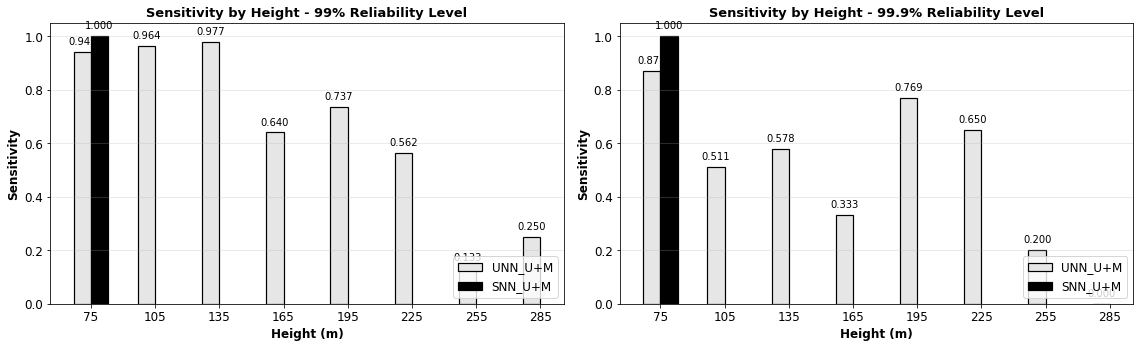

In [57]:
import matplotlib.pyplot as plt
import numpy as np

# Sort dictionaries by height for consistent ordering
heights_nn_99 = sorted(nn_99_mcs_n_usi_sensitivity_by_height.keys())
heights_nn_999 = sorted(nn_999_mcs_n_usi_sensitivity_by_height.keys())
heights_cal_nn_99 = sorted(cal_nn_99_mcs_n_usi_sensitivity_by_height.keys())
heights_cal_nn_999 = sorted(cal_nn_999_mcs_n_usi_sensitivity_by_height.keys())

# Ensure heights are the same for both nn and cal_nn dicts
if heights_nn_99 != heights_cal_nn_99:
    common_heights_99 = sorted(set(heights_nn_99) & set(heights_cal_nn_99))
else:
    common_heights_99 = heights_nn_99
if heights_nn_999 != heights_cal_nn_999:
    common_heights_999 = sorted(set(heights_nn_999) & set(heights_cal_nn_999))
else:
    common_heights_999 = heights_nn_999

# Get sensitivity values for NN
nn_99_sens = [nn_99_mcs_n_usi_sensitivity_by_height[h] for h in common_heights_99]
nn_999_sens = [nn_999_mcs_n_usi_sensitivity_by_height[h] for h in common_heights_999]

# Get sensitivity values for Calibrated NN
cal_nn_99_sens = [cal_nn_99_mcs_n_usi_sensitivity_by_height[h] for h in common_heights_99]
cal_nn_999_sens = [cal_nn_999_mcs_n_usi_sensitivity_by_height[h] for h in common_heights_999]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plt.rcParams.update({'font.size': 12})

# Bar width and spacing parameters
width = 0.35
width_multiplier = 1.3  # For the gap between height groups
x_positions_99 = np.arange(len(common_heights_99), dtype=float) * width_multiplier
x_positions_999 = np.arange(len(common_heights_999), dtype=float) * width_multiplier
# ============================================================================
# Plot 1: 99% Reliability Level
# ============================================================================
bars_nn_99 = ax1.bar(x_positions_99, nn_99_sens, width, label='UNN_U+M', 
                     edgecolor='black', color='0.9', linewidth=1.2)
bars_cal_nn_99 = ax1.bar(x_positions_99 + width, cal_nn_99_sens, width, label='SNN_U+M', 
                         edgecolor='black', color='0', linewidth=1.2)

ax1.set_xlabel('Height (m)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Sensitivity', fontsize=12, fontweight='bold')
ax1.set_title('Sensitivity by Height - 99% Reliability Level', fontsize=13, fontweight='bold')
ax1.set_xticks(x_positions_99 + width / 2)
ax1.set_xticklabels(common_heights_99)
ax1.set_ylim(0, 1.05)
ax1.grid(axis='y', alpha=0.3)
ax1.legend(loc='lower right')

# Add value labels for 99% plot
def add_value_labels(bars, ax):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

add_value_labels(bars_nn_99, ax1)
add_value_labels(bars_cal_nn_99, ax1)

# ============================================================================
# Plot 2: 99.9% Reliability Level
# ============================================================================
bars_nn_999 = ax2.bar(x_positions_999, nn_999_sens, width, label='UNN_U+M', 
                      edgecolor='black', color='0.9', linewidth=1.2)
bars_cal_nn_999 = ax2.bar(x_positions_999 + width, cal_nn_999_sens, width, label='SNN_U+M', 
                          edgecolor='black', color='0', linewidth=1.2)

ax2.set_xlabel('Height (m)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Sensitivity', fontsize=12, fontweight='bold')
ax2.set_title('Sensitivity by Height - 99.9% Reliability Level', fontsize=13, fontweight='bold')
ax2.set_xticks(x_positions_999 + width / 2)
ax2.set_xticklabels(common_heights_999)
ax2.set_ylim(0, 1.05)
ax2.grid(axis='y', alpha=0.3)
ax2.legend(loc='lower right')

# Add value labels for 99.9% plot
add_value_labels(bars_nn_999, ax2)
add_value_labels(bars_cal_nn_999, ax2)

plt.tight_layout()
plt.show()

### Sensitivity Comparison (by Height) between SNN_U+M, SNN_U, and SNN+M

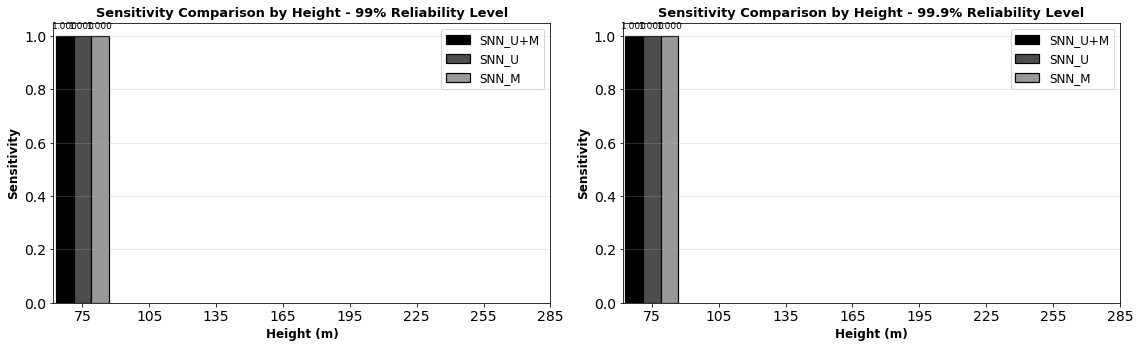

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# Sort dictionaries by height for consistent ordering
heights_nn_99_mcs_n_usi = sorted(cal_nn_99_mcs_n_usi_sensitivity_by_height.keys())
heights_nn_99_usi = sorted(cal_nn_99_usi_sensitivity_by_height.keys())
heights_nn_99_mcs = sorted(cal_nn_99_mcs_sensitivity_by_height.keys())

heights_nn_999_mcs_n_usi = sorted(cal_nn_999_mcs_n_usi_sensitivity_by_height.keys())
heights_nn_999_usi = sorted(cal_nn_999_usi_sensitivity_by_height.keys())
heights_nn_999_mcs = sorted(cal_nn_999_mcs_sensitivity_by_height.keys())

# Find common heights for 99% reliability level
common_heights_99 = sorted(set(heights_nn_99_mcs_n_usi) & set(heights_nn_99_usi) & set(heights_nn_99_mcs))

# Find common heights for 99.9% reliability level
common_heights_999 = sorted(set(heights_nn_999_mcs_n_usi) & set(heights_nn_999_usi) & set(heights_nn_999_mcs))

# Get sensitivity values for 99% reliability level
cal_nn_99_mcs_n_usi_sens = [cal_nn_99_mcs_n_usi_sensitivity_by_height[h] for h in common_heights_99]
cal_nn_99_usi_sens = [cal_nn_99_usi_sensitivity_by_height[h] for h in common_heights_99]
cal_nn_99_mcs_sens = [cal_nn_99_mcs_sensitivity_by_height[h] for h in common_heights_99]

# Get sensitivity values for 99.9% reliability level
cal_nn_999_mcs_n_usi_sens = [cal_nn_999_mcs_n_usi_sensitivity_by_height[h] for h in common_heights_999]
cal_nn_999_usi_sens = [cal_nn_999_usi_sensitivity_by_height[h] for h in common_heights_999]
cal_nn_999_mcs_sens = [cal_nn_999_mcs_sensitivity_by_height[h] for h in common_heights_999]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plt.rcParams.update({'font.size': 12})

# Bar width and spacing parameters
width = 0.25
width_multiplier = 1.0  # For the gap between height groups
x_positions_99 = np.arange(len(common_heights_99), dtype=float) * (3 * width + 0.2)
x_positions_999 = np.arange(len(common_heights_999), dtype=float) * (3 * width + 0.2)

# ============================================================================
# Plot 1: 99% Reliability Level
# ============================================================================
bars_nn_99_mcs_n_usi = ax1.bar(x_positions_99 - width, cal_nn_99_mcs_n_usi_sens, width, label='SNN_U+M', 
                               edgecolor='black', color='0', linewidth=1.2)
bars_nn_99_usi = ax1.bar(x_positions_99, cal_nn_99_usi_sens, width, label='SNN_U', 
                         edgecolor='black', color='0.3', linewidth=1.2)
bars_nn_99_mcs = ax1.bar(x_positions_99 + width, cal_nn_99_mcs_sens, width, label='SNN_M', 
                         edgecolor='black', color='0.6', linewidth=1.2)

ax1.set_xlabel('Height (m)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Sensitivity', fontsize=12, fontweight='bold')
ax1.set_title('Sensitivity Comparison by Height - 99% Reliability Level', fontsize=13, fontweight='bold')
ax1.set_xticks(x_positions_99)
ax1.set_xticklabels(common_heights_99)
ax1.set_ylim(0, 1.05)
ax1.grid(axis='y', alpha=0.3)
ax1.legend(loc='upper right')

# Add value labels for 99% plot
def add_value_labels(bars, ax):
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)

add_value_labels(bars_nn_99_mcs_n_usi, ax1)
add_value_labels(bars_nn_99_usi, ax1)
add_value_labels(bars_nn_99_mcs, ax1)

# ============================================================================
# Plot 2: 99.9% Reliability Level
# ============================================================================
bars_nn_999_mcs_n_usi = ax2.bar(x_positions_999 - width, cal_nn_999_mcs_n_usi_sens, width, label='SNN_U+M', 
                                edgecolor='black', color='0', linewidth=1.2)
bars_nn_999_usi = ax2.bar(x_positions_999, cal_nn_999_usi_sens, width, label='SNN_U', 
                          edgecolor='black', color='0.3', linewidth=1.2)
bars_nn_999_mcs = ax2.bar(x_positions_999 + width, cal_nn_999_mcs_sens, width, label='SNN_M', 
                          edgecolor='black', color='0.6', linewidth=1.2)

ax2.set_xlabel('Height (m)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Sensitivity', fontsize=12, fontweight='bold')
ax2.set_title('Sensitivity Comparison by Height - 99.9% Reliability Level', fontsize=13, fontweight='bold')
ax2.set_xticks(x_positions_999)
ax2.set_xticklabels(common_heights_999)
ax2.set_ylim(0, 1.05)
ax2.grid(axis='y', alpha=0.3)
ax2.legend(loc='upper right')

# Add value labels for 99.9% plot
add_value_labels(bars_nn_999_mcs_n_usi, ax2)
add_value_labels(bars_nn_999_usi, ax2)
add_value_labels(bars_nn_999_mcs, ax2)

plt.tight_layout()
plt.show()


### Specificity Comparison (by Height) between UNN_U+M and SNN_U+M

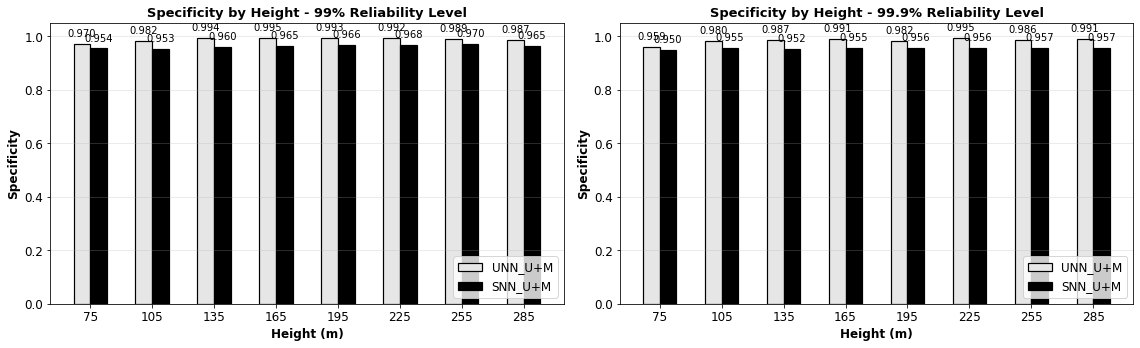

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Sort dictionaries by height for consistent ordering
heights_nn_99 = sorted(nn_99_mcs_n_usi_specificity_by_height.keys())
heights_nn_999 = sorted(nn_999_mcs_n_usi_specificity_by_height.keys())
heights_cal_nn_99 = sorted(cal_nn_99_mcs_n_usi_specificity_by_height.keys())
heights_cal_nn_999 = sorted(cal_nn_999_mcs_n_usi_specificity_by_height.keys())

# Ensure heights are the same for both nn and cal_nn dicts
if heights_nn_99 != heights_cal_nn_99:
    common_heights_99 = sorted(set(heights_nn_99) & set(heights_cal_nn_99))
else:
    common_heights_99 = heights_nn_99
if heights_nn_999 != heights_cal_nn_999:
    common_heights_999 = sorted(set(heights_nn_999) & set(heights_cal_nn_999))
else:
    common_heights_999 = heights_nn_999

# Get specificity values for NN
nn_99_spec = [nn_99_mcs_n_usi_specificity_by_height[h] for h in common_heights_99]
nn_999_spec = [nn_999_mcs_n_usi_specificity_by_height[h] for h in common_heights_999]
# Get specificity values for Calibrated NN
cal_nn_99_spec = [cal_nn_99_mcs_n_usi_specificity_by_height[h] for h in common_heights_99]
cal_nn_999_spec = [cal_nn_999_mcs_n_usi_specificity_by_height[h] for h in common_heights_999]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plt.rcParams.update({'font.size': 12})

# Bar width and spacing parameters
width = 0.35
width_multiplier = 1.3  # For the gap between height groups
x_positions_99 = np.arange(len(common_heights_99), dtype=float) * width_multiplier
x_positions_999 = np.arange(len(common_heights_999), dtype=float) * width_multiplier

# ============================================================================
# Plot 1: 99% Reliability Level
# ============================================================================
bars_nn_99 = ax1.bar(x_positions_99, nn_99_spec, width, label='UNN_U+M', 
                     edgecolor='black', color='0.9', linewidth=1.2)
bars_cal_nn_99 = ax1.bar(x_positions_99 + width, cal_nn_99_spec, width, label='SNN_U+M', 
                         edgecolor='black', color='0', linewidth=1.2)

ax1.set_xlabel('Height (m)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Specificity', fontsize=12, fontweight='bold')
ax1.set_title('Specificity by Height - 99% Reliability Level', fontsize=13, fontweight='bold')
ax1.set_xticks(x_positions_99 + width / 2)
ax1.set_xticklabels(common_heights_99)
ax1.set_ylim(0, 1.05)
ax1.grid(axis='y', alpha=0.3)
ax1.legend(loc='lower right')

# Add value labels for 99% plot
def add_value_labels(bars, ax):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

add_value_labels(bars_nn_99, ax1)
add_value_labels(bars_cal_nn_99, ax1)

# ============================================================================
# Plot 2: 99.9% Reliability Level
# ============================================================================
bars_nn_999 = ax2.bar(x_positions_999, nn_999_spec, width, label='UNN_U+M', 
                      edgecolor='black', color='0.9', linewidth=1.2)
bars_cal_nn_999 = ax2.bar(x_positions_999 + width, cal_nn_999_spec, width, label='SNN_U+M', 
                          edgecolor='black', color='0', linewidth=1.2)

ax2.set_xlabel('Height (m)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Specificity', fontsize=12, fontweight='bold')
ax2.set_title('Specificity by Height - 99.9% Reliability Level', fontsize=13, fontweight='bold')
ax2.set_xticks(x_positions_999 + width / 2)
ax2.set_xticklabels(common_heights_999)
ax2.set_ylim(0, 1.05)
ax2.grid(axis='y', alpha=0.3)
ax2.legend(loc='lower right')

# Add value labels for 99.9% plot
add_value_labels(bars_nn_999, ax2)
add_value_labels(bars_cal_nn_999, ax2)

plt.tight_layout()
plt.show()

### Specificity Comparison (by Height) between SNN_U+M, SNN_U, and SNN+M

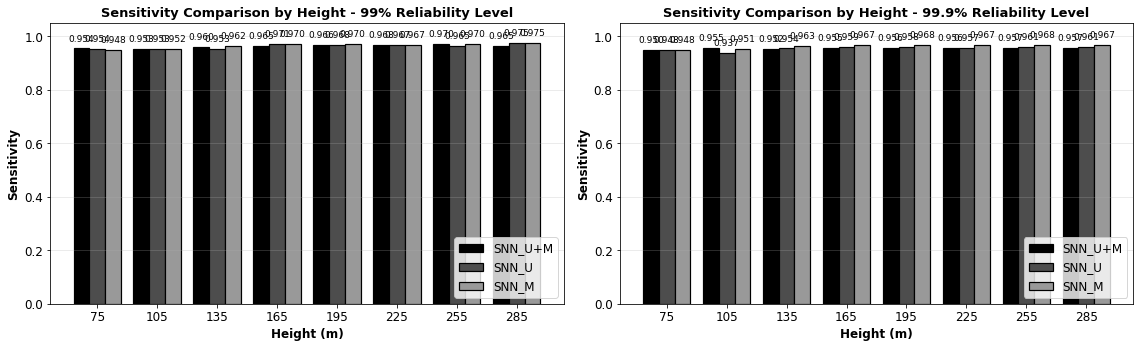

In [64]:
# Sort dictionaries by height for consistent ordering
heights_nn_99_mcs_n_usi = sorted(cal_nn_99_mcs_n_usi_specificity_by_height.keys())
heights_nn_99_usi = sorted(cal_nn_99_usi_specificity_by_height.keys())
heights_nn_99_mcs = sorted(cal_nn_99_mcs_specificity_by_height.keys())

heights_nn_999_mcs_n_usi = sorted(cal_nn_999_mcs_n_usi_specificity_by_height.keys())
heights_nn_999_usi = sorted(cal_nn_999_usi_specificity_by_height.keys())
heights_nn_999_mcs = sorted(cal_nn_999_mcs_specificity_by_height.keys())

# Find common heights for 99% reliability level
common_heights_99 = sorted(set(heights_nn_99_mcs_n_usi) & set(heights_nn_99_usi) & set(heights_nn_99_mcs))

# Find common heights for 99.9% reliability level
common_heights_999 = sorted(set(heights_nn_999_mcs_n_usi) & set(heights_nn_999_usi) & set(heights_nn_999_mcs))

# Get sensitivity values for 99% reliability level
cal_nn_99_mcs_n_usi_spec = [cal_nn_99_mcs_n_usi_specificity_by_height[h] for h in common_heights_99]
cal_nn_99_usi_spec = [cal_nn_99_usi_specificity_by_height[h] for h in common_heights_99]
cal_nn_99_mcs_spec = [cal_nn_99_mcs_specificity_by_height[h] for h in common_heights_99]

# Get sensitivity values for 99.9% reliability level
cal_nn_999_mcs_n_usi_spec = [cal_nn_999_mcs_n_usi_specificity_by_height[h] for h in common_heights_999]
cal_nn_999_usi_spec = [cal_nn_999_usi_specificity_by_height[h] for h in common_heights_999]
cal_nn_999_mcs_spec = [cal_nn_999_mcs_specificity_by_height[h] for h in common_heights_999]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plt.rcParams.update({'font.size': 12})

# Bar width and spacing parameters
width = 0.25
width_multiplier = 1.0  # For the gap between height groups
x_positions_99 = np.arange(len(common_heights_99), dtype=float) * (3 * width + 0.2)
x_positions_999 = np.arange(len(common_heights_999), dtype=float) * (3 * width + 0.2)

# ============================================================================
# Plot 1: 99% Reliability Level
# ============================================================================
bars_nn_99_mcs_n_usi = ax1.bar(x_positions_99 - width, cal_nn_99_mcs_n_usi_spec, width, label='SNN_U+M', 
                               edgecolor='black', color='0', linewidth=1.2)
bars_nn_99_usi = ax1.bar(x_positions_99, cal_nn_99_usi_spec, width, label='SNN_U', 
                         edgecolor='black', color='0.3', linewidth=1.2)
bars_nn_99_mcs = ax1.bar(x_positions_99 + width, cal_nn_99_mcs_spec, width, label='SNN_M', 
                         edgecolor='black', color='0.6', linewidth=1.2)

ax1.set_xlabel('Height (m)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Sensitivity', fontsize=12, fontweight='bold')
ax1.set_title('Sensitivity Comparison by Height - 99% Reliability Level', fontsize=13, fontweight='bold')
ax1.set_xticks(x_positions_99)
ax1.set_xticklabels(common_heights_99)
ax1.set_ylim(0, 1.05)
ax1.grid(axis='y', alpha=0.3)
ax1.legend(loc='lower right')

# Add value labels for 99% plot
def add_value_labels(bars, ax):
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)

add_value_labels(bars_nn_99_mcs_n_usi, ax1)
add_value_labels(bars_nn_99_usi, ax1)
add_value_labels(bars_nn_99_mcs, ax1)

# ============================================================================
# Plot 2: 99.9% Reliability Level
# ============================================================================
bars_nn_999_mcs_n_usi = ax2.bar(x_positions_999 - width, cal_nn_999_mcs_n_usi_spec, width, label='SNN_U+M', 
                                edgecolor='black', color='0', linewidth=1.2)
bars_nn_999_usi = ax2.bar(x_positions_999, cal_nn_999_usi_spec, width, label='SNN_U', 
                          edgecolor='black', color='0.3', linewidth=1.2)
bars_nn_999_mcs = ax2.bar(x_positions_999 + width, cal_nn_999_mcs_spec, width, label='SNN_M', 
                          edgecolor='black', color='0.6', linewidth=1.2)

ax2.set_xlabel('Height (m)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Sensitivity', fontsize=12, fontweight='bold')
ax2.set_title('Sensitivity Comparison by Height - 99.9% Reliability Level', fontsize=13, fontweight='bold')
ax2.set_xticks(x_positions_999)
ax2.set_xticklabels(common_heights_999)
ax2.set_ylim(0, 1.05)
ax2.grid(axis='y', alpha=0.3)
ax2.legend(loc='lower right')

# Add value labels for 99.9% plot
add_value_labels(bars_nn_999_mcs_n_usi, ax2)
add_value_labels(bars_nn_999_usi, ax2)
add_value_labels(bars_nn_999_mcs, ax2)

plt.tight_layout()
plt.show()


### Success Rate

In [ ]:
plt.figure(figsize=(16,4))
plt.rcParams.update({'font.size': 14})

# # With 90% Results ============================================================
# ind = np.arange(11, dtype=float)  
# width = 0.25
# width_multiplier = 1.2 # For the gap between bars
# x = ind + width * width_multiplier / 2
# nn_res = [nn_90_mcs_success_rate, nn_99_mcs_success_rate, nn_999_mcs_success_rate, 
#           nn_90_usi_success_rate, nn_99_usi_success_rate, nn_999_usi_success_rate, 
#           nn_90_mcs_n_usi_success_rate, nn_99_mcs_n_usi_success_rate, nn_999_mcs_n_usi_success_rate]
# cnn_res = [cal_nn_90_mcs_success_rate, cal_nn_99_mcs_success_rate, cal_nn_999_mcs_success_rate, 
#            cal_nn_90_usi_success_rate, cal_nn_99_usi_success_rate, cal_nn_999_usi_success_rate,
#            cal_nn_90_mcs_n_usi_success_rate, cal_nn_99_mcs_n_usi_success_rate, cal_nn_999_mcs_n_usi_success_rate]
# nn_res = np.insert(nn_res, [3, 6], 0)
# cnn_res = np.insert(cnn_res, [3, 6], 0)
# # With 90% Results ============================================================

# Without 90% Results ============================================================
ind = np.arange(8, dtype=float)  
width = 0.25
width_multiplier = 1.2 # For the gap between bars
x = ind + width * width_multiplier / 2
nn_res = [nn_99_mcs_success_rate, nn_999_mcs_success_rate, 
          nn_99_usi_success_rate, nn_999_usi_success_rate, 
          nn_99_mcs_n_usi_success_rate, nn_999_mcs_n_usi_success_rate]
cnn_res = [cal_nn_99_mcs_success_rate, cal_nn_999_mcs_success_rate, 
           cal_nn_99_usi_success_rate, cal_nn_999_usi_success_rate,
           cal_nn_99_mcs_n_usi_success_rate, cal_nn_999_mcs_n_usi_success_rate]
nn_res = np.insert(nn_res, [2, 4], 0)
cnn_res = np.insert(cnn_res, [2, 4], 0)
# Without 90% Results ============================================================

# Get bar results to plot
bar_nn = plt.bar(ind, nn_res*100, width, edgecolor='black', color = '0.6') 
bar_cnn = plt.bar(ind + width * width_multiplier, cnn_res*100, width, edgecolor='black', color = '0') 

plt.ylim(0, 101)
plt.ylabel("{} (%)".format("Success Rate")) 
plt.xlabel("Required Reliability Level (%)")
# plt.xticks(x,['90.0%', '99.0%\nMCS Adaptation', '99.9%', '', '90.0%', '99.0%\nUSI Adaptation', '99.9%', '', '90.0%', '99.0%\nMCS & USI Adaptation', '99.9%'])
plt.xticks(x,['99.0%\n                        MCS Adaptation', '99.9%', '', 
              '99.0%\n                        USI Adaptation', '99.9%', '', 
              '99.0%\n                        MCS & USI Adaptation', '99.9%'])
plt.tick_params(axis='x', which='both',length=0)
plt.legend( (bar_nn, bar_cnn), ('UNN', 'CNN'), bbox_to_anchor=(0, 1.05, 1, 0.2), loc="lower center", borderaxespad=0, ncol=3) 

# function to add value labels
def addlabels(X,y):
    i = 0
    for x in X:
        plt.text(x, y[i]+1, "%.2f" % round(y[i], 2), ha = 'center')
        i += 1

# Remove the values for gap bars
nn_res = np.delete(nn_res, 5)
cnn_res = np.delete(cnn_res, 5)
ind = np.delete(ind, 5)
nn_res = np.delete(nn_res, 2)
cnn_res = np.delete(cnn_res, 2)
ind = np.delete(ind, 2)
# Value labels for NN
addlabels(ind, nn_res*100)
# Value labels for Cal NN
addlabels(ind + width * width_multiplier, cnn_res*100)

### Success Rate Comparison (by Height) between UNN_U+M and SNN_U+M

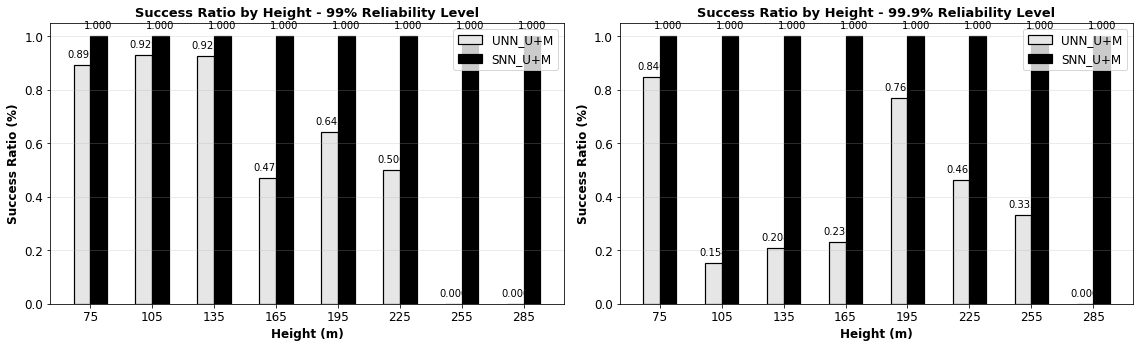

In [56]:
# Sort dictionaries by height for consistent ordering
heights_nn_99 = sorted(nn_99_mcs_n_usi_success_rate_by_height.keys())
heights_nn_999 = sorted(nn_999_mcs_n_usi_success_rate_by_height.keys())
heights_cal_nn_99 = sorted(cal_nn_99_mcs_n_usi_success_rate_by_height.keys())
heights_cal_nn_999 = sorted(cal_nn_999_mcs_n_usi_success_rate_by_height.keys())

# Ensure heights are the same for both nn and cal_nn dicts
if heights_nn_99 != heights_cal_nn_99:
    common_heights_99 = sorted(set(heights_nn_99) & set(heights_cal_nn_99))
else:
    common_heights_99 = heights_nn_99
if heights_nn_999 != heights_cal_nn_999:
    common_heights_999 = sorted(set(heights_nn_999) & set(heights_cal_nn_999))
else:
    common_heights_999 = heights_nn_999

# Get specificity values for NN
nn_99_sr = [nn_99_mcs_n_usi_success_rate_by_height[h] for h in common_heights_99]
nn_999_sr = [nn_999_mcs_n_usi_success_rate_by_height[h] for h in common_heights_999]
# Get specificity values for Calibrated NN
cal_nn_99_sr = [cal_nn_99_mcs_n_usi_success_rate_by_height[h] for h in common_heights_99]
cal_nn_999_sr = [cal_nn_999_mcs_n_usi_success_rate_by_height[h] for h in common_heights_999]
# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plt.rcParams.update({'font.size': 12})

# Bar width and spacing parameters
width = 0.35
width_multiplier = 1.3  # For the gap between height groups
x_positions_99 = np.arange(len(common_heights_99), dtype=float) * width_multiplier
x_positions_999 = np.arange(len(common_heights_999), dtype=float) * width_multiplier

# ============================================================================
# Plot 1: 99% Reliability Level
# ============================================================================
bars_nn_99 = ax1.bar(x_positions_99, nn_99_sr, width, label='UNN_U+M', 
                     edgecolor='black', color='0.9', linewidth=1.2)
bars_cal_nn_99 = ax1.bar(x_positions_99 + width, cal_nn_99_sr, width, label='SNN_U+M', 
                         edgecolor='black', color='0', linewidth=1.2)

ax1.set_xlabel('Height (m)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Success Ratio (%)', fontsize=12, fontweight='bold')
ax1.set_title('Success Ratio by Height - 99% Reliability Level', fontsize=13, fontweight='bold')
ax1.set_xticks(x_positions_99 + width / 2)
ax1.set_xticklabels(common_heights_99)
ax1.set_ylim(0, 1.05)
ax1.grid(axis='y', alpha=0.3)
ax1.legend(loc='upper right')

# Add value labels for 99% plot
def add_value_labels(bars, ax):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

add_value_labels(bars_nn_99, ax1)
add_value_labels(bars_cal_nn_99, ax1)

# ============================================================================
# Plot 2: 99.9% Reliability Level
# ============================================================================
bars_nn_999 = ax2.bar(x_positions_999, nn_999_sr, width, label='UNN_U+M', 
                      edgecolor='black', color='0.9', linewidth=1.2)
bars_cal_nn_999 = ax2.bar(x_positions_999 + width, cal_nn_999_sr, width, label='SNN_U+M', 
                          edgecolor='black', color='0', linewidth=1.2)

ax2.set_xlabel('Height (m)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Success Ratio (%)', fontsize=12, fontweight='bold')
ax2.set_title('Success Ratio by Height - 99.9% Reliability Level', fontsize=13, fontweight='bold')
ax2.set_xticks(x_positions_999 + width / 2)
ax2.set_xticklabels(common_heights_999)
ax2.set_ylim(0, 1.05)
ax2.grid(axis='y', alpha=0.3)
ax2.legend(loc='upper right')

# Add value labels for 99.9% plot
add_value_labels(bars_nn_999, ax2)
add_value_labels(bars_cal_nn_999, ax2)

plt.tight_layout()
plt.show()

### Success Rate Comparison (by Height) between SNN_U+M, SNN_U, SNN+M

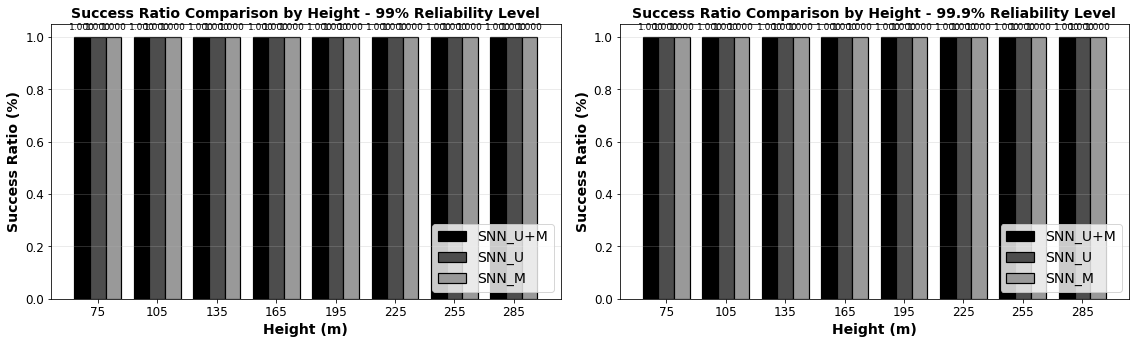

In [61]:
# Sort dictionaries by height for consistent ordering
heights_nn_99_mcs_n_usi = sorted(cal_nn_99_mcs_n_usi_success_rate_by_height.keys())
heights_nn_99_usi = sorted(cal_nn_99_usi_success_rate_by_height.keys())
heights_nn_99_mcs = sorted(cal_nn_99_mcs_success_rate_by_height.keys())

heights_nn_999_mcs_n_usi = sorted(cal_nn_999_mcs_n_usi_success_rate_by_height.keys())
heights_nn_999_usi = sorted(cal_nn_999_usi_success_rate_by_height.keys())
heights_nn_999_mcs = sorted(cal_nn_999_mcs_success_rate_by_height.keys())

# Find common heights for 99% reliability level
common_heights_99 = sorted(set(heights_nn_99_mcs_n_usi) & set(heights_nn_99_usi) & set(heights_nn_99_mcs))

# Find common heights for 99.9% reliability level
common_heights_999 = sorted(set(heights_nn_999_mcs_n_usi) & set(heights_nn_999_usi) & set(heights_nn_999_mcs))

# Get sensitivity values for 99% reliability level
cal_nn_99_mcs_n_usi_sr = [cal_nn_99_mcs_n_usi_success_rate_by_height[h] for h in common_heights_99]
cal_nn_99_usi_sr = [cal_nn_99_usi_success_rate_by_height[h] for h in common_heights_99]
cal_nn_99_mcs_sr = [cal_nn_99_mcs_success_rate_by_height[h] for h in common_heights_99]

# Get sensitivity values for 99.9% reliability level
cal_nn_999_mcs_n_usi_sr = [cal_nn_999_mcs_n_usi_success_rate_by_height[h] for h in common_heights_999]
cal_nn_999_usi_sr = [cal_nn_999_usi_success_rate_by_height[h] for h in common_heights_999]
cal_nn_999_mcs_sr = [cal_nn_999_mcs_success_rate_by_height[h] for h in common_heights_999]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plt.rcParams.update({'font.size': 14})

# Bar width and spacing parameters
width = 0.25
width_multiplier = 1.0  # For the gap between height groups
x_positions_99 = np.arange(len(common_heights_99), dtype=float) * (3 * width + 0.2)
x_positions_999 = np.arange(len(common_heights_999), dtype=float) * (3 * width + 0.2)

# ============================================================================
# Plot 1: 99% Reliability Level
# ============================================================================
bars_nn_99_mcs_n_usi = ax1.bar(x_positions_99 - width, cal_nn_99_mcs_n_usi_sr, width, label='SNN_U+M', 
                               edgecolor='black', color='0', linewidth=1.2)
bars_nn_99_usi = ax1.bar(x_positions_99, cal_nn_99_usi_sr, width, label='SNN_U', 
                         edgecolor='black', color='0.3', linewidth=1.2)
bars_nn_99_mcs = ax1.bar(x_positions_99 + width, cal_nn_99_mcs_sr, width, label='SNN_M', 
                         edgecolor='black', color='0.6', linewidth=1.2)

ax1.set_xlabel('Height (m)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Success Ratio (%)', fontsize=14, fontweight='bold')
ax1.set_title('Success Ratio Comparison by Height - 99% Reliability Level', fontsize=14, fontweight='bold')
ax1.set_xticks(x_positions_99)
ax1.set_xticklabels(common_heights_99)
ax1.set_ylim(0, 1.05)
ax1.grid(axis='y', alpha=0.3)
ax1.legend(loc='lower right')

# Add value labels for 99% plot
def add_value_labels(bars, ax):
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)

add_value_labels(bars_nn_99_mcs_n_usi, ax1)
add_value_labels(bars_nn_99_usi, ax1)
add_value_labels(bars_nn_99_mcs, ax1)

# ============================================================================
# Plot 2: 99.9% Reliability Level
# ============================================================================
bars_nn_999_mcs_n_usi = ax2.bar(x_positions_999 - width, cal_nn_999_mcs_n_usi_sr, width, label='SNN_U+M', 
                                edgecolor='black', color='0', linewidth=1.2)
bars_nn_999_usi = ax2.bar(x_positions_999, cal_nn_999_usi_sr, width, label='SNN_U', 
                          edgecolor='black', color='0.3', linewidth=1.2)
bars_nn_999_mcs = ax2.bar(x_positions_999 + width, cal_nn_999_mcs_sr, width, label='SNN_M', 
                          edgecolor='black', color='0.6', linewidth=1.2)

ax2.set_xlabel('Height (m)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Success Ratio (%)', fontsize=14, fontweight='bold')
ax2.set_title('Success Ratio Comparison by Height - 99.9% Reliability Level', fontsize=14, fontweight='bold')
ax2.set_xticks(x_positions_999)
ax2.set_xticklabels(common_heights_999)
ax2.set_ylim(0, 1.05)
ax2.grid(axis='y', alpha=0.3)
ax2.legend(loc='lower right')

# Add value labels for 99.9% plot
add_value_labels(bars_nn_999_mcs_n_usi, ax2)
add_value_labels(bars_nn_999_usi, ax2)
add_value_labels(bars_nn_999_mcs, ax2)

plt.tight_layout()
plt.show()


### Percentage D_max Box Plots

In [ ]:

# Plot the box plots of percentage d_max
plt.figure(figsize=(16,4))
plt.rcParams.update({'font.size': 14})
# Plot the box plots in pairs for nn and cal_nn results
data = [# nn_mcs_90_dmax_percentages, cal_nn_mcs_90_dmax_percentages, 
        nn_mcs_99_dmax_percentages, cal_nn_mcs_99_dmax_percentages, 
        nn_mcs_999_dmax_percentages, cal_nn_mcs_999_dmax_percentages,
        # nn_usi_90_dmax_percentages, cal_nn_usi_90_dmax_percentages, 
        nn_usi_99_dmax_percentages, cal_nn_usi_99_dmax_percentages, 
        nn_usi_999_dmax_percentages, cal_nn_999_usi_dmax_percentages, 
        # nn_mcs_n_usi_90_dmax_percentages, cal_nn_mcs_n_usi_90_dmax_percentages, 
        nn_mcs_n_usi_99_dmax_percentages, cal_nn_mcs_n_usi_99_dmax_percentages, 
        nn_mcs_n_usi_999_dmax_percentages, cal_nn_mcs_n_usi_999_dmax_percentages] 
width = 0.25
# box_positions = [1, 1.3, 2, 2.3, 3, 3.3, 4.5, 4.8, 5.5, 5.8, 6.5, 6.8, 8, 8.3, 9, 9.3, 10, 10.3]
# x_tick_positions = [1.15, 2.15, 3.15, 4.65, 5.65, 6.65, 8.15, 9.15, 10.15]
box_positions = [1, 1.3, 2, 2.3, 3.5, 3.8, 4.5, 4.8, 6, 6.3, 7, 7.3]
x_tick_positions = [1.15, 2.15, 3.65, 4.65, 6.15, 7.15]
# x_tick_labels = ['90.0%', '99.0%\n MCS Adaptation', '99.9%', '90.0%', '99.0%\n USI Adaptation', '99.9%', '90.0%', '99.0%\nMCS & USI Adaptation', '99.9%']
x_tick_labels = ['99.0%\n                        MCS Adaptation', '99.9%', 
                '99.0%\n                        USI Adaptation', '99.9%', 
                '99.0%\n                        MCS & USI Adaptation', '99.9%']

box = plt.boxplot(data, positions=box_positions, widths=width, patch_artist=True)
colors = ['0.6', '0'] * 9
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.xticks(x_tick_positions, x_tick_labels)
plt.ylim(-1, 101)
plt.ylabel("Percentage of $D_{max}$ Achieved (%)") 
plt.xlabel("Required Reliability Level (%)")    
plt.legend( (bar_nn, bar_cnn), ('UNN', 'CNN'), bbox_to_anchor=(0, 1.05, 1, 0.2), loc="lower center", borderaxespad=0, ncol=3) # Borrow the bars from previous plots for legend


### Percentage D_max Boxplots Comparison (by Height) between UNN_U+M and SNN_U+M

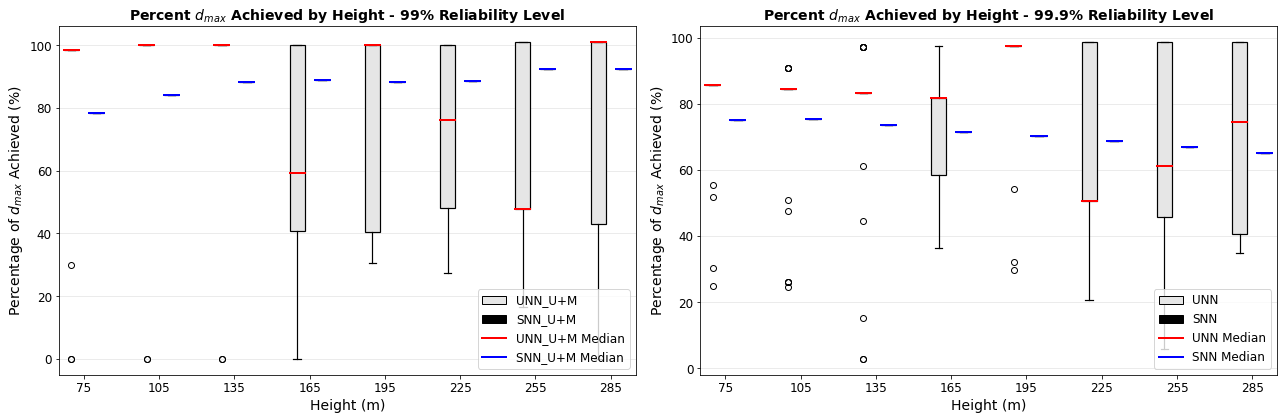

In [60]:
# TODO: Exclude hdist after failure occured for UNN

# Sort dictionaries by height for consistent ordering
heights_nn_99 = sorted(nn_99_mcs_n_usi_percent_dmax_by_height.keys())
heights_nn_999 = sorted(nn_999_mcs_n_usi_percent_dmax_by_height.keys())
heights_cal_nn_99 = sorted(cal_nn_99_mcs_n_usi_percent_dmax_by_height.keys())
heights_cal_nn_999 = sorted(cal_nn_999_mcs_n_usi_percent_dmax_by_height.keys())

# Ensure heights are the same for both nn and cal_nn dicts
if heights_nn_99 != heights_cal_nn_99:
    common_heights_99 = sorted(set(heights_nn_99) & set(heights_cal_nn_99))
else:
    common_heights_99 = heights_nn_99
if heights_nn_999 != heights_cal_nn_999:
    common_heights_999 = sorted(set(heights_nn_999) & set(heights_cal_nn_999))
else:
    common_heights_999 = heights_nn_999

# Prepare data for box plots
# For each height, we have a list of percent_dmax values from both NN and Cal NN
box_data_99_nn = [nn_99_mcs_n_usi_percent_dmax_by_height[h] for h in common_heights_99]
box_data_99_cal = [cal_nn_99_mcs_n_usi_percent_dmax_by_height[h] for h in common_heights_99]
box_data_999_nn = [nn_999_mcs_n_usi_percent_dmax_by_height[h] for h in common_heights_999]
box_data_999_cal = [cal_nn_999_mcs_n_usi_percent_dmax_by_height[h] for h in common_heights_999]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
plt.rcParams.update({'font.size': 12})

# ============================================================================
# Plot 1: 99% Reliability Level
# ============================================================================
# Create positions for box plots
num_heights_99 = len(common_heights_99)
positions_nn_99 = np.arange(1, num_heights_99 * 3, 3)  # Positions for NN boxes
positions_cal_99 = positions_nn_99 + 1  # Positions for Cal NN boxes (offset by 1)

# Create box plots for 99%
bp1_nn = ax1.boxplot(box_data_99_nn, positions=positions_nn_99, widths=0.6, patch_artist=True,
                      boxprops=dict(facecolor='0.9', edgecolor='black', linewidth=1.2),
                      whiskerprops=dict(color='black', linewidth=1.2),
                      capprops=dict(color='black', linewidth=1.2),
                      medianprops=dict(color='red', linewidth=2))

bp1_cal = ax1.boxplot(box_data_99_cal, positions=positions_cal_99, widths=0.6, patch_artist=True,
                       boxprops=dict(facecolor='0', edgecolor='black', linewidth=1.2),
                       whiskerprops=dict(color='black', linewidth=1.2),
                       capprops=dict(color='black', linewidth=1.2),
                       medianprops=dict(color='blue', linewidth=2))

ax1.set_xlabel('Height (m)', fontsize=14)
ax1.set_ylabel("Percentage of $d_{max}$ Achieved (%)", fontsize=14)
ax1.set_title('Percent $d_{max}$ Achieved by Height - 99% Reliability Level', fontsize=14, fontweight='bold')
ax1.set_xticks((positions_nn_99 + positions_cal_99) / 2)
ax1.set_xticklabels(common_heights_99)
ax1.grid(axis='y', alpha=0.3)

# Create custom legend with box and median colors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [Patch(facecolor='0.9', edgecolor='black', label='UNN_U+M'),
                   Patch(facecolor='0', edgecolor='black', label='SNN_U+M'),
                   Line2D([0], [0], color='red', linewidth=2, label='UNN_U+M Median'),
                   Line2D([0], [0], color='blue', linewidth=2, label='SNN_U+M Median')]
ax1.legend(handles=legend_elements, loc='lower right')

# ============================================================================
# Plot 2: 99.9% Reliability Level
# ============================================================================
# Create positions for box plots
num_heights_999 = len(common_heights_999)
positions_nn_999 = np.arange(1, num_heights_999 * 3, 3)
positions_cal_999 = positions_nn_999 + 1

# Create box plots for 99.9%
bp2_nn = ax2.boxplot(box_data_999_nn, positions=positions_nn_999, widths=0.6, patch_artist=True,
                      boxprops=dict(facecolor='0.9', edgecolor='black', linewidth=1.2),
                      whiskerprops=dict(color='black', linewidth=1.2),
                      capprops=dict(color='black', linewidth=1.2),
                      medianprops=dict(color='red', linewidth=2))

bp2_cal = ax2.boxplot(box_data_999_cal, positions=positions_cal_999, widths=0.6, patch_artist=True,
                       boxprops=dict(facecolor='0', edgecolor='black', linewidth=1.2),
                       whiskerprops=dict(color='black', linewidth=1.2),
                       capprops=dict(color='black', linewidth=1.2),
                       medianprops=dict(color='blue', linewidth=2))

ax2.set_xlabel('Height (m)', fontsize=14)
ax2.set_ylabel("Percentage of $d_{max}$ Achieved (%)", fontsize=14)
ax2.set_title('Percent $d_{max}$ Achieved by Height - 99.9% Reliability Level', fontsize=14, fontweight='bold')
ax2.set_xticks((positions_nn_999 + positions_cal_999) / 2)
ax2.set_xticklabels(common_heights_999)
ax2.grid(axis='y', alpha=0.3)

# Create custom legend with box and median colors
legend_elements_2 = [Patch(facecolor='0.9', edgecolor='black', label='UNN'),
                     Patch(facecolor='0', edgecolor='black', label='SNN'),
                     Line2D([0], [0], color='red', linewidth=2, label='UNN Median'),
                     Line2D([0], [0], color='blue', linewidth=2, label='SNN Median')]
ax2.legend(handles=legend_elements_2, loc='lower right')

plt.tight_layout()
plt.show()

### Percentage D_max Boxplots Comparison (by Height) between SNN_U+M, SNN_U, SNN_M

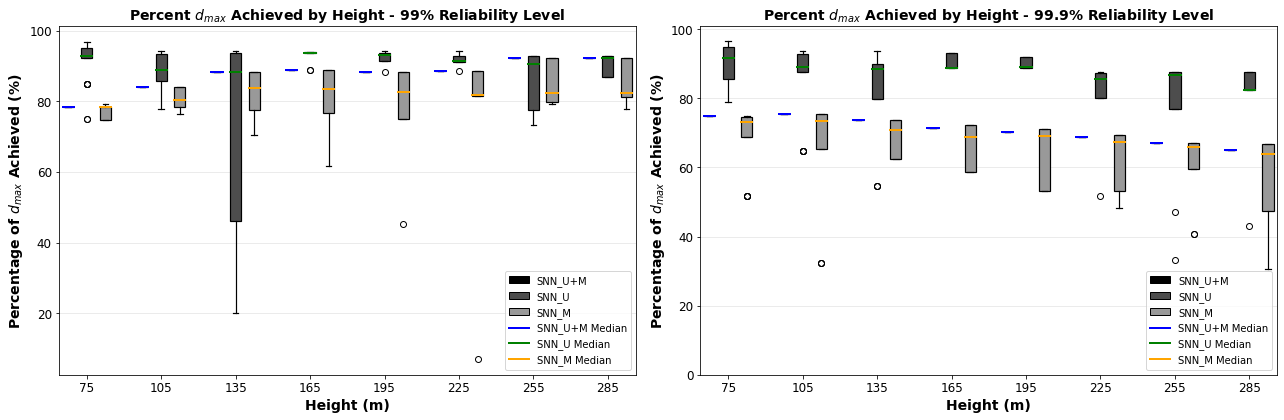

In [65]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Sort dictionaries by height for consistent ordering
heights_cal_99_mcs_n_usi = sorted(cal_nn_99_mcs_n_usi_percent_dmax_by_height.keys())
heights_cal_99_usi = sorted(cal_nn_99_usi_percent_dmax_by_height.keys())
heights_cal_99_mcs = sorted(cal_nn_99_mcs_percent_dmax_by_height.keys())

heights_cal_999_mcs_n_usi = sorted(cal_nn_999_mcs_n_usi_percent_dmax_by_height.keys())
heights_cal_999_usi = sorted(cal_nn_999_usi_percent_dmax_by_height.keys())
heights_cal_999_mcs = sorted(cal_nn_999_mcs_percent_dmax_by_height.keys())

# Find common heights for 99% reliability level
common_heights_99 = sorted(set(heights_cal_99_mcs_n_usi) & set(heights_cal_99_usi) & set(heights_cal_99_mcs))

# Find common heights for 99.9% reliability level
common_heights_999 = sorted(set(heights_cal_999_mcs_n_usi) & set(heights_cal_999_usi) & set(heights_cal_999_mcs))

# Prepare data for box plots at 99% reliability level
box_data_99_mcs_n_usi = [cal_nn_99_mcs_n_usi_percent_dmax_by_height[h] for h in common_heights_99]
box_data_99_usi = [cal_nn_99_usi_percent_dmax_by_height[h] for h in common_heights_99]
box_data_99_mcs = [cal_nn_99_mcs_percent_dmax_by_height[h] for h in common_heights_99]

# Prepare data for box plots at 99.9% reliability level
box_data_999_mcs_n_usi = [cal_nn_999_mcs_n_usi_percent_dmax_by_height[h] for h in common_heights_999]
box_data_999_usi = [cal_nn_999_usi_percent_dmax_by_height[h] for h in common_heights_999]
box_data_999_mcs = [cal_nn_999_mcs_percent_dmax_by_height[h] for h in common_heights_999]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
plt.rcParams.update({'font.size': 12})

# ============================================================================
# Plot 1: 99% Reliability Level
# ============================================================================
# Create positions for box plots
num_heights_99 = len(common_heights_99)
positions_99_mcs_n_usi = np.arange(1, num_heights_99 * 4, 4)
positions_99_usi = positions_99_mcs_n_usi + 1
positions_99_mcs = positions_99_mcs_n_usi + 2

# Create box plots for 99%
bp1_mcs_n_usi = ax1.boxplot(box_data_99_mcs_n_usi, positions=positions_99_mcs_n_usi, widths=0.6, patch_artist=True,
                             boxprops=dict(facecolor='0', edgecolor='black', linewidth=1.2),
                             whiskerprops=dict(color='black', linewidth=1.2),
                             capprops=dict(color='black', linewidth=1.2),
                             medianprops=dict(color='blue', linewidth=2))

bp1_usi = ax1.boxplot(box_data_99_usi, positions=positions_99_usi, widths=0.6, patch_artist=True,
                       boxprops=dict(facecolor='0.3', edgecolor='black', linewidth=1.2),
                       whiskerprops=dict(color='black', linewidth=1.2),
                       capprops=dict(color='black', linewidth=1.2),
                       medianprops=dict(color='green', linewidth=2))

bp1_mcs = ax1.boxplot(box_data_99_mcs, positions=positions_99_mcs, widths=0.6, patch_artist=True,
                       boxprops=dict(facecolor='0.6', edgecolor='black', linewidth=1.2),
                       whiskerprops=dict(color='black', linewidth=1.2),
                       capprops=dict(color='black', linewidth=1.2),
                       medianprops=dict(color='orange', linewidth=2))

ax1.set_xlabel('Height (m)', fontsize=14, fontweight='bold')
ax1.set_ylabel("Percentage of $d_{max}$ Achieved (%)", fontsize=14, fontweight='bold')
ax1.set_title('Percent $d_{max}$ Achieved by Height - 99% Reliability Level', fontsize=14, fontweight='bold')
ax1.set_xticks((positions_99_mcs_n_usi + positions_99_usi + positions_99_mcs) / 3)
ax1.set_xticklabels(common_heights_99)
ax1.grid(axis='y', alpha=0.3)

# Create custom legend
legend_elements_1 = [Patch(facecolor='0', edgecolor='black', label='SNN_U+M'),
                     Patch(facecolor='0.3', edgecolor='black', label='SNN_U'),
                     Patch(facecolor='0.6', edgecolor='black', label='SNN_M'),
                     Line2D([0], [0], color='blue', linewidth=2, label='SNN_U+M Median'),
                     Line2D([0], [0], color='green', linewidth=2, label='SNN_U Median'),
                     Line2D([0], [0], color='orange', linewidth=2, label='SNN_M Median')]
ax1.legend(handles=legend_elements_1, loc='lower right', fontsize=10)

# ============================================================================
# Plot 2: 99.9% Reliability Level
# ============================================================================
# Create positions for box plots
num_heights_999 = len(common_heights_999)
positions_999_mcs_n_usi = np.arange(1, num_heights_999 * 4, 4)
positions_999_usi = positions_999_mcs_n_usi + 1
positions_999_mcs = positions_999_mcs_n_usi + 2

# Create box plots for 99.9%
bp2_mcs_n_usi = ax2.boxplot(box_data_999_mcs_n_usi, positions=positions_999_mcs_n_usi, widths=0.6, patch_artist=True,
                             boxprops=dict(facecolor='0', edgecolor='black', linewidth=1.2),
                             whiskerprops=dict(color='black', linewidth=1.2),
                             capprops=dict(color='black', linewidth=1.2),
                             medianprops=dict(color='blue', linewidth=2))

bp2_usi = ax2.boxplot(box_data_999_usi, positions=positions_999_usi, widths=0.6, patch_artist=True,
                       boxprops=dict(facecolor='0.3', edgecolor='black', linewidth=1.2),
                       whiskerprops=dict(color='black', linewidth=1.2),
                       capprops=dict(color='black', linewidth=1.2),
                       medianprops=dict(color='green', linewidth=2))

bp2_mcs = ax2.boxplot(box_data_999_mcs, positions=positions_999_mcs, widths=0.6, patch_artist=True,
                       boxprops=dict(facecolor='0.6', edgecolor='black', linewidth=1.2),
                       whiskerprops=dict(color='black', linewidth=1.2),
                       capprops=dict(color='black', linewidth=1.2),
                       medianprops=dict(color='orange', linewidth=2))

ax2.set_xlabel('Height (m)', fontsize=14, fontweight='bold')
ax2.set_ylabel("Percentage of $d_{max}$ Achieved (%)", fontsize=14, fontweight='bold')
ax2.set_title('Percent $d_{max}$ Achieved by Height - 99.9% Reliability Level', fontsize=14, fontweight='bold')
ax2.set_xticks((positions_999_mcs_n_usi + positions_999_usi + positions_999_mcs) / 3)
ax2.set_xticklabels(common_heights_999)
ax2.set_ylim(0, 101)
ax2.grid(axis='y', alpha=0.3)

# Create custom legend
legend_elements_2 = [Patch(facecolor='0', edgecolor='black', label='SNN_U+M'),
                     Patch(facecolor='0.3', edgecolor='black', label='SNN_U'),
                     Patch(facecolor='0.6', edgecolor='black', label='SNN_M'),
                     Line2D([0], [0], color='blue', linewidth=2, label='SNN_U+M Median'),
                     Line2D([0], [0], color='green', linewidth=2, label='SNN_U Median'),
                     Line2D([0], [0], color='orange', linewidth=2, label='SNN_M Median')]
ax2.legend(handles=legend_elements_2, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()


### Comparison of SNN_U+M and UNN_U+M (Sensitivity, Specificity, Success Rate, Percentage D_max)

In [ ]:
""" Sensitivity, Specificity, Success Rate Plot """
plt.figure(figsize=(14,4))
plt.rcParams.update({'font.size': 14})
ind = np.arange(8, dtype=float)  
width = 0.25
width_multiplier = 1.2 # For the gap between bars
x = ind + width * width_multiplier / 2
nn_res = [nn_99_mcs_n_usi_sensitivity, nn_999_mcs_n_usi_sensitivity,
          nn_99_mcs_n_usi_specificity, nn_999_mcs_n_usi_specificity,
          nn_99_mcs_n_usi_success_rate, nn_999_mcs_n_usi_success_rate]
cnn_res = [cal_nn_99_mcs_n_usi_sensitivity, cal_nn_999_mcs_n_usi_sensitivity,
           cal_nn_99_mcs_n_usi_specificity, cal_nn_999_mcs_n_usi_specificity,
           cal_nn_99_mcs_n_usi_success_rate, cal_nn_999_mcs_n_usi_success_rate]

nn_res = np.insert(nn_res, [2, 4], 0)
cnn_res = np.insert(cnn_res, [2, 4], 0)

# Get bar results to plot
bar_nn = plt.bar(ind, nn_res*100, width, edgecolor='black', color = '0.6') 
bar_cnn = plt.bar(ind + width * width_multiplier, cnn_res*100, width, edgecolor='black', color = '0') 

plt.ylim(0, 101)
plt.ylabel("Sensitivity/Specificity/Success Rate (%)") 
plt.xlabel("Required Reliability Level (%)")
# plt.xticks(x,['90.0%', '99.0%\nMCS Adaptation', '99.9%', '', '90.0%', '99.0%\nUSI Adaptation', '99.9%', '', '90.0%', '99.0%\nMCS & USI Adaptation', '99.9%'])
plt.xticks(x,['99.0%\n                        Sensitivity', '99.9%', '', 
              '99.0%\n                        Specificity', '99.9%', '', 
              '99.0%\n                        Success Rate', '99.9%'])
plt.tick_params(axis='x', which='both',length=0)
plt.legend( (bar_nn, bar_cnn), ('UNN_U+M', 'SNN_U+M'), bbox_to_anchor=(0, 1.05, 1, 0.2), loc="lower center", borderaxespad=0, ncol=3) 

# function to add value labels
def addlabels(X,y):
    i = 0
    for x in X:
        plt.text(x, y[i]+1, "%.1f" % round(y[i], 1), ha = 'center')
        i += 1

# Remove the values for gap bars
nn_res = np.delete(nn_res, 5)
cnn_res = np.delete(cnn_res, 5)
ind = np.delete(ind, 5)
nn_res = np.delete(nn_res, 2)
cnn_res = np.delete(cnn_res, 2)
ind = np.delete(ind, 2)
# Value labels for NN
addlabels(ind, nn_res*100)
# Value labels for Cal NN
addlabels(ind + width * width_multiplier, cnn_res*100)


""" Percentage D_max Achieved Plot """
plt.figure(figsize=(8,4))
plt.rcParams.update({'font.size': 14})
# Plot the box plots in pairs for nn and cal_nn results
data = [nn_mcs_n_usi_99_dmax_percentages, cal_nn_mcs_n_usi_99_dmax_percentages, 
        nn_mcs_n_usi_999_dmax_percentages, cal_nn_mcs_n_usi_999_dmax_percentages] 
width = 0.4
box_positions = [1, 1.5, 2.5, 3]
x_tick_positions = [1.25, 2.75]
x_tick_labels = ['99.0%', '99.9%']

box = plt.boxplot(data, positions=box_positions, widths=width, patch_artist=True)
colors = ['0.6', '0'] * 9
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.xticks(x_tick_positions, x_tick_labels)
plt.ylim(-1, 101)
plt.ylabel("Percentage of $D_{max}$\nAchieved (%)") 
plt.xlabel("Required Reliability Level (%)")    
plt.legend( (bar_nn, bar_cnn), ('UNN_U+M', 'SNN_U+M'), bbox_to_anchor=(0, 1.05, 1, 0.2), loc="lower center", borderaxespad=0, ncol=3) # Borrow the bars from previous plots for legend


### Comparison of SNN_U+M, SNN_U and SNN_M (Sensitivity, Specificity, Success Rate, Percentage D_max)

In [ ]:
""" Sensitivity, Specificity, Success Rate Plot """
plt.figure(figsize=(14,4))
plt.rcParams.update({'font.size': 14})
ind = np.array([0, 1.25, 3, 4.25, 6, 7.25])
width = 0.25
width_multiplier = 1.2 # For the gap between bars
x = ind + width * width_multiplier
snn_m_res = np.array([cal_nn_99_mcs_sensitivity, cal_nn_999_mcs_sensitivity,
            cal_nn_99_mcs_specificity, cal_nn_999_mcs_specificity,
            cal_nn_99_mcs_success_rate, cal_nn_999_mcs_success_rate])
snn_u_res = np.array([cal_nn_99_usi_sensitivity, cal_nn_999_usi_sensitivity,
            cal_nn_99_usi_specificity, cal_nn_999_usi_specificity,
            cal_nn_99_usi_success_rate, cal_nn_999_usi_success_rate])
snn_m_u_res = np.array([cal_nn_99_mcs_n_usi_sensitivity, cal_nn_999_mcs_n_usi_sensitivity,
            cal_nn_99_mcs_n_usi_specificity, cal_nn_999_mcs_n_usi_specificity,
            cal_nn_99_mcs_n_usi_success_rate, cal_nn_999_mcs_n_usi_success_rate])

# Get bar results to plot
bar_snn_m = plt.bar(ind, snn_m_res*100, width, edgecolor='black', color = '0.6')
bar_snn_u = plt.bar(ind + width * width_multiplier, snn_u_res*100, width, edgecolor='black', color = '0.3') 
bar_snn_m_u = plt.bar(ind + width * 2*width_multiplier, snn_m_u_res*100, width, edgecolor='black', color = '0') 

plt.ylim(0, 101)
plt.ylabel("Sensitivity/Specificity/Success Rate (%)") 
plt.xlabel("Required Reliability Level (%)")
plt.xticks(x,['99.0%\n                        Sensitivity', '99.9%', 
              '99.0%\n                        Specificity', '99.9%', 
              '99.0%\n                        Success Rate', '99.9%'])
plt.tick_params(axis='x', which='both',length=0)
plt.legend( (bar_snn_m, bar_snn_u, bar_snn_m_u), ('SNN_M', 'SNN_U', 'SNN_M+U'), bbox_to_anchor=(0, 1.05, 1, 0.2), loc="lower center", borderaxespad=0, ncol=3) 

# function to add value labels
def addlabels(X,y):
    i = 0
    for x in X:
        # Put text with small font instead
        plt.text(x, y[i]+1, "%.1f" % round(y[i], 1), ha = 'center', fontsize=10)
        i += 1

# Value labels for SNN_M, SNN_U, SNN_M+U
addlabels(ind, snn_m_res*100)
addlabels(ind + width * width_multiplier, snn_u_res*100)
addlabels(ind + width * 2*width_multiplier, snn_m_u_res*100)


""" Percentage D_max Achieved Plot """
plt.figure(figsize=(8,4))
plt.rcParams.update({'font.size': 14})
# Plot the box plots in pairs for nn and cal_nn results
data = [cal_nn_mcs_99_dmax_percentages, cal_nn_usi_99_dmax_percentages, cal_nn_mcs_n_usi_99_dmax_percentages,
        cal_nn_mcs_999_dmax_percentages, cal_nn_usi_999_dmax_percentages, cal_nn_mcs_n_usi_999_dmax_percentages] 
width = 0.4
box_positions = [1, 1.5, 2, 3.5, 4, 4.5]
x_tick_positions = [1.5, 4]
x_tick_labels = ['99.0%', '99.9%']

box = plt.boxplot(data, positions=box_positions, widths=width, patch_artist=True)
colors = ['0.6', '0.3', '0'] * 3
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.xticks(x_tick_positions, x_tick_labels)
plt.ylim(-1, 101)
plt.ylabel("Percentage of $D_{max}$\nAchieved (%)") 
plt.xlabel("Required Reliability Level (%)")    
plt.legend( (bar_snn_m, bar_snn_u, bar_snn_m_u), ('SNN_M', 'SNN_U', 'SNN_M+U'), bbox_to_anchor=(0, 1.05, 1, 0.2), loc="lower center", borderaxespad=0, ncol=3) # Borrow the bars from previous plots for legend


### Comparison of Success Rate for SNN Schemes and UNN_U+M

In [ ]:
""" Success Rate Plot """
plt.figure(figsize=(10,4))
plt.rcParams.update({'font.size': 14})
ind = np.array([0, 2])
width = 0.25
width_multiplier = 1.2 # For the gap between bars
x = np.array([0.5, 2.5])
res_unn_u_m = np.array([nn_99_mcs_n_usi_success_rate, nn_999_mcs_n_usi_success_rate])
res_snn_u_m = np.array([cal_nn_99_mcs_n_usi_success_rate, cal_nn_999_mcs_n_usi_success_rate])
res_snn_u = np.array([cal_nn_99_usi_success_rate, cal_nn_999_usi_success_rate])
res_snn_m = np.array([cal_nn_99_mcs_success_rate, cal_nn_999_mcs_success_rate])

# Get bar results to plot
bar_unn_u_m = plt.bar(ind, res_unn_u_m*100, width, edgecolor='black', color = '0.9')
bar_snn_u = plt.bar(ind + width * width_multiplier, res_snn_u*100, width, edgecolor='black', color = '0.6') 
bar_snn_m = plt.bar(ind + width * 2*width_multiplier, res_snn_m*100, width, edgecolor='black', color = '0.3')
bar_snn_u_m = plt.bar(ind + width * 3*width_multiplier, res_snn_u_m*100, width, edgecolor='black', color = '0') 

plt.ylim(0, 101)
plt.ylabel("Success Ratio (%)") 
plt.xlabel("Required Reliability Level (%)")
plt.xticks(x,['99.0%', '99.9%'])
plt.tick_params(axis='x', which='both',length=0)
plt.legend( (bar_unn_u_m, bar_snn_u, bar_snn_m, bar_snn_u_m), ('UNN_U+M', 'SNN_U', 'SNN_M', 'SNN_U+M'), bbox_to_anchor=(0, 1.05, 1, 0.2), loc="lower center", borderaxespad=0, ncol=4) 

# function to add value labels
def addlabels(X,y):
    i = 0
    for x in X:
        # Put text with small font instead
        plt.text(x, y[i]+1, "%.1f" % round(y[i], 1), ha = 'center', fontsize=12)
        i += 1

# Value labels for UNN_U+M, SNN_U+M, SNN_U, SNN_M
addlabels(ind, res_unn_u_m*100)
addlabels(ind + width * width_multiplier, res_snn_u_m*100)
addlabels(ind + width * 2*width_multiplier, res_snn_u*100)
addlabels(ind + width * 3*width_multiplier, res_snn_m*100)

### Comparison of Percentage D_max Achieved for SNN Schemes and UNN_U+M

In [ ]:
""" Percentage D_max Achieved Plot """
plt.figure(figsize=(10,4))
plt.rcParams.update({'font.size': 14})
# Plot the box plots in pairs for nn and cal_nn results
data = [nn_mcs_n_usi_99_dmax_percentages, cal_nn_99_mcs_dmax_percentages, cal_nn_usi_99_dmax_percentages, cal_nn_mcs_n_usi_99_dmax_percentages,
        nn_mcs_n_usi_999_dmax_percentages, cal_nn_999_mcs_dmax_percentages, cal_nn_999_usi_dmax_percentages, cal_nn_mcs_n_usi_999_dmax_percentages] 
width = 0.4
box_positions = [1, 1.5, 2, 2.5, 4, 4.5, 5, 5.5]
x_tick_positions = [1.75, 4.75]
x_tick_labels = ['99.0%', '99.9%']

box = plt.boxplot(data, positions=box_positions, widths=width, patch_artist=True)
colors = ['0.9', '0.6', '0.3', '0'] * 2
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.xticks(x_tick_positions, x_tick_labels)
plt.ylim(-1, 101)
plt.ylabel("Percentage of $D_{max}$\nAchieved (%)") 
plt.xlabel("Required Reliability Level (%)")    
plt.legend( (bar_unn_u_m, bar_snn_m, bar_snn_u, bar_snn_u_m), ('UNN_U+M', 'SNN_M', 'SNN_U', 'SNN_U+M'), bbox_to_anchor=(0, 1.05, 1, 0.2), loc="lower center", borderaxespad=0, ncol=4) # Borrow the bars from previous plots for legend


### Comparison of Sensitivity and Specificity (by height) for SNN Schemes and UNN_U+M

In [ ]:
""" Sensitivity Box Plot """
plt.figure(figsize=(10,4))
plt.rcParams.update({'font.size': 14})
# Plot the box plots in pairs for nn and cal_nn results
# Exclude values in dict that are np.nan
nn_99_mcs_n_usi_sensitivity_by_height = {k: v for k, v in nn_99_mcs_n_usi_sensitivity_by_height.items() if not np.isnan(v)}
cal_nn_99_usi_sensitivity_by_height = {k: v for k, v in cal_nn_99_usi_sensitivity_by_height.items() if not np.isnan(v)}
cal_nn_99_mcs_sensitivity_by_height = {k: v for k, v in cal_nn_99_mcs_sensitivity_by_height.items() if not np.isnan(v)}
cal_nn_99_mcs_n_usi_sensitivity_by_height = {k: v for k, v in cal_nn_99_mcs_n_usi_sensitivity_by_height.items() if not np.isnan(v)}
nn_999_mcs_n_usi_sensitivity_by_height = {k: v for k, v in nn_999_mcs_n_usi_sensitivity_by_height.items() if not np.isnan(v)}
cal_nn_999_usi_sensitivity_by_height = {k: v for k, v in cal_nn_999_usi_sensitivity_by_height.items() if not np.isnan(v)}
cal_nn_999_mcs_sensitivity_by_height = {k: v for k, v in cal_nn_999_mcs_sensitivity_by_height.items() if not np.isnan(v)}
cal_nn_999_mcs_n_usi_sensitivity_by_height = {k: v for k, v in cal_nn_999_mcs_n_usi_sensitivity_by_height.items() if not np.isnan(v)}
data = [list(nn_99_mcs_n_usi_sensitivity_by_height.values()), list(cal_nn_99_usi_sensitivity_by_height.values()), list(cal_nn_99_mcs_sensitivity_by_height.values()), list(cal_nn_99_mcs_n_usi_sensitivity_by_height.values()),
        list(nn_999_mcs_n_usi_sensitivity_by_height.values()), list(cal_nn_999_mcs_sensitivity_by_height.values()), list(cal_nn_999_usi_sensitivity_by_height.values()), list(cal_nn_999_mcs_n_usi_sensitivity_by_height.values())] 
width = 0.4
box_positions = [1, 1.5, 2, 2.5, 4, 4.5, 5, 5.5]
x_tick_positions = [1.75, 4.75]
x_tick_labels = ['99.0%', '99.9%']

box = plt.boxplot(data, positions=box_positions, widths=width, patch_artist=True)
colors = ['0.9', '0.6', '0.3', '0'] * 2
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.xticks(x_tick_positions, x_tick_labels)
plt.ylim(0, 1.05)
plt.ylabel("Sensitivity") 
plt.xlabel("Required Reliability Level (%)")    
plt.legend( (bar_unn_u_m, bar_snn_u, bar_snn_m, bar_snn_u_m), ('UNN_U+M', 'SNN_U', 'SNN_M', 'SNN_U+M'), bbox_to_anchor=(0, 1.05, 1, 0.2), loc="lower center", borderaxespad=0, ncol=4) # Borrow the bars from previous plots for legend

""" Specificity Box Plot """
plt.figure(figsize=(10,4))
plt.rcParams.update({'font.size': 14})
# Plot the box plots in pairs for nn and cal_nn results
# Exclude values in dict that are np.nan
nn_99_mcs_n_usi_specificity_by_height = {k: v for k, v in nn_99_mcs_n_usi_specificity_by_height.items() if not np.isnan(v)}
cal_nn_99_usi_specificity_by_height = {k: v for k, v in cal_nn_99_usi_specificity_by_height.items() if not np.isnan(v)}
cal_nn_99_mcs_specificity_by_height = {k: v for k, v in cal_nn_99_mcs_specificity_by_height.items() if not np.isnan(v)}
cal_nn_99_mcs_n_usi_specificity_by_height = {k: v for k, v in cal_nn_99_mcs_n_usi_specificity_by_height.items() if not np.isnan(v)}
nn_999_mcs_n_usi_specificity_by_height = {k: v for k, v in nn_999_mcs_n_usi_specificity_by_height.items() if not np.isnan(v)}
cal_nn_999_usi_specificity_by_height = {k: v for k, v in cal_nn_999_usi_specificity_by_height.items() if not np.isnan(v)}
cal_nn_999_mcs_specificity_by_height = {k: v for k, v in cal_nn_999_mcs_specificity_by_height.items() if not np.isnan(v)}
cal_nn_999_mcs_n_usi_specificity_by_height = {k: v for k, v in cal_nn_999_mcs_n_usi_specificity_by_height.items() if not np.isnan(v)}
data = [list(nn_99_mcs_n_usi_specificity_by_height.values()), list(cal_nn_99_usi_specificity_by_height.values()), list(cal_nn_99_mcs_specificity_by_height.values()), list(cal_nn_99_mcs_n_usi_specificity_by_height.values()),
        list(nn_999_mcs_n_usi_specificity_by_height.values()), list(cal_nn_999_mcs_specificity_by_height.values()), list(cal_nn_999_usi_specificity_by_height.values()), list(cal_nn_999_mcs_n_usi_specificity_by_height.values())] 
width = 0.4
box_positions = [1, 1.5, 2, 2.5, 4, 4.5, 5, 5.5]
x_tick_positions = [1.75, 4.75]
x_tick_labels = ['99.0%', '99.9%']

box = plt.boxplot(data, positions=box_positions, widths=width, patch_artist=True)
colors = ['0.9', '0.6', '0.3', '0'] * 2
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.xticks(x_tick_positions, x_tick_labels)
plt.ylim(0, 1.05)
plt.ylabel("Specificity") 
plt.xlabel("Required Reliability Level (%)")    
plt.legend( (bar_unn_u_m, bar_snn_u, bar_snn_m, bar_snn_u_m), ('UNN_U+M', 'SNN_U', 'SNN_M', 'SNN_U+M'), bbox_to_anchor=(0, 1.05, 1, 0.2), loc="lower center", borderaxespad=0, ncol=4) # Borrow the bars from previous plots for legend

### Plot Sensitivity and Specificity for Testing Dataset

In [ ]:
# This is to plot the sensitivity, specificity results testing on /media/research-student/DataDrive/FANET_Dataset/complete_testing_dmax_dataset/data_processed_complete

import pandas as pd
import glob
import os
from sklearn.metrics import recall_score
import numpy as np
import matplotlib.pyplot as plt

# First, load the results data generated by fanet_nn_test_06122025.py
PATH = "/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/fanet_nn_predictions_results_06122025.csv"
results_df = pd.read_csv(PATH)

# Calculate sensitivity, specificity for NN and calibrated NN models, for each height, for 99% required reliability level
heights = results_df["Height"].unique()
dmax = pd.read_csv("/home/research-student/omnet-fanet/data-processing-scripts/mdp_max_hdist_Oct25/MDP_USInMCS_Max_HDist_fm_Sim_99.csv")
sensitivity_nn_list_99 = []
specificity_nn_list_99 = []
sensitivity_cal_nn_list_99 = []
specificity_cal_nn_list_99 = []
for height in heights:
    height_df = results_df[results_df["Height"] == height]
    # Limit the horizontal distance by dmax for this height
    dmax_height = dmax[dmax["Height"] == height]["D_max"].values[0]
    height_df = height_df[height_df["Horizontal_Distance"] <= dmax_height]
    # NN Model
    sensitivity_nn = recall_score(height_df["Gt_Reliable_State_99"], height_df["NN_Predicted_Reliable_State_99"], pos_label=True)
    specificity_nn = recall_score(height_df["Gt_Reliable_State_99"], height_df["NN_Predicted_Reliable_State_99"], pos_label=False)
    sensitivity_nn_list_99.append(sensitivity_nn)
    specificity_nn_list_99.append(specificity_nn)
    # Calibrated NN Model
    sensitivity_cal_nn = recall_score(height_df["Gt_Reliable_State_99"], height_df["CalibNN_Specificity_Predicted_Reliable_State_99"], pos_label=True)
    specificity_cal_nn = recall_score(height_df["Gt_Reliable_State_99"], height_df["CalibNN_Specificity_Predicted_Reliable_State_99"], pos_label=False)
    sensitivity_cal_nn_list_99.append(sensitivity_cal_nn)
    specificity_cal_nn_list_99.append(specificity_cal_nn)

# Calculate sensitivity, specificity for NN and calibrated NN models, for each height, for 99.9% required reliability level
dmax = pd.read_csv("/home/research-student/omnet-fanet/data-processing-scripts/mdp_max_hdist_Oct25/MDP_USInMCS_Max_HDist_fm_Sim_999.csv")
sensitivity_nn_list_999 = []
specificity_nn_list_999 = []
sensitivity_cal_nn_list_999 = []
specificity_cal_nn_list_999 = []
for height in heights:
    height_df = results_df[results_df["Height"] == height]
    # Limit the horizontal distance by dmax for this height
    dmax_height = dmax[dmax["Height"] == height]["D_max"].values[0]
    height_df = height_df[height_df["Horizontal_Distance"] <= dmax_height]
    # NN Model
    sensitivity_nn = recall_score(height_df["Gt_Reliable_State_999"], height_df["NN_Predicted_Reliable_State_999"], pos_label=True)
    specificity_nn = recall_score(height_df["Gt_Reliable_State_999"], height_df["NN_Predicted_Reliable_State_999"], pos_label=False)
    sensitivity_nn_list_999.append(sensitivity_nn)
    specificity_nn_list_999.append(specificity_nn)
    # Calibrated NN Model
    sensitivity_cal_nn = recall_score(height_df["Gt_Reliable_State_999"], height_df["CalibNN_Specificity_Predicted_Reliable_State_999"], pos_label=True)
    specificity_cal_nn = recall_score(height_df["Gt_Reliable_State_999"], height_df["CalibNN_Specificity_Predicted_Reliable_State_999"], pos_label=False)
    sensitivity_cal_nn_list_999.append(sensitivity_cal_nn)
    specificity_cal_nn_list_999.append(specificity_cal_nn)

# Plot the box plots of sensitivity and specificity for 99% and 99.9% required reliability levels
# ---------- FIGURE 1: SENSITIVITY ----------
plt.figure(figsize=(6, 4))

sensitivity_data = [
    sensitivity_nn_list_99, sensitivity_cal_nn_list_99,
    sensitivity_nn_list_999, sensitivity_cal_nn_list_999
]

# positions for sensitivity (same spacing pattern)
sens_positions = [1, 1.5, 3, 3.5]
width = 0.4

sens_box = plt.boxplot(
    sensitivity_data,
    positions=sens_positions,
    widths=width,
    patch_artist=True
)

# grey / black alternating
colors = ['0.9', '0'] * 2
for patch, color in zip(sens_box['boxes'], colors):
    patch.set_facecolor(color)

plt.xticks([1.25, 3.25], ['99.0%', '99.9%'])
plt.ylim(0.9, 1.005)
plt.ylabel("Sensitivity Value")
plt.xlabel("Required Reliability Level")
# plt.title("Sensitivity Box Plots")
plt.legend( (bar_unn_u_m, bar_snn_u_m), ('UNN', 'SNN'), bbox_to_anchor=(0, 1.05, 1, 0.2), loc="lower center", borderaxespad=0, ncol=2) # Borrow the bars from previous plots for legend
plt.tight_layout()

# ---------- FIGURE 2: SPECIFICITY ----------
plt.figure(figsize=(6, 4))
specificity_data = [
    specificity_nn_list_99, specificity_cal_nn_list_99,
    specificity_nn_list_999, specificity_cal_nn_list_999
]

# positions for specificity (same pattern but separate figure)
spec_positions = [1, 1.5, 3, 3.5]

spec_box = plt.boxplot(
    specificity_data,
    positions=spec_positions,
    widths=width,
    patch_artist=True
)

# same coloring
for patch, color in zip(spec_box['boxes'], colors):
    patch.set_facecolor(color)

plt.xticks([1.25, 3.25], ['99.0%', '99.9%'])
plt.ylim(0, 1.05)
plt.ylabel("Specificity Value")
plt.xlabel("Required Reliability Level")
# plt.title("Specificity Box Plots")
plt.legend( (bar_unn_u_m, bar_snn_u_m), ('UNN', 'SNN'), bbox_to_anchor=(0, 1.05, 1, 0.2), loc="lower center", borderaxespad=0, ncol=2) # Borrow the bars from previous plots for legend

plt.tight_layout()
plt.show()

## Analysis

### Outlier in Percentage Dmax

In [ ]:
PATH = "/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/predictions_usi_adaptation/predictions_5m_nn_99"
filter_th = 40 # Value to filter as outlier case (determined from eyeballing the box plot)
filer_list = []
for file in glob.glob(PATH + "/*"):
    predictions_df = pd.read_csv(file)
    test_case_params = file.split("/")[-1].split("_")
    height = [param for param in test_case_params if "height" in param][0].split("-")[-1]
    mcs = [param for param in test_case_params if "mcs" in param][0].split("-")[-1]
    dmax = predictions_df["Dmax"].values[0]
    # Get the furthest h_dist for which the status is "Continue". Don't take the h_dist where it "Abort"
    max_hdist = predictions_df[predictions_df["Status"]=="Continue"]["Horizontal_Distance"].max()
    if not pd.isna(max_hdist):
        percent_dmax = max_hdist / dmax * 100
    else:
        percent_dmax = 0
    
    if percent_dmax < filter_th:
        filer_list.append({"Height": height, "MCS": mcs, "Dmax": dmax, "Max_Horizontal_Distance": max_hdist, "Percentage_Dmax": percent_dmax})

filter_df = pd.DataFrame(filer_list)
print(filter_df)